In [27]:
import pandas as pd
import io

# 粘贴上面的 CSV 内容到 csv_data 变量中
csv_data = """"","Class","PhenoGraph","Cluster","CN0_1-7","CN1_15-6","CN10_3","CN11_2-8","CN12_2-17","CN13_8","CN14_17","CN15_12","CN16_16-8","CN17_2-1","CN18_16","CN19_3","CN2_2","CN20_1","CN21_16","CN22_1","CN23_7","CN24_15","CN25_10","CN26_15-8","CN27_2","CN28_7","CN29_4","CN3_10","CN30_8-1","CN31_3","CN32_6","CN33_15-5","CN34_11","CN35_9","CN36_14","CN37_13","CN38_15-16","CN39_17","CN4_8","CN5_4-5","CN6_14","CN7_6","CN8_13","CN9_5","Class0"
"mADT-1.tsv","mADT-1.tsv",1,"TP_1",1.81972900438568,2.67722720429404,0.0916410289978399,0.01963736335668,1.3746154349676,1.09969234797408,0,0,0.418930418275839,0.713490868626039,0,0.2945604503502,0,2.33030045165936,0.0720036656411599,0.628395627413759,0.13746154349676,0.163644694639,0.37965569156248,7.06945080840479,0.02618315114224,1.31570334489756,1.57753485631996,2.42848726844276,0.23564836028016,2.82778032336192,1.0145971067618,0.37310990377692,0,0.10473260456896,0.877135563265039,11.9722458597892,2.0619231524514,0,0.13746154349676,16.7441251554625,17.0517771813838,0.569483537343719,21.3785429076389,0.01309157557112,"mADT-1.tsv"
"mADT-10.tsv","mADT-10.tsv",2,"TP_2",0,0.500901622921258,0.561009817671809,0,1.32238028451212,0,0,0,0,0.160288519334803,0,0.848193414813331,0,0,0.634475389033594,0,0,33.7140185667535,4.57490148934749,5.55666867027316,0.0801442596674013,0.527616376143725,5.60341948841248,4.07399986642623,0,7.03933747412008,0.0200360649168503,14.0386028184065,0,0,0,0,3.01208842583317,0.0534295064449342,0.00667868830561678,17.6584518800508,0,0.0133573766112336,0,0,"mADT-10.tsv"
"mADT-11.tsv","mADT-11.tsv",3,"TP_3",0,7.43666575864887,0.245164805230182,0,0,0.0953418687006265,0,0,0.0817216017433942,0,0,2.95559792971942,0,0.0544810678289294,0,0,0.136202669572324,5.0939798420049,2.05666031054209,23.971669844729,0,0.51757014437483,3.39144647235086,5.0939798420049,0,14.6009261781531,0.653772813947153,6.51048760555707,0,0,0,0,1.04876055570689,0,0.69463361481885,24.6254426586761,0,0.326886406973577,0,0.408608008716971,"mADT-11.tsv"
"mADT-12.tsv","mADT-12.tsv",3,"TP_3",0.237825594563986,12.2536806342016,0.14722536806342,0,0,1.63080407701019,0,0,0.0566251415628539,0,0,1.08720271800679,0,4.34881087202718,0,0,0.0906002265005662,2.46885617214043,2.59343148357871,21.4156285390713,0,4.91506228765572,2.02718006795017,6.91959229898075,1.03057757644394,6.19479048697622,2.60475651189128,4.66591166477916,0,0,0,0,0.917327293318233,0,0.385050962627407,20.237825594564,0.532276330690827,0.113250283125708,0,3.12570781426954,"mADT-12.tsv"
"mADT-13.tsv","mADT-13.tsv",3,"TP_3",7.28334621661084,0.240487846774886,4.38890320364167,0,0,1.64905952074208,0,0,3.47848492656532,0,0.00858885167053165,3.81345014171605,0,3.10057545306193,0.961951387099545,1.28832775057975,1.70059263076527,4.08829339517307,1.74353688911792,20.5273554925706,0,8.05634286695869,4.69810186378081,3.71038392166967,0.738641243665722,4.6122133470755,0.025766555011595,4.56068023705231,0,3.19505282143777,0,0,8.94099458902345,0,3.62449540496436,3.24658593146096,0,0,0,0.317787511809671,"mADT-13.tsv"
"mADT-14.tsv","mADT-14.tsv",4,"TP_4-13",1.77044261065266,0.660165041260315,0.150037509377344,2.39309827456864,16.9242310577644,1.89047261815454,0,0,3.27831957989497,1.44786196549137,0.0525131282820705,0.0750187546886722,7.3218304576144,3.10577644411103,3.00075018754689,0.067516879219805,0.345086271567892,1.99549887471868,0.982745686421605,4.9662415603901,20.6526631657914,2.93323330832708,0.00750187546886722,4.10352588147037,0.510127531882971,1.08777194298575,0.18754688672168,2.62565641410353,0,0.232558139534884,0.960240060015004,0,5.39384846211553,0,0.307576894223556,0.547636909227307,9.90247561890473,0.0975243810952738,0,0.0225056264066017,"mADT-14.tsv"
"mADT-15.tsv","mADT-15.tsv",5,"TP_5",20.0222531293463,0.267037552155772,0.250347705146036,0,0,0.995827538247566,0,0,2.31432545201669,0,0,0,0,5.0904033379694,1.35744089012517,58.7426981919332,0.789986091794159,0.0778859527121001,1.4019471488178,0.00556328233657858,0,5.04589707927677,0,1.04033379694019,0.283727399165508,0.272600834492351,0.228094575799722,0.00556328233657858,0,0,0,0,0.0333796940194715,0,1.61891515994437,0,0,0.1557719054242,0,0,"mADT-15.tsv"
"mADT-16.tsv","mADT-16.tsv",2,"TP_2",0.280643829962856,15.7738340899711,1.45274453157243,0,0,0.22286421791168,0,0,1.0482872472142,0,0.0330169211721007,0.767643417251341,0,1.79942220387949,1.26289723483285,0,0.0825423029302518,12.472141972761,2.00577796120512,2.13784564589352,0,6.25670656211308,10.6479570780025,6.75196037969459,0.132067684688403,4.76269087907553,5.69541890218737,4.59760627321502,0,0.156830375567478,0,0,4.97730086669418,0.0412711514651259,0.0247626908790755,14.9484110606686,0,1.66735451919109,0,0,"mADT-16.tsv"
"mADT-17.tsv","mADT-17.tsv",3,"TP_3",0.00578904712284358,8.475164987843,0.0752576125969665,0.214194743545212,1.85249507930995,0.138937130948246,0,0,0.521014241055922,0,0,0.0752576125969665,0,0.0115780942456872,1.7135579483617,0,0.0405233298599051,9.511404422832,1.20412180155146,17.396086604145,0.752576125969665,0.434178534213269,2.99872640963297,5.52275095519278,0,1.52251939330786,0.0868357068426537,12.7648489058701,0,0.93782563390066,1.12307514183165,0,14.0731735556327,0,0.370499015861989,8.19150167882366,9.8298020145884,0.00578904712284358,0,0.150515225193933,"mADT-17.tsv"
"mADT-19.tsv","mADT-19.tsv",5,"TP_5",19.4483240223464,0.855446927374302,0,0,0,0,0,0,0,0,2.09497206703911,0,0,1.7108938547486,6.54678770949721,20.8275139664804,4.22486033519553,5.44692737430168,0.750698324022346,0,0,8.36243016759776,16.9168994413408,0.837988826815642,0,0.104748603351955,0.366620111731844,0.401536312849162,0,0,0,0.680865921787709,0.506284916201117,1.34427374301676,0,3.5963687150838,0,4.97555865921788,0,0,"mADT-19.tsv"
"mADT-2.tsv","mADT-2.tsv",2,"TP_2",1.34476250393205,2.31204781377792,0.259515570934256,0,0,0.0157282164202579,0,0,0.290972003774772,0,0,0.314564328405159,0,2.5243787354514,0.644856873230576,0,0.235923246303869,20.8084303240013,0,7.77760301981755,0.00786410821012897,5.4026423403586,3.60176156023907,0.69204152249135,0.14941805599245,4.12865681031771,1.71437558980812,8.37527524378735,0,0.0393205410506449,1.14815979867883,12.8971374646115,2.34350424661843,0,0.14941805599245,10.3413022963196,2.30418370556779,1.90311418685121,8.27304183705568,0,"mADT-2.tsv"
"mADT-20.tsv","mADT-20.tsv",3,"TP_3",1.37428789569507,0.00587302519527809,0.745874199800317,0,0,0.910318905268104,0,0,5.32683385211723,0,0.0234921007811124,0.0822223527338932,0,0.875080754096435,4.24032419099078,0.146825629881952,3.41222763845657,0.892699829682269,0.939684031244494,4.65730897985552,0,9.81969812650496,0.264286133787514,11.3877958536442,0.15269865507723,1.098255711517,0.0822223527338932,3.4298467140424,0,21.2603512069067,0,0,14.5474834087038,0,0.334762436130851,7.1298525870676,6.47207376519645,0.387619662888354,0,0,"mADT-20.tsv"
"mADT-21.tsv","mADT-21.tsv",2,"TP_2",7.47371583057975,2.99789726644638,0.186242114749174,0,0.762991889456293,0.0300390507659958,0,0,0.132171823370381,0.0120156203063983,1.24962451186543,0.132171823370381,0,12.6043857014118,1.93451486933013,0.402523280264344,0.636827876239111,4.74016221087414,4.45178732352058,1.10543706818865,0,10.7659957945329,6.95704415740463,5.06458395914689,0.0420546710723941,0.829077801141484,0.108140582757585,8.35686392310003,0,1.83238209672574,1.29768699309102,0,2.92580354460799,0,0.0180234304595975,11.9555422048663,10.9822769600481,0,0,0.0120156203063983,"mADT-21.tsv"
"mADT-22.tsv","mADT-22.tsv",2,"TP_2",0,0.229474757776645,2.2628760836308,0,0,0,0,0,0.00637429882712902,0,0.0764915859255482,0.77766445690974,0,0.012748597654258,4.7233554309026,0,0.00637429882712902,2.19913309535951,2.67720550739419,1.02626211116777,0,0.509943906170321,7.12009178990311,3.43574706782254,0,1.49796022437532,0.382457929627741,14.3166751657318,0,1.89954105048445,7.21570627231005,0,9.75267720550739,0,0,27.4541050484447,11.8179500254972,0.38883222845487,0,0.210351861295258,"mADT-22.tsv"
"mADT-23.tsv","mADT-23.tsv",3,"TP_3",0.018496254508462,2.21955054101544,0.120225654305003,0,0.342180708406548,18.3297882178859,0,0,5.86331267918247,0.554887635253861,0,0.101729399796541,0,3.49579210209933,0.0554887635253861,0,0.0462406362711551,0.712105798575788,1.0727827614908,24.9514473319153,0,8.22158512901138,0.101729399796541,5.96504207897901,3.21834828447239,3.05188199389624,0.0832331452880792,2.09007675945621,0,0.138721908813465,0,0,4.1431610098955,0,7.1857948765375,7.88865254785906,0.018496254508462,0.00924812725423102,0,0,"mADT-23.tsv"
"mADT-24.tsv","mADT-24.tsv",6,"TP_6",0.0883225033120939,3.19853636994511,1.211280045423,0,0,1.13557504258406,0,0,4.59907892246546,0,0.782285029335689,0.529935019872563,0,0.239732508989969,4.05021765188316,0,0.0315437511828907,0.529935019872563,1.77906756671503,10.5923916472147,0,0.384833764431266,2.39101633966311,6.37814648918049,0,3.21746262065485,2.78215885433096,0.94631253548672,0,0.340672512775219,15.3239543246483,0,6.23935398397578,0,1.3563813008643,11.8541416945303,19.8725632452211,0.138792505204719,0,0.00630875023657813,"mADT-24.tsv"
"mADT-25.tsv","mADT-25.tsv",7,"TP_7",3.08421315155042,0.324216476847618,1.7208413001912,0,0,0,0,0,1.0391553745116,0,2.56879208579267,0.0914456729570205,0,0.789758084628814,19.3864826668884,1.88710616011306,0.823011056613185,6.58408845290548,0.864577271593649,3.79083880621831,0,8.06384570620999,1.91204588910134,2.26951533793333,0,1.76240751517167,0.0249397289882783,6.18505278909302,0,2.79324964668717,0,0,16.2856430293457,0,0.0249397289882783,17.7238340676698,0,0,0,0,"mADT-25.tsv"
"mADT-26.tsv","mADT-26.tsv",7,"TP_7",1.22664571328793,9.01868342936965,2.17391304347826,0,0,0.842500436528724,0,0,4.27798149118212,0,0.611140213026017,0.0261917234154007,0,2.35288982015017,18.3734939759036,0,2.12152959664746,0.314300680984809,0,5.82765845992666,0,12.5982189628078,0.445259298061812,3.13427623537629,0.244456085210407,1.71555788370875,4.70141435306443,1.86397764972935,0,2.26558407543216,0,0.0392875851231011,12.2009778243408,0.323031255456609,0.680984808800419,5.67050811943426,0,0.737733542867121,0,6.21180373668587,"mADT-26.tsv"
"mADT-27.tsv","mADT-27.tsv",7,"TP_7",0,0.0447002290886741,6.86148516511147,0,0.296139017712466,0.508465105883668,0.122925629993854,0,8.07397887914176,0.00558752863608426,0.195563502262949,1.78800916354696,0,0,19.5787003408392,0,0.0558752863608426,0.324076660892887,0.240263731351623,4.7549868693077,0.0111750572721685,0.854891881320892,0,3.07872827848243,0,0.122925629993854,0.178800916354696,2.00592278035425,0,4.9337877856624,0,0.0502877577247583,30.2788176789406,2.9446275912164,0.0502877577247583,0.352014304073308,12.2869754707493,0,0,0,"mADT-27.tsv"
"mADT-28.tsv","mADT-28.tsv",2,"TP_2",0,1.57122905027933,0.00698324022346369,0,0,0,0,0,0.0139664804469274,0,0,0.181564245810056,0,0,0,0,0,21.6899441340782,0.621508379888268,1.55027932960894,0,0.314245810055866,11.8575418994413,0.66340782122905,0,3.21927374301676,0.167597765363128,21.9134078212291,0,2.76536312849162,0,0.0209497206703911,5.39804469273743,0,0.0349162011173184,26.7178770949721,0,0.0349162011173184,0,1.25698324022346,"mADT-28.tsv"
"mADT-29.tsv","mADT-29.tsv",5,"TP_5",15.4956277135694,0.483091787439614,0.207912921176543,0,0,0.250718522595242,0,0,0.311869381764814,0,0,0.342444811349599,0,4.02984161927475,0.721580138200942,27.1204060417049,0.440286186020914,4.28667522778695,1.36366415948144,6.91616217207852,0,2.14639515685195,5.92551825353146,3.74854766709472,0.226258178927414,2.84963003730202,0.0366905155017428,5.37516052100532,0,0.287409038096985,0,0,2.92301106830551,0,0.122301718339143,14.3521066470984,0,0.0366905155017428,0,0,"mADT-29.tsv"
"mADT-3.tsv","mADT-3.tsv",1,"TP_1",0.310351122740826,7.97176413314672,0.0121706322643461,0.091279741982596,3.13393780806913,0.0851944258504229,0,0,0.00608531613217307,0.565934400292095,0.225156696890403,0.115621006511288,1.20489259417027,1.0162477940729,2.14811659465709,0.00608531613217307,0.0669384774539037,0.803261729446845,3.59642183411428,9.97383314063166,5.50721109961663,0.955394632751171,7.33280593926855,9.62697012109779,0.0121706322643461,2.60451530457007,3.20696160165521,3.10351122740826,0,0.00608531613217307,0.194730116229538,12.0184993610418,1.09535690379115,0,3.27390007910911,9.90080934704558,1.05884500699811,1.19272196190592,7.44234162964766,0.133876954907807,"mADT-3.tsv"
"mADT-31.tsv","mADT-31.tsv",2,"TP_2",0,1.30150425114454,0.163505559189012,1.01373446697188,20.1242642249836,0.176586003924133,0,0,0.438194898626553,0,0,0.183126226291694,0.981033355134075,0.0065402223675605,0.228907782864617,0,0,0.902550686723349,0.0457815565729235,3.22432962720733,6.65794637017659,0.0719424460431655,6.71680837148463,0.712884238064094,0,2.69457161543492,0.0457815565729235,2.75343361674297,0,2.75997383911053,0.954872465663833,0,7.60627861347286,0,0.0719424460431655,28.6396337475474,11.5042511445389,0.0196206671026815,0,0,"mADT-31.tsv"
"mADT-32.tsv","mADT-32.tsv",8,"TP_8",0.0434310532030402,24.299674267101,0.246109301483894,0,2.38870792616721,1.24502352515382,0,0,1.16539992761491,0.311255881288455,0,0.217155266015201,0,2.17155266015201,0.289540354686935,0,0.159247195077814,2.90264205573652,4.19833514296055,23.8291711907347,0,4.88599348534202,0,10.5465074194716,0.542888165038002,7.05754614549403,2.90988056460369,4.32862830256967,0,0.564603691639522,0,0.0289540354686934,1.97611292073833,0.0434310532030402,1.34636264929425,0.622511762576909,0,0.354686934491495,0,1.32464712269273,"mADT-32.tsv"
"mADT-33.tsv","mADT-33.tsv",9,"TP_9",10.0393270701333,0.273104653703299,0.240332095258903,0,0.0764693030369237,0.0218483722962639,0,0,0,0.0218483722962639,0,0.0327725584443959,0,7.63600611754424,0.327725584443959,6.56543587502731,0.305877212147695,0.546209307406598,1.52938606073848,0.0764693030369237,0,2.09744374044134,12.333406161241,2.50163862792222,0.142014419925716,1.81341490058991,6.04107493991698,0.852086519554293,0,0,0.0218483722962639,0,0.294953025999563,0.174786978370111,0,7.86541402665501,1.47476512999782,36.6943412715753,0,0,"mADT-33.tsv"
"mADT-34.tsv","mADT-34.tsv",9,"TP_9",0.0200080032012805,1.73069227691076,0,0,0,0.0200080032012805,0,0,0.120048019207683,0,0,0.140056022408964,0,0.0100040016006403,0,0,0,0,0,0.910364145658263,0,0,1.78071228491397,0.0800320128051221,0,2.00080032012805,10.4341736694678,0,0,0,0,2.22088835534214,0,0,0.0200080032012805,1.40056022408964,0,76.3005202080832,2.70108043217287,0.110044017607043,"mADT-34.tsv"
"mADT-35.tsv","mADT-35.tsv",1,"TP_1",2.98938349785807,4.28385174147886,0.260756192959583,0.0186254423542559,0.847457627118644,0.0372508847085118,0,0,0.149003538834047,0.0745017694170236,0,0.428385174147886,0.0465636058856398,5.96014155336189,0.195567144719687,0.0465636058856398,1.19202831067238,8.01825293350717,2.97075805550382,1.04302477183833,0.623952318867573,4.9636803874092,2.5330601601788,2.26299124604209,0,2.49580927547029,9.34065934065934,3.52020860495437,0,0.0931272117712796,0,7.20804619109704,0.605326876513317,0,0.242130750605327,5.83907617805923,0.31663252002235,11.2311417396163,19.6032780778543,0.558763270627677,"mADT-35.tsv"
"mADT-36.tsv","mADT-36.tsv",3,"TP_3",3.93090315560392,5.25027203482046,1.16294885745375,0,0,0.476060935799782,0,0,4.01251360174102,0,0.0136017410228509,0.170021762785637,0,1.8158324265506,9.32399347116431,10.6365614798694,0.231229597388466,8.29026115342764,1.36697497279652,27.2918933623504,0,3.89689880304679,0,3.80168661588683,0.88411316648531,2.72034820457018,0.285636561479869,2.75435255712731,0,0.0408052230685528,0,0,5.80794341675734,0,5.46109902067465,0.22442872687704,0.122415669205658,0.0272034820457018,0,0,"mADT-36.tsv"
"mADT-37.tsv","mADT-37.tsv",8,"TP_8",0,46.6977657746133,0.110483672968328,0,0,0.0675178001473116,0,0,0.484900564694329,0,0,0.0368278909894427,0,0,1.46697765774613,0,0,11.0667812423275,0.797937638104591,6.29143137736312,0,0.60152221949423,0.0859317456420329,1.90277436778787,0,2.72526393321876,0.349864964399705,16.4252393812914,0,0.890007365578198,0,0,4.56665848269089,0,0.0736557819788853,0.576970292167935,0,0,0,4.78148784679597,"mADT-37.tsv"
"mADT-38.tsv","mADT-38.tsv",2,"TP_2",0.034106412005457,0.757162346521146,0.34106412005457,0.122783083219645,9.03819918144611,0.115961800818554,0,0,0.525238744884038,0.00682128240109141,0.416098226466576,0.477489768076398,3.26739427012278,0.38881309686221,6.76671214188267,0,0.0477489768076398,4.75443383356071,1.40518417462483,4.86357435197817,13.0695770804911,1.18008185538881,8.68349249658936,1.99181446111869,0,2.42155525238745,0.034106412005457,5.57980900409277,0,0.252387448840382,0.0136425648021828,0,4.5225102319236,0,0.00682128240109141,26.5552523874488,2.35334242837653,0,0,0.00682128240109141,"mADT-38.tsv"
"mADT-39.tsv","mADT-39.tsv",2,"TP_2",0.354342581423402,0.520205066344994,0.00753920386007238,0,0,0.00753920386007238,0,0,0.00753920386007238,0,0,1.00271411338963,0,3.98069963811821,0.0829312424607961,0,0.0376960193003619,11.663148371532,6.85313630880579,0.0980096501809409,0,6.81544028950543,4.35765983112183,5.63932448733414,0,7.08685162846803,0.0150784077201448,17.7548250904704,0,0.60313630880579,0.060313630880579,0,1.77171290711701,0,0.00753920386007238,28.7846803377563,2.11097708082027,0.248793727382388,0,0.12816646562123,"mADT-39.tsv"
"mADT-4.tsv","mADT-4.tsv",4,"TP_4-13",0.158021937163041,2.80721323666109,0,1.78936605316973,20.0734337237405,2.58412344301915,0,0,0.120840304889385,1.38036809815951,0,0,2.57018033091653,2.35173824130879,0,0,0.092954080684142,1.61275329986986,0.17661275329987,8.640081799591,14.9888455103179,2.7467930842164,0,0.873768358430935,0.255623721881391,0.204498977505113,1.16657371258598,8.95612567391709,0,0.371816322736568,0,11.4379996281837,1.19445993679123,0.0046477040342071,0.520542851831195,0,0.604201524446923,0.367168618702361,11.7168618702361,0.232385201710355,"mADT-4.tsv"
"mADT-40.tsv","mADT-40.tsv",6,"TP_6",0.326730651419236,1.29671227282009,0.801511129262814,0,0,0.0561568307126812,0,0,1.78170308352052,0,0.638145803553196,0.265468654278129,0,0.439044312844599,2.77210537063508,0.00510516642842557,0.423728813559322,2.00633040637125,0.199101490708597,0.975086787829283,0,1.53154992852767,9.65897488258117,0.867878292832346,0,3.27241168062079,3.08862568919747,1.78170308352052,0,0.306309985705534,34.6742903818664,0,6.64692668981009,0.0255258321421278,0,14.4272003267307,9.40371656115989,2.2156422299367,0,0.112313661425362,"mADT-40.tsv"
"mADT-41.tsv","mADT-41.tsv",3,"TP_3",0.00587544065804935,12.1151586368978,0.117508813160987,0,0,1.04582843713279,0.105757931844888,0,1.8566392479436,0,0,0.00587544065804935,0,0.176263219741481,2.16216216216216,0,0,0.517038777908343,1.25146886016451,9.52996474735605,0,1.8448883666275,0,13.2373678025852,0.00587544065804935,2.39130434782609,0.669800235017626,4.64747356051704,0,7.36192714453584,3.74853113983549,0,17.2502937720329,0.170387779083431,0.0881316098707403,0.358401880141011,18.2843713278496,0.36427732079906,0,0.687426556991774,"mADT-41.tsv"
"mADT-42.tsv","mADT-42.tsv",7,"TP_7",0,0.76313472262988,1.19606692104491,0.579688875843851,22.9087173466393,1.21074258878779,0,0,4.5641326680364,0,1.79776929850308,0.462283533900792,0.0293513354857646,0,18.5427061931318,0,0,1.38685060170238,3.82301144702084,6.25183445846786,4.68153800997945,0.0513648371000881,2.07660698561785,5.42999706486645,0,4.59348400352216,0.520986204872322,2.33343117111829,0,0.315526856471969,0,0.418256530672146,4.76959201643675,0,2.92779571470502,6.94159084238333,0,1.06398591135897,0,0.359553859700616,"mADT-42.tsv"
"mADT-43.tsv","mADT-43.tsv",9,"TP_9",0,0.114821548177208,0.220074634006315,0.00956846234810066,1.31087934168979,0.507128504449335,0,0,0.172232322265812,0.0861161611329059,0.0191369246962013,0,0,0,0.315759257487322,0,0,0,0,0.401875418620228,0.267916945746818,0.267916945746818,0,0.028705387044302,0,0.028705387044302,9.64501004688547,0,0,0.00956846234810066,0,0,0.028705387044302,0,1.84671323318343,0.105253085829107,0,84.6139125442541,0,0,"mADT-43.tsv"
"mADT-44.tsv","mADT-44.tsv",10,"TP_10",0,2.81780497433873,0.00493485984998026,0,0,0.0493485984998026,0,0,0.0345440189498618,0,0,0.00493485984998026,0,0.271417291748914,0.00493485984998026,0,0,5.43821555467825,8.83833399131465,0.3750493485985,0,1.0511251480458,0.103632056849585,8.52743782076589,0.0493485984998026,2.13679431504145,0.94255823134623,31.8101065929728,0,0.0690880378997236,0,0.0148045795499408,2.71910777733912,0,0,2.35886300829056,0,0.962297670746151,0,31.4153178049743,"mADT-44.tsv"
"mADT-45.tsv","mADT-45.tsv",2,"TP_2",0.0756086496295176,5.1565099047331,1.2853470437018,0,0.00756086496295176,0,0,0,0.0756086496295176,0,0,8.78572508694995,0,0.0529260547406623,0.0378043248147588,0,0.0378043248147588,1.46680780281264,11.5454407984273,3.39482836836534,0,0.0453651897777106,22.5918645092999,6.87282625132315,0,8.17329502495085,4.77090579162256,3.19068501436564,0,0.0151217299259035,0,0,0.975351580220777,0,0.0226825948888553,20.2026311810071,0,0.143656434296083,0,1.07364282473915,"mADT-45.tsv"
"mADT-46.tsv","mADT-46.tsv",2,"TP_2",1.51260504201681,0.417055711173358,0.921257391845627,0.00622471210706505,6.33053221288515,0.0186741363211951,0,0,0.0871459694989107,0.373482726423903,0.0186741363211951,0.67849361967009,0.0560224089635854,3.14970432617491,4.9859943977591,0.0186741363211951,0.504201680672269,1.04575163398693,1.10799875505758,0.491752256458139,0.802987861811391,7.58792405851229,2.34671646436352,6.89075630252101,0.0124494242141301,4.31995020230314,0.0746965452847806,8.35978835978836,0,11.3289760348584,1.92966075319016,0,10.1649548708372,0.192966075319016,0,16.8067226890756,7.28913787737317,0.149393090569561,0,0.0186741363211951,"mADT-46.tsv"
"mADT-47.tsv","mADT-47.tsv",2,"TP_2",0,2.24034801522567,7.87384448069603,0,0,0.0108754758020663,0,0,0.0598151169113649,0,0.146818923327896,14.0184883088635,0,0,6.56334964654704,0,0,3.09951060358891,4.95377922784122,0.233822729744426,0,0.0598151169113649,4.46438281674823,7.34638390429581,0,3.81729200652529,0.625339858618815,13.115823817292,0,0.581837955410549,0,0,10.9407286568787,0,0,11.7727025557368,0.195758564437194,0.201196302338227,0,7.67808591625884,"mADT-47.tsv"
"mADT-48.tsv","mADT-48.tsv",11,"TP_11",0,0.052312981092594,2.72774829982811,0,0,0,0,0,0.0373664150661386,0,77.0570211493909,0.00747328301322771,0,0.00747328301322771,13.6462147821538,0,0,0,0,0,0,0.560496225992078,0.926687093640236,0.16441222629101,0,0.239145056423287,0.672595471190494,0,0,0.104625962185188,0,0,0.186832075330693,0,0,1.62170241387041,0,1.98789328151857,0,0,"mADT-48.tsv"
"mADT-49.tsv","mADT-49.tsv",12,"TP_12",42.2698207210388,0.929739908202895,0.584520026676082,0,0,0.929739908202895,0.00784590639833667,0,0.278529677140952,0.00392295319916833,0.0313836255933467,0.215762425954258,0,16.2920246361461,1.27495978972971,16.1194146953827,2.30669648111098,0.0549213447883567,0.0431524851908517,0.270683770742615,0,4.14656153152093,0,0.152995174767565,1.12588756816131,0.710054529049468,0.270683770742615,0.00392295319916833,0,1.05135145737711,1.80063551841827,0,0.203993566356753,0.109842689576713,0.0274606723941783,0.152995174767565,8.3245066886352,0.290298536738457,0,0.0156918127966733,"mADT-49.tsv"
"mADT-5.tsv","mADT-5.tsv",7,"TP_7",0.53406056474064,1.03971365263337,2.02261235157093,0,0.176126356457019,0.153400374978694,0,0,3.52820862450997,0.0568149536958127,0.170444861087438,0.0170444861087438,0,0.596557013806034,19.8000113629907,0,0.767001874893472,0.93744673598091,4.4599738651213,3.14186693937844,0,3.03960002272598,0.142037384239532,3.95432077722857,0,0.346571217544458,2.82370319868189,2.93165161070394,0,5.38037611499347,5.21561274927561,3.28390432361798,11.2436793364013,0,0.693142435088915,0.465882620305664,14.152604965627,5.95988864269076,2.17033123118005,0.795409351741378,"mADT-5.tsv"
"mADT-50.tsv","mADT-50.tsv",3,"TP_3",5.49987258982417,13.9046971884821,0.0552110761912851,0,0,0.862142189756222,0,0,1.15093858829525,0,0,0.335513463008579,0,7.04153571731929,0.331266457147711,0.101928140660834,3.03660919052068,6.66355219570203,0.879130213199694,30.489255075172,0,10.2904952008834,0,2.83275290919901,0.751720037373652,4.23426484328548,0.335513463008579,3.24471247770322,0,1.97485772530366,0,0,4.46785016563323,0,0.836660154591013,0.390724539199864,0,0,0,0.28879639853903,"mADT-50.tsv"
"mADT-51.tsv","mADT-51.tsv",8,"TP_8",0,28.441149455452,0,0,0,0.0524865503214801,0,0,0.177142107334995,0,0,0.629838603857761,0,0.00656081879018502,0.0721690066920352,0,0,10.2742422254297,0.656081879018501,20.2532476053011,0,0.0721690066920352,0.866028080304422,2.85395617373048,0,6.18685211914447,3.65437606613305,10.4907492455058,0,0.262432751607401,0,0.01312163758037,1.67300879149718,0,2.42094213357827,7.6630363469361,0,0.505183046844246,0,2.77522634824826,"mADT-51.tsv"
"mADT-52.tsv","mADT-52.tsv",6,"TP_6",0.0111352374589388,3.12343410723234,0.295083792661879,0.200434274260899,3.75257502366238,7.19893101720394,0,0,4.42625688992818,0.46767997327543,1.78720561215968,0.00556761872946941,0,1.67028561884082,1.47541896330939,0,0.0167028561884082,0.0445409498357552,0.322921886309226,12.4937364289293,0.0556761872946941,6.98736150548411,0.111352374589388,5.97962251545014,0.824007571961472,1.37520182617894,1.75936751851233,2.42191414731919,0,0.27838093647347,5.04983018762875,0,7.19893101720394,0.00556761872946941,5.66226824787039,2.85062078948834,21.0901397472301,0.18929903680196,0,0.868548521797227,"mADT-52.tsv"
"mADT-6.tsv","mADT-6.tsv",3,"TP_3",0,3.95465994962217,0.579345088161209,0,0,0.371536523929471,0,0,2.43702770780856,0,0.0503778337531486,0.182619647355164,0,0.182619647355164,5.8375314861461,0,0.00629722921914358,2.83375314861461,0.42191435768262,11.6183879093199,0,6.55541561712846,1.07682619647355,7.04659949622166,0,2.04030226700252,1.97732997481108,7.94080604534005,0,0.749370277078086,0.434508816120907,0.0629722921914358,15.6549118387909,0,1.45465994962217,16.7569269521411,5.90680100755668,1.63727959697733,0,2.22921914357683,"mADT-6.tsv"
"mADT-7.tsv","mADT-7.tsv",9,"TP_9",0,0.351082504388531,0.0487614589428516,0,0,0.214550419348547,0,0,1.53110981080554,0,0.156036668617125,0.30232104544568,0,0,0.507119173005656,0,0,0.165788960405695,0,0.6241466744685,0,0,0,0,0,0.156036668617125,4.39828359664521,0,0,0,0,0.0877706260971328,0,0,4.79812755997659,0,0,86.6588648332358,0,0,"mADT-7.tsv"
"mADT-8.tsv","mADT-8.tsv",9,"TP_9",2.31739868963844,0.24265954865324,1.55302111138073,0,0,0.0909973307449648,0,0,1.15869934481922,0,10.0461053142441,0.327590390681873,0,2.35986411065275,7.31618539189517,2.65712205775297,0.018199466148993,0,0,0.952438728463965,0,1.97160883280757,2.81485076437758,0.503518563455472,0,4.44673622907061,13.7405969424897,0,0,0.018199466148993,4.90778937151177,5.20504731861199,0.0545983984469789,0,0.752244600825043,0.636981315214754,7.4981800533851,25.2062606163553,3.20310604222276,0,"mADT-8.tsv"
"mADT-9.tsv","mADT-9.tsv",8,"TP_8",1.25721514983791,0.419071716612635,1.01209773068712,0,0,0,0,0,0.0237210405629794,0,0,3.28141061121215,0,0.996283703645133,0.237210405629794,0.260931446192773,1.11488890646003,4.99723254526765,41.9783347829525,0.0237210405629794,0,1.85024116391239,6.56282122242429,7.9307345615561,0,3.6767612872618,1.146516960544,11.2516802403732,0,0,0,2.22187079939907,1.39163437969479,0.12651221633589,0,7.07677710128884,0,0.324187554360718,0.158140270419862,0.680003162805408,"mADT-9.tsv"
"N-1.tsv","N-1.tsv",13,"TP_4-13",0,0.00770772313858486,0.00770772313858486,10.1819022660706,5.83474641590874,2.0348389085864,0,0,0.223523971018961,0.192693078464622,0,0,49.7379374132881,0,0.470171111453677,0,0,0,0.184985355326037,0.0231231694157546,20.3021427470325,0,0,0.547248342839525,0,0,1.37968244180669,0,0,0.053954061970094,0,0,0,0,8.22414058887005,0,0,0.531832896562355,0,0.0616617851086789,"N-1.tsv"
"N-10.tsv","N-10.tsv",6,"TP_6",1.80786332787269,0,0.643575941961151,0.280833138310321,2.13550198923473,6.40650596770419,0.00585069038146501,0,4.89702784928622,2.27591855838989,0.00585069038146501,0.00585069038146501,0.327638661362041,3.58647320383805,2.77907793119588,2.34612684296747,3.08331383103206,0,0.362742803650831,0.00585069038146501,1.08822841095249,5.89164521413527,0,4.61034402059443,1.28130119354084,0.19892347296981,0.228176924877136,0,0,6.40065527732272,9.15633044699275,0,0.2340276152586,1.58553709337702,3.96091738825181,0,33.6648724549497,0.514860753568921,0,0.228176924877136,"N-10.tsv"
"N-11.tsv","N-11.tsv",5,"TP_5",18.336970074813,0.0311720698254364,0,0.109102244389027,0.537718204488778,2.22100997506234,0,0,0.210411471321696,2.54052369077307,0,0.0077930174563591,0.116895261845387,9.23472568578554,0.0233790523690773,42.2069825436409,0.935162094763092,0,0.872817955112219,0.732543640897756,0.677992518703242,1.82356608478803,0.140274314214464,0.553304239401496,6.19544887780549,0.0545511221945137,0.124688279301746,0.0077930174563591,0,0,0.974127182044888,0,0.0233790523690773,0.0155860349127182,0.849438902743142,1.0286783042394,7.8319825436409,1.05985037406484,0,0.52213216957606,"N-11.tsv"
"N-12.tsv","N-12.tsv",5,"TP_5",23.7924026887604,0.00521077588452921,0,0,0.0573185347298213,0.00521077588452921,0,0,0,1.29748319524777,0,0,0.00521077588452921,2.03220259496639,0,68.777030899901,2.62623104580272,0,0,0,0.114637069459643,0.343911208378928,0,0.0625293106143505,0.406440518993278,0,0.0416862070762337,0,0.281381897764577,0,0,0,0,0.00521077588452921,0,0,0,0.145901724766818,0,0,"N-12.tsv"
"N-13.tsv","N-13.tsv",6,"TP_6",2.90470883254388,0.0766230147673447,0,0.139314572304263,1.14237949289496,5.42630259125105,0,2.49373084424631,3.37141264976317,1.31652270827529,0,0,0,1.62301476734466,0.0139314572304263,0.912510448592923,0.125383115073837,0.410977988297576,0.00696572861521315,5.73279465032042,0.404012259682363,0.355252159375871,1.10755084981889,0.369183616606297,1.40011145165784,0.612984118138757,0.104485929228197,0.188074672610755,4.9804959598774,0,23.3142936751184,0,0.215937587071608,1.38617999442742,15.1504597380886,1.31652270827529,23.007801616049,0.390080802451936,0,0,"N-13.tsv"
"N-14.tsv","N-14.tsv",12,"TP_12",11.9958634953464,0.196483971044467,2.66287487073423,0.124095139607032,2.04756980351603,7.37849017580145,0,0,1.98552223371251,5.43433298862461,1.23578076525336,1.73216132368149,0.713547052740434,17.6473629782834,2.61633919338159,0.703205791106515,4.71561530506722,0.0413650465356774,0,1.08583247156153,2.38366080661841,6.06514994829369,0,0.822130299896587,7.66804550155119,0.853154084798345,0.31540847983454,0.134436401240951,7.69906928645295,1.28748707342296,1.48914167528438,0,0.542916235780765,0.651499482936918,0.656670113753878,0.915201654601861,5.85315408479835,0.341261633919338,0,0.00517063081695967,"N-14.tsv"
"N-15.tsv","N-15.tsv",13,"TP_4-13",0,0,0,32.7624818864445,4.35164449128354,0.737715715979449,0,0,0.087823299521363,0.23712290870768,0,0,24.2699688227287,0,0.153690774162385,0,0,0,0.553286786984587,0,33.825143810653,0.114170289377772,0,0.206384753875203,0,0.0219558248803408,0.149299609186317,0,0.40398717779827,0,0.0351293198085452,0,0,0.0658674746410223,0.865059500285426,0,0.768453870811926,0.386422517893997,0,0.00439116497606815,"N-15.tsv"
"N-16.tsv","N-16.tsv",13,"TP_4-13",0,0,0,37.6306797898924,5.32918557805089,0.82105155795808,0,0,0.0203987964710082,0,0,0,17.3644754959457,0,0,0,0,0,0.0101993982355041,0,37.6306797898924,0,0,0.0407975929420164,0,0,0.0152990973532562,0,0,0.581365699423734,0,0,0,0,0.54566780559947,0,0,0.00509969911775205,0,0.00509969911775205,"N-16.tsv"
"N-17.tsv","N-17.tsv",5,"TP_5",26.6474311243485,0.525874906924795,0.0232688011913626,0.144266567386448,1.00521221146687,0.725986597170514,0.670141474311243,0,0.0418838421444527,3.89985107967237,0,0.0232688011913626,0.618950111690246,3.77885331347729,0,39.6267684288905,7.59028294862249,0,0,0,2.58749069247952,3.97431124348474,0,0,1.79169769173492,0.00930752047654505,1.49385703648548,0,0,1.74981384959047,0,0,0.274571854058079,2.04300074460164,0,0,0,0.753909158600149,0,0,"N-17.tsv"
"N-18.tsv","N-18.tsv",12,"TP_12",6.40092432120162,0,0,2.31080300404391,12.842287694974,10.4332755632582,0.00577700751010976,0,0.912767186597343,24.8700173310225,0,0,1.2420566146736,8.64818024263431,0,0.311958405545927,8.64818024263431,0,0.288850375505488,0,5.81166955517042,3.69728480647025,0,2.09127671865973,4.11322934719815,0,0.0751010976314269,0,0,0.167533217793183,0,0,0,2.28191796649336,4.04968226458694,0,0,0.785673021374928,0,0.0115540150202195,"N-18.tsv"
"N-19.tsv","N-19.tsv",12,"TP_12",20.8336692735628,0.0161251310166895,0,0.749818592276062,1.27388535031847,4.32959767798113,0,0,1.04813351608482,4.88591469805692,0,0.0241876965250343,3.18471337579618,8.28025477707006,0,8.99782310731275,1.78988954285254,0.00806256550834476,0.959445295493026,1.24969765379344,2.49133274207853,0.854631943884544,0.137063613641861,1.10457147464323,7.6029992743691,0.475691364992341,0.104813351608482,0.0161251310166895,0,3.31371442392969,5.34548093203257,0,0.0725630895751028,0.193501572200274,6.92574377166814,0.564379585584133,12.4486011448843,0.717568330242683,0,0,"N-19.tsv"
"N-2.tsv","N-2.tsv",14,"TP_14",9.53674578209894,0.178724621103803,0.00714898484415213,0.250214469545325,0.328853302830998,15.177294824135,0,0,2.62367743780383,0.157277666571347,0,0,0.0285959393766085,5.73348584501001,0.00714898484415213,2.1661424077781,0.0428939090649128,0.243065484701172,0.264512439233629,3.3600228767515,0.457535030025736,0.271661424077781,0.0929368029739777,0.507577923934801,6.49842722333429,0.643408635973692,1.05804975693452,0.0214469545324564,0,1.60137260509008,2.14469545324564,0,0.0357449242207607,0,26.1223906205319,0.53617386331141,18.2370603374321,1.65856448384329,0,0.00714898484415213,"N-2.tsv"
"N-20.tsv","N-20.tsv",6,"TP_6",0.206488072596859,0.0163016899418573,0.0326033798837146,0.0489050698255719,0.56512525131772,2.61370428734445,0.478182904961148,0,3.0918871923056,0.999836983100581,0.0815084497092865,0,0.0434711731782861,1.66820627071673,2.09748410585231,0,1.38020974841059,0.0163016899418573,0.711840460794436,1.94533499972831,0.233657555833288,1.53779275118187,0.0923762430038581,4.99918491550291,0.271694832364288,0.440145628430147,0.0489050698255719,0.163016899418573,2.9777753627126,0.0326033798837146,21.5780035863718,0,2.30397217844917,5.93924903548335,0.163016899418573,2.61913818399174,40.0097810139651,0.364071075368146,0,0.228223659186002,"N-20.tsv"
"N-21.tsv","N-21.tsv",12,"TP_12",34.2367985046094,0,0,0.00849653766090318,0.0892136454394834,7.42597391562938,0,0,2.31955478142657,0.378095925910192,0,0,0,15.5911466077573,0.00424826883045159,16.980330515315,3.97637962530269,0,0,0.284634011640257,0.021241344152258,2.68065763201495,0,0.734950507668125,6.20247249245932,0.0127448064913548,0.0679723012872255,0,0,2.01367942563405,0.021241344152258,0,0.021241344152258,0.93461914269935,2.88882280470708,0,2.82934704108076,0.246399592166192,0,0.0297378818131611,"N-21.tsv"
"N-22.tsv","N-22.tsv",13,"TP_4-13",0.767646508144542,0,0,9.05261187043625,4.47481744991575,0.748923422580041,0,0,0.299569369032016,5.78543343943082,0,0,44.7575360419397,0.0842538850402546,0,0.121700056169257,0.102976970604756,0,0.00936154278225051,0,28.9646133682831,0.196592398427261,0,0,0.140423141733758,0.346377082943269,0.430630967983524,0,0,0,0,0,0,0.0936154278225051,2.33102415278038,0,0,1.29189290395057,0,0,"N-22.tsv"
"N-23.tsv","N-23.tsv",4,"TP_4-13",0.070212392487274,0,0,9.12761102334562,10.4557954478966,2.52764612954186,0.0936165233163653,0,2.38137031186004,1.04733485460184,0,0,17.7461822011585,0.918612135041835,1.34573752267275,0,0.397870224094553,0.274998537241823,0.585103270727283,0.438827453045463,35.4982154350243,0.883505938798198,0,0.754783219238196,0.567550172605465,0.333508864314552,0.175530981218185,1.03563278918729,8.98718623837107,0.128722719560002,0,0,0.66116669592183,2.23509449417822,0.70212392487274,0.00585103270727283,0.128722719560002,0.193084079340004,0,0.298402668070915,"N-23.tsv"
"N-24.tsv","N-24.tsv",13,"TP_4-13",0,0,1.45985401459854,24.3206771759799,13.8563454578912,5.50205483653315,0,0,3.35521069741765,0.0122676807949457,0,1.53346009936821,9.42157885051831,0,0.269888977488806,0,0,0,1.55186162056063,1.6500030669202,24.5905661534687,0.0613384039747286,0,2.04256885235846,0,0.245353615898914,0.0674722443722014,0,0,4.54517573452739,0,0,0.920076059620929,0.0122676807949457,2.96264491197939,0.220818254309023,0,0.748328528491689,0,0.650187082132123,"N-24.tsv"
"N-25.tsv","N-25.tsv",5,"TP_5",16.1226993865031,0,0.0196319018404908,0.520245398773006,0.446625766871166,3.13128834355828,0,0,1.0159509202454,2.27239263803681,0,0.0294478527607362,0.662576687116564,6.84171779141104,0.137423312883436,60.8098159509202,0.225766871165644,0,0.0049079754601227,0.0294478527607362,0.412269938650307,1.40368098159509,0,0.549693251533742,3.52883435582822,0.0736196319018405,0.191411042944785,0,0,0.0343558282208589,0,0,0,0.250306748466258,1.20736196319018,0,0,0.0392638036809816,0,0.0392638036809816,"N-25.tsv"
"N-26.tsv","N-26.tsv",13,"TP_4-13",0,0,0,0,1.18092548616905,0,0,0,0,0,0,0.404338617547012,64.9701559591811,0,0.00641807329439702,0,0,0,4.83280919068096,0,28.2587767152301,0,0,0,0,0.121943392593543,0.0577626596495732,0,0,0,0,0.012836146588794,0,0,0,0,0,0.154033759065529,0,0,"N-26.tsv"
"N-27.tsv","N-27.tsv",12,"TP_12",18.0492709904475,0.114917761976586,0,0.280112044817927,2.90167348990878,3.06686777275013,0.0790059613589025,0,0.229835523953171,8.99231487466782,0,0,3.82101558572147,16.878546290311,0.0430941607412196,6.8304244774833,4.90555196437549,0.0143647202470732,1.5513897866839,0.660777131365367,4.58234575881635,2.29117287940817,1.37901314371903,2.98067945126769,6.85915391797745,0.129282482223659,0.445306327659269,0.0861883214824391,5.81771170006464,0.416576887165122,0,0.00718236012353659,0.186741363211951,0.65359477124183,1.45801910507793,2.67183796595561,0.165194282841342,1.33591898297781,0,0.114917761976586,"N-27.tsv"
"N-28.tsv","N-28.tsv",12,"TP_12",31.2430813309891,0.0651168848082308,0.162792212020577,0.0130233769616462,0.195350654424692,5.84749625577912,0,0.0586051963274077,0.358142866445269,2.98235332421697,0,0,0,22.1788109656834,0.950706518200169,8.10705215862473,1.59536367780165,0,1.30884938464544,0.683727290486423,0.312561047079508,4.86423129517484,0,2.86514293156215,12.6587224067201,0.5925636517549,0.0455818193657615,0.0520935078465846,0,0.00651168848082308,0,0,0.182327277463046,0.0781402617698769,1.8623429055154,0.175815588982223,0,0.00651168848082308,0,0.546981832389138,"N-28.tsv"
"N-29.tsv","N-29.tsv",14,"TP_14",10.3047706062781,0.00652613717940351,0,0.0848397833322456,0.104418194870456,6.5130849050447,0,0,4.74450172942635,0.646087580760948,0.0587352346146316,0,0.0195784115382105,8.45134764732755,0.254519349996737,2.14709913202375,0.143575017946877,0.0456829602558246,0.776610324349018,0.358937544867193,0.0326306858970176,0.411146642302421,0,1.62500815767147,41.8716961430529,0.0717875089734386,0.189257978202702,0,0,2.28414801279123,0,0,0.00652613717940351,0,18.4428636689943,0.169679566664491,0,0.182731841023298,0,0.0522090974352281,"N-29.tsv"
"N-3.tsv","N-3.tsv",12,"TP_12",20.0235352409265,0.0867087823609563,0,0,0,10.2068623807754,0,0,0.427350427350427,0.582187538709278,0,0.012386968908708,0,32.6706304967175,0.0371609067261241,1.74656261612783,0.489285271893968,0,2.86138981791156,1.03431190387712,0,2.74990709773318,0.811346463520377,3.64176885916016,9.96531648705562,1.20772946859903,0.706057227796358,0.105289235724018,0,0,0,0,0.154837111358851,0.0743218134522482,4.5398241050415,0.879474792518271,1.19534249969033,1.29443825095999,0,2.49597423510467,"N-3.tsv"
"N-30.tsv","N-30.tsv",14,"TP_14",1.90032489425611,0.0245203212162079,0,0.974682768344265,5.36382026604549,17.3113467786428,0,6.89021026175443,1.78385336847913,4.51786918408631,0,0,0.508796665236315,9.36063262428738,0,0.0367804818243119,5.95843805553853,0.00613008030405198,2.07196714276957,0.815300680438914,2.34782075645191,6.013608778275,0.214552810641819,6.24042174952492,7.52773861337584,0.0674308833445718,0.0858211242567278,0.0490406424324159,0,3.88647091276896,0,0,0.0980812848648317,0.61913811070925,7.15993379513272,0.655918592533562,0,0.275853613682339,0,7.23349475878134,"N-30.tsv"
"N-31.tsv","N-31.tsv",12,"TP_12",23.4667070829544,0,0,0.353642517934728,1.10639587753865,7.69930281903607,0.868950186925331,0,0.186925330908356,3.84459937354754,0,0,0.0101040719409922,17.8084267959988,0,4.89542285541073,13.584924724664,0,0.166717187026372,0,0.535515812872588,0.894210366777811,0,1.38425785591593,7.96706072547236,0.00505203597049611,0.0202081438819844,0,0.47994341719713,1.60654743861776,0,0,0,10.6345357178943,1.86420127311306,0.00505203597049611,0.444579165403658,0.166717187026372,0,0,"N-31.tsv"
"N-32.tsv","N-32.tsv",5,"TP_5",10.5429625724829,0,0.166930240730979,0,0.4920049200492,3.85696714109998,0,1.20365489369179,8.88244596731682,3.11895976102618,0.439290107186786,0,0.210859251449657,4.6476893340362,3.32981901247584,42.1103496749253,0.228430855737129,0,4.06782639254964,0.0351432085749429,1.64294500087858,0.992795642242137,0.0702864171498858,2.56545422597083,0.992795642242137,0.166930240730979,0.333860481461957,0,0.527148128624143,0.0878580214373572,0,0,0.0175716042874714,0.0527148128624143,8.44315586013003,0.360217887893165,0,0.0878580214373572,0,0.325074679318222,"N-32.tsv"
"N-33.tsv","N-33.tsv",13,"TP_4-13",0.0231588698471515,0,0,2.53975605990428,5.3419793114096,4.94827852400803,0.0617569862590706,0,0.00771962328238382,1.55936390304153,0,0.0385981164119191,51.7600741083835,0.084915856106222,0.00771962328238382,0,0.0617569862590706,0,0.0617569862590706,0.0694766095414544,18.0561988574958,0.131233595800525,0,0.131233595800525,0.548093253049251,0.0308784931295353,0.216149451906747,0,0,0.0771962328238382,2.88713910761155,0,0,0.270186814883434,0.0463177396943029,0,8.81580978848232,2.22325150532654,0,0,"N-33.tsv"
"N-34.tsv","N-34.tsv",13,"TP_4-13",0,0,0,0,0.0677577400187637,0,0,0,0,0,0,0,96.8414468883561,0,0,0,0,0,0.0364849369331804,0,2.72594600229334,0,0,0,0,0,0.0886062754091525,0,0,0,0,0,0,0,0,0,0,0.239758156989472,0,0,"N-34.tsv"
"N-35.tsv","N-35.tsv",13,"TP_4-13",0.431117688694421,0,0,1.53143298372048,2.715397979538,0.102953477897175,0.958754262917444,0,0,5.17341226433305,0.0965188855286018,0,60.8648092143363,0.0386075542114407,0.952319670548871,0.135126439740042,0.070780516054308,0,0,0,25.101344829805,0,0,0,0.0772151084228814,0,0.102953477897175,0,0,0.0579113313171611,0,0,0,0.572678720803037,0.334598803165819,0,0,0.682066791068786,0,0,"N-35.tsv"
"N-36.tsv","N-36.tsv",12,"TP_12",5.65740085948975,0.0108796170374803,0,0.669096447805037,15.2586628950661,7.72996790512974,0.0870369362998422,0,4.25937007017353,24.1418702061687,0,0,0.0707175107436218,5.84779415764565,2.4261545993581,0.598378937061415,5.94027090246423,0,0.636457596692596,0.0108796170374803,3.15508894086928,3.2530054942066,0,1.25659576782897,1.97465049230267,0,0.0163194255562204,0,0,4.04721753794266,0,0,0.00543980851874014,10.7436218245118,1.82777566229669,0,0,0.37534678779307,0,0,"N-36.tsv"
"N-37.tsv","N-37.tsv",14,"TP_14",12.2359865204803,0.0427167876975651,0,0.536333001091651,0.963500878067303,13.0665907257108,0,0.0332241682092173,0.218330248232,2.70065024443495,0,0.0047463097441739,0.977739807299824,7.63681237837581,0,21.4533200436661,0.47463097441739,0,0.560064549812521,0.484123593905738,1.30048886990365,0.0854335753951303,0.0474630974417391,1.309981489392,6.84892496084294,0.052209407185913,0.242061796952869,0,2.0551521192273,0,0.0189852389766956,0,0,0.0189852389766956,25.326308794912,0.370212160045565,0.441406806208173,0.493616213394086,0,0,"N-37.tsv"
"N-38.tsv","N-38.tsv",12,"TP_12",34.3865623260535,0,0,0.170262925248027,0.645034543728103,2.14793228774434,0.108051471792017,0,1.44723486460823,2.68491535968043,0,0,0.075308601552012,14.2235028322583,0.196457221440031,10.1699354965456,5.6383222553289,0,0,0.0130971480960021,0.402737303952064,3.16623555220851,0.00327428702400052,0,17.9692871877149,0.0261942961920042,0.108051471792017,0,0,4.12232736321666,0,0,0,0.956091811008153,1.02157755148816,0.101502897744016,0.0229200091680037,0.193182934416031,0,0,"N-38.tsv"
"N-39.tsv","N-39.tsv",12,"TP_12",16.0586106661921,0.646615649285163,0.00593225366316664,0.0533902829684997,0.63475114195883,6.64412410274663,0,0,6.30005339028297,3.80850685175298,0.00593225366316664,0,0.320341697810998,22.5900219493386,2.07035652844516,3.06104289019398,4.01020347630065,0.0593225366316664,0.361867473453165,2.24832413834016,0.955092839769829,5.9737794388088,0,3.79071009076348,14.3738506258528,0.72373494690633,0.237290146526665,0.0296612683158332,0,1.85086314290799,0,0,0.278815922168832,0.545767337011331,2.11781455775049,0,0,0.195764370884499,0,0.0474580293053331,"N-39.tsv"
"N-4.tsv","N-4.tsv",14,"TP_14",9.53641746497858,0,0,0.645068117267607,4.95354546767438,18.1918836951812,0,0,0.601742646704857,8.18369999518606,0,0,0.0192557646945554,15.0483801087951,0,4.23145429162856,1.60785635199538,0,0.00481394117363886,0.0433254705627497,2.00259952823377,0.625812352573052,0,1.19867135223608,20.5122033408752,0.255138882202859,0.495835940884802,0,0,0,0,0,0,1.25643864631974,8.71323352428633,0.197371588119193,0,0.707649352524912,0,0.967602175901411,"N-4.tsv"
"N-40.tsv","N-40.tsv",12,"TP_12",6.30073800738007,0.0276752767527675,0.0645756457564576,1.23616236162362,2.5,11.9464944649446,1.41143911439114,0,2.98892988929889,1.45756457564576,0,0.516605166051661,0.452029520295203,20.6180811808118,0,2.50922509225092,1.41143911439114,0.03690036900369,0.857933579335793,2.91512915129151,1.17158671586716,5.46125461254613,0,5.30442804428044,13.2380073800738,1.77121771217712,1.50369003690037,0.00922509225092251,0,0.11070110701107,0.0276752767527675,0,0.11070110701107,0.839483394833948,5.92250922509225,0.29520295202952,2.11254612546125,3.57933579335793,0,1.29151291512915,"N-40.tsv"
"N-41.tsv","N-41.tsv",4,"TP_4-13",0.147557110066674,0,0,12.4494480271068,13.6626953765439,3.90206579954093,0,0,0.683134768827194,3.74357853317302,0,0,13.5807192042846,0,0,0.125696797464204,0,0,0.628483987321019,0,46.0651437315554,0,0,0.644879221772871,0.0109301563012351,0,0.0765110941086457,0,0,0.366160236091376,0,0,0,0,3.90206579954093,0,0,0.0109301563012351,0,0,"N-41.tsv"
"N-42.tsv","N-42.tsv",15,"TP_15",0.0668513036004202,0.267405214401681,0,0.191003724572629,0.8499665743482,0.735364339604622,61.1975933530704,0,1.06007067137809,2.86505586858944,0.362907076687995,0,0.305605959316207,0.0191003724572629,2.74090344761723,0,1.3656766306943,0,0.429758380288416,0.238754655715786,1.12692197497851,0.706713780918728,0,1.69038296246777,0.0955018622863146,0,3.31391462133512,0,0,0.8499665743482,0,0,0.32470633177347,16.0825136090154,0.630312291089676,0.171903352115366,0,2.31114506732881,0,0,"N-42.tsv"
"N-43.tsv","N-43.tsv",16,"TP_16",13.879270544783,0,0.10387811634349,0.207756232686981,1.14843028624192,3.23176361957525,0.513619575253924,0,3.63573407202216,4.93998153277932,0,0.0403970452446907,0.115420129270545,9.52793167128347,2.38342566943675,1.76592797783934,15.7202216066482,0,0.184672206832872,0,0.375115420129271,16.7243767313019,0,0.986842105263158,6.52700831024931,0.0923361034164358,0.346260387811634,0,0,13.1521237303786,0,0,0,3.64727608494921,0.496306555863343,0,0,0.253924284395199,0,0,"N-43.tsv"
"N-44.tsv","N-44.tsv",12,"TP_12",25.9855707291935,0,0.0966245812934811,0.0193249162586962,0.0708580262818861,4.78613759340376,0,0,6.31280597784076,1.83586704457614,0,0,0,8.651120845143,1.19170316928627,10.7060036073177,5.16619427982479,0,0.025766555011595,0,0.0386498325173924,6.08734862148931,0,0.573305849007988,5.23705230610667,0,0.0966245812934811,0,0,2.58309713991239,3.49136820407112,0,0.244782272610152,0.676372069054367,3.51069312032981,1.06287039422829,8.35480546250966,3.14351971141458,0,0.0515331100231899,"N-44.tsv"
"N-45.tsv","N-45.tsv",16,"TP_16",6.8872916831214,0.00789827027880894,0.00394913513940447,0.00394913513940447,1.89163573177474,0.469947081589132,5.97504146591896,2.16017692125425,0.0789827027880894,1.37429902851276,0,0,0.0473896216728536,0.217202432667246,0.0157965405576179,0.493641892425559,34.5154411183951,0,0.311981676012953,0,0.675302108838164,0.683200379116973,0,0.608166811468288,0.138219729879156,0.00394913513940447,0.296185135455335,0,0,5.01145249190427,0,0.0750335676486849,0,36.9915488508017,0.0394913513940447,0,0,0.939894163178264,0,0.0829318379274939,"N-45.tsv"
"N-46.tsv","N-46.tsv",4,"TP_4-13",0,0,0,9.74671669793621,18.921200750469,1.99812382739212,0.0375234521575985,0.131332082551595,2.82363977485929,0.225140712945591,0,0.00938086303939963,11.6416510318949,0,0.375234521575985,0,0,0,1.63227016885553,0,41.9136960600375,0,0,1.41651031894934,0.0187617260787993,0.121951219512195,0.412757973733583,0,0,0.215759849906191,0,0,0.290806754221388,4.9343339587242,1.19136960600375,0.450281425891182,0,1.39774859287054,0,0.0938086303939962,"N-46.tsv"
"N-47.tsv","N-47.tsv",14,"TP_14",13.8831207356867,0.00423782684239522,0,0,0,4.3480103402975,0,0,2.05110819171929,0.00423782684239522,0.199177861592575,0,0.0550917489511379,3.80133067762851,0.296647878967665,10.959020214434,0.182226554222994,0,0.0296647878967665,0.0169513073695809,0.00423782684239522,0.661100987413654,0.038140441581557,0.911132771114972,23.8632029495275,0.190702207907785,0.305123532652456,0,0,0,0,0,0,0.00423782684239522,35.4028054413697,0.0296647878967665,0,2.75882527439929,0,0,"N-47.tsv"
"N-48.tsv","N-48.tsv",12,"TP_12",20.01964515931,0.00613911228436368,0,0.306955614218184,1.05592731291055,11.9221560562343,0,0,2.09957640125238,8.95696482288661,0,0,0.0613911228436368,6.49518079685677,0,6.02246915096077,2.07501995211492,0,0.00613911228436368,0,0.638467677573823,1.28921357971637,0,0.890171281232734,2.75032230339493,0.0122782245687274,0.0245564491374547,0,0,0.00613911228436368,6.46448523543496,0,0.00613911228436368,0.270120940512002,16.9685063539812,0,11.2714101540917,0,0,0.380624961630548,"N-48.tsv"
"N-49.tsv","N-49.tsv",9,"TP_9",0,1.05173995905979,0.00705865744335427,0.437636761487965,0.261170325404108,1.53172866520788,0,0,0.444695418931319,0.698807086892073,0,0,0.338815557281005,0.00705865744335427,0,0,0.00705865744335427,0,2.470530105174,2.04701065857274,0.585868567798405,0.183525093527211,0,2.33641561375026,0.00705865744335427,0.451754076374674,51.8105456342204,0,0.494106021034799,0,0,0,0,0.0564692595468342,11.8585445048352,0,0,22.912402061128,0,0,"N-49.tsv"
"N-5.tsv","N-5.tsv",12,"TP_12",42.9889018395581,0,0,0,0.577712461359145,0.988192368114326,0,0,0.0709471443774388,17.6810419094917,0,0,1.79394922211524,9.99847970404906,0,10.2062534840116,1.41894288754878,0,0.091217757056707,0,3.23316272234328,1.09461308468048,0,0.268585618000304,6.58288146759236,0.00506765316981706,0.233112045811585,0,0,0,0,0,0,0.0557441848679876,0.967921755435058,0,0,1.54056656362439,0,0.202706126792682,"N-5.tsv"
"N-50.tsv","N-50.tsv",12,"TP_12",11.8511614568397,1.50559219959851,0.207915113277889,0.824490966446802,2.82477774591339,5.10467450530542,0,0,8.37396042443361,4.68167479208489,0.143389733295096,0,0,8.36679093776886,2.07198164611414,7.1694866647548,0.19357613994838,0.16489819328936,1.88557499283051,2.65271006595928,0.387152279896759,3.67794665901921,0,4.473759678807,2.66704903928879,0.071694866647548,6.83252079151133,0.0788643533123028,1.03240607972469,0.573558933180384,0,0,0.802982506452538,0.681101233151706,10.1304846572985,0.466016633209062,0,5.62087754516777,0,4.48092916547175,"N-50.tsv"
"N-51.tsv","N-51.tsv",12,"TP_12",32.7587986376303,0.0103209825575395,0,0.00516049127876974,0.485086180204355,4.03034368871917,0.165135720920632,0,7.59624316234906,0.866962534833316,0.299308494168645,0,0,7.87490969140262,3.19434410155847,11.3530808132934,6.96666322633915,0,0.39735782846527,0.0103209825575395,0.0516049127876974,10.6770564557746,0,1.92486324698111,5.62493549385901,0.134172773248013,0.263185055217257,0,0,1.33140674992259,0,0,0.0619258953452369,0.624419444731138,2.17256682836206,0.19093817731448,0,0.928888430178553,0,0,"N-51.tsv"
"N-52.tsv","N-52.tsv",5,"TP_5",10.8909633581,0.336572045468978,0,0.114307487140408,1.40979234139836,1.91782561757795,0.0762049914269385,1.33993776592367,14.8155204165873,7.42363624817425,0.825554073791833,0,0.870006985457547,2.74973010732203,8.34444656124976,27.6560614720264,2.24169683114244,0,1.56855274020448,0.146059566901632,2.51476471708897,1.49869816472979,0,2.4195084778053,0.603289515463263,0.00635041595224487,1.57490315615673,0,0.00635041595224487,0.222264558328571,0,0,0.0889058233314282,2.4195084778053,3.22601130374039,0,0,1.93052644948244,0,0.762049914269385,"N-52.tsv"
"N-53.tsv","N-53.tsv",12,"TP_12",15.0669642857143,0,0,4.88679846938776,4.48022959183673,4.22512755102041,0,0,0.37468112244898,40.0271045918367,0,0,1.11607142857143,8.40242346938776,0.0239158163265306,2.68654336734694,0.653698979591837,0,0.717474489795918,0,5.19770408163265,1.15593112244898,0,0.78125,9.39094387755102,0.0079719387755102,0.0637755102040816,0,0,0.0079719387755102,0,0,0,0,0.725446428571429,0.0079719387755102,0,0,0,0,"N-53.tsv"
"N-54.tsv","N-54.tsv",12,"TP_12",30.620239390642,0.00544069640914037,0.0163220892274211,0.0272034820457018,1.51795429815016,0.233949945593036,0,0,0,39.8531011969532,0,0,1.99129488574538,7.7094668117519,0.707290533188248,8.32426550598477,2.32317736670294,0,0,0,2.54080522306855,2.10554951033732,0,0.402611534276387,0.919477693144722,0,0.0163220892274211,0,0,0,0,0,0.00544069640914037,0.0489662676822633,0,0,0,0.522306855277475,0,0.108813928182807,"N-54.tsv"
"N-55.tsv","N-55.tsv",10,"TP_10",1.29826449616575,0,0,0.464146374276873,1.81622494282255,5.71774519036728,0.0336337952374546,0,1.54715458092291,1.59424189425535,0,0,0.195076012377237,3.32301896946051,1.24445042378582,0.0874478676173819,1.21081662854837,0,0.840844880936365,0,0.921565989506256,1.10318848378851,0,0.861025158078838,2.85214583613615,0.0605408314274183,0.215256289519709,0,0,1.91039956948742,0,0,0.0739943495224001,1.08300820664604,5.00470873133324,0.0941746266648729,0.0739943495224001,0.652495627606619,0,65.7204358939863,"N-55.tsv"
"N-56.tsv","N-56.tsv",17,"TP_17",0.012317293480046,0.036951880440138,0.00410576449334866,0,0,0.0328461159467893,0,97.4380029561504,0.0164230579733946,0,0,0,0,0.036951880440138,0.0615864674002299,0,0.993595007390376,0,0.0205288224667433,0.0164230579733946,0,0.500903268188537,0,0,0,0.0862210543603219,0.024634586960092,0,0,0.283297750041058,0,0,0.0164230579733946,0.205288224667433,0.131384463787157,0,0,0.0821152898669732,0,0,"N-56.tsv"
"N-6.tsv","N-6.tsv",4,"TP_4-13",0.00533760341606619,0.00533760341606619,0,14.8278622898319,16.535895382973,4.42487323191887,0.0373632239124633,0,3.62423271950894,0.192153722978383,0.33626901521217,0.00533760341606619,12.2391246330398,0,2.27915665866026,0,0,0,0.245529757139045,0.0373632239124633,33.306645316253,0,0,0.651187616760075,0,0.197491326394449,0.346944222044302,0,0,0,0,0,0,1.28102481985588,7.7982385908727,0,0,1.59594342140379,0,0.0266880170803309,"N-6.tsv"
"N-7.tsv","N-7.tsv",13,"TP_4-13",0.401805645121286,0,0,26.4001190535245,4.20655786497346,2.60429584800833,0,0,1.35423384096433,1.32447045984424,0.0198422540800635,0,21.7818344163897,0,0.758966218562429,0.0744084528002381,0,0,0.0644873257602064,0.109132397440349,27.3426261223275,0,0,0.337318319361079,0,0,0.128974651520413,0,0,0,0,0,0.104171833920333,0,12.3518031648395,0.0248028176000794,0.193461977280619,0.39684508160127,0,0.0198422540800635,"N-7.tsv"
"N-8.tsv","N-8.tsv",13,"TP_4-13",0,0,7.78001341381623,13.8900067069081,5.69416498993964,4.79543930248156,0,0,13.0382293762575,0.0201207243460765,0.3420523138833,5.7813547954393,5.2112676056338,0,7.1830985915493,0,0,0,0.0603621730382294,0.00670690811535882,9.90610328638498,0,0,1.07981220657277,0,4.63447350771294,0.449362843729041,0,0,5.51307847082495,0,0,0.107310529845741,2.44131455399061,10.6036217303823,0,0,1.28101945003353,0,0.181086519114688,"N-8.tsv"
"N-9.tsv","N-9.tsv",13,"TP_4-13",0,0.0168899898660061,0.771309537214278,14.7731111361333,4.42517734489359,0.906429456142326,0,0,0.354689787186128,0.0506699695980182,0,0.0731899560860263,38.4585069248958,0,0.928949442630334,0,0,0,0.591149645310213,0,34.3936493638104,0,0,0.872649476410314,0,0.0619299628420223,0.568629658822205,0,0,0,0,0,0,0.0562999662200203,0.608039635176219,0.50106969935818,0,1.58765904740457,0,0,"N-9.tsv"
"""

df_extracted = pd.read_csv(io.StringIO(csv_data))

# 现在 df_extracted 包含两列：'Sample_ID' 和 'PhenoGraph_Cluster'
# 可以直接用于 merge 操作
print(df_extracted.head())

    Unnamed: 0        Class  PhenoGraph Cluster   CN0_1-7   CN1_15-6  \
0   mADT-1.tsv   mADT-1.tsv           1    TP_1  1.819729   2.677227   
1  mADT-10.tsv  mADT-10.tsv           2    TP_2  0.000000   0.500902   
2  mADT-11.tsv  mADT-11.tsv           3    TP_3  0.000000   7.436666   
3  mADT-12.tsv  mADT-12.tsv           3    TP_3  0.237826  12.253681   
4  mADT-13.tsv  mADT-13.tsv           3    TP_3  7.283346   0.240488   

     CN10_3  CN11_2-8  CN12_2-17    CN13_8  ...    CN37_13  CN38_15-16  \
0  0.091641  0.019637   1.374615  1.099692  ...  11.972246    2.061923   
1  0.561010  0.000000   1.322380  0.000000  ...   0.000000    3.012088   
2  0.245165  0.000000   0.000000  0.095342  ...   0.000000    1.048761   
3  0.147225  0.000000   0.000000  1.630804  ...   0.000000    0.917327   
4  4.388903  0.000000   0.000000  1.649060  ...   0.000000    8.940995   

   CN39_17     CN4_8    CN5_4-5     CN6_14     CN7_6     CN8_13     CN9_5  \
0  0.00000  0.137462  16.744125  17.051777  0

In [29]:
df_extracted

,Unnamed: 0,Class,PhenoGraph,Cluster,CN0_1-7,CN1_15-6,CN10_3,CN11_2-8,CN12_2-17,CN13_8,...,CN37_13,CN38_15-16,CN39_17,CN4_8,CN5_4-5,CN6_14,CN7_6,CN8_13,CN9_5,Class0
0,mADT-1.tsv,mADT-1.tsv,1,TP_1,1.819729,2.677227,0.091641,0.019637,1.374615,1.099692,...,11.972246,2.061923,0.000000,0.137462,16.744125,17.051777,0.569484,21.378543,0.013092,mADT-1.tsv
1,mADT-10.tsv,mADT-10.tsv,2,TP_2,0.000000,0.500902,0.561010,0.000000,1.322380,0.000000,...,0.000000,3.012088,0.053430,0.006679,17.658452,0.000000,0.013357,0.000000,0.000000,mADT-10.tsv
2,mADT-11.tsv,mADT-11.tsv,3,TP_3,0.000000,7.436666,0.245165,0.000000,0.000000,0.095342,...,0.000000,1.048761,0.000000,0.694634,24.625443,0.000000,0.326886,0.000000,0.408608,mADT-11.tsv
3,mADT-12.tsv,mADT-12.tsv,3,TP_3,0.237826,12.253681,0.147225,0.000000,0.000000,1.630804,...,0.000000,0.917327,0.000000,0.385051,20.237826,0.532276,0.113250,0.000000,3.125708,mADT-12.tsv
4,mADT-13.tsv,mADT-13.tsv,3,TP_3,7.283346,0.240488,4.388903,0.000000,0.000000,1.649060,...,0.000000,8.940995,0.000000,3.624495,3.246586,0.000000,0.000000,0.000000,0.317788,mADT-13.tsv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,N-56.tsv,N-56.tsv,17,TP_17,0.012317,0.036952,0.004106,0.000000,0.000000,0.032846,...,0.000000,0.016423,0.205288,0.131384,0.000000,0.000000,0.082115,0.000000,0.000000,N-56.tsv
102,N-6.tsv,N-6.tsv,4,TP_4-13,0.005338,0.005338,0.000000,14.827862,16.535895,4.424873,...,0.000000,0.000000,1.281025,7.798239,0.000000,0.000000,1.595943,0.000000,0.026688,N-6.tsv
103,N-7.tsv,N-7.tsv,13,TP_4-13,0.401806,0.000000,0.000000,26.400119,4.206558,2.604296,...,0.000000,0.104172,0.000000,12.351803,0.024803,0.193462,0.396845,0.000000,0.019842,N-7.tsv
104,N-8.tsv,N-8.tsv,13,TP_4-13,0.000000,0.000000,7.780013,13.890007,5.694165,4.795439,...,0.000000,0.107311,2.441315,10.603622,0.000000,0.000000,1.281019,0.000000,0.181087,N-8.tsv


In [31]:
# 1. 查看前两列 (也就是全部列)
print(df_extracted.columns) 
# 输出: Index(['Sample_ID', 'PhenoGraph_Cluster'], dtype='object')

# 2. 提取这两列 (其实就是整个表)
data_needed = df_extracted[['Class', 'PhenoGraph']]

# 3. 如果想按位置索引提取 (第0列和第1列)
data_by_pos = df_extracted.iloc[:, [0, 1]]

# 4. 保存为新的 CSV
data_needed.to_csv("extracted_col2_col3.csv", index=False)

Index(['Unnamed: 0', 'Class', 'PhenoGraph', 'Cluster', 'CN0_1-7', 'CN1_15-6',
       'CN10_3', 'CN11_2-8', 'CN12_2-17', 'CN13_8', 'CN14_17', 'CN15_12',
       'CN16_16-8', 'CN17_2-1', 'CN18_16', 'CN19_3', 'CN2_2', 'CN20_1',
       'CN21_16', 'CN22_1', 'CN23_7', 'CN24_15', 'CN25_10', 'CN26_15-8',
       'CN27_2', 'CN28_7', 'CN29_4', 'CN3_10', 'CN30_8-1', 'CN31_3', 'CN32_6',
       'CN33_15-5', 'CN34_11', 'CN35_9', 'CN36_14', 'CN37_13', 'CN38_15-16',
       'CN39_17', 'CN4_8', 'CN5_4-5', 'CN6_14', 'CN7_6', 'CN8_13', 'CN9_5',
       'Class0'],
      dtype='object')


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os, re

base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno02.csv")
output_file = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/RCPC_Results_Label_vs_Purity.csv")

print("🚀 运行组合 3: label.csv vs mydata_pheno02.csv")

# 1. Label
df_label = pd.read_csv(file_label)
df_label.columns = ['Sample_Name_Raw', 'Group_Name'] if df_label.shape[1] >= 2 else [df_label.columns[0], df_label.columns[1]]
df_label['Sample_Name_Raw'] = df_label['Sample_Name_Raw'].astype(str).str.strip().str.replace('"', '')
df_label['Match_ID'] = df_label['Sample_Name_Raw'].apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x)

# 2. Cluster (Col 1 + TumorPurityLevel)
df_c_raw = pd.read_csv(file_cluster)
col_name = df_c_raw.columns[0]
col_purity = 'TumorPurityLevel' if 'TumorPurityLevel' in df_c_raw.columns else [c for c in df_c_raw.columns if 'Purity' in c][0]

df_cluster = pd.DataFrame({
    'Sample_Name_Raw': df_c_raw[col_name].astype(str).str.strip().str.replace('"', ''),
    'Cluster_ID': df_c_raw[col_purity].astype(str).str.strip()
})
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x)

# 3. Merge & Test
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')
print(f"✅ 匹配样本数: {len(df_merged)}")

if len(df_merged) > 0:
    groups = sorted(df_merged['Group_Name'].unique())
    clusters = sorted(df_merged['Cluster_ID'].unique())
    if len(groups) >= 2 and len(clusters) > 0:
        all_p = []
        results = []
        for cl in clusters:
            ct = pd.crosstab(df_merged['Group_Name'], df_merged['Cluster_ID'] == cl)
            ct = ct.reindex(index=groups, columns=[False, True], fill_value=0)
            try:
                oddsratio, p = fisher_exact(ct.values, alternative='two-sided')
                all_p.append(p)
                results.append({'Cluster': cl, 'OR': oddsratio, 'P': p})
            except: all_p.append(1.0)
        
        if all_p:
            _, q_vals, _, _ = multipletests(all_p, method='fdr_bh')
            for i, res in enumerate(results): res['Q'] = q_vals[i]
            pd.DataFrame(results).to_csv(output_file, index=False)
            print(f"📊 完成。显著项: {sum(q<0.05 for q in q_vals)} -> 保存至: {output_file}")

🚀 运行组合 3: label.csv vs mydata_pheno02.csv
✅ 匹配样本数: 80
📊 完成。显著项: 0 -> 保存至: /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_Label_vs_Purity.csv


In [3]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os, re

base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster_raw = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/dat_CN_percent_class.csv")
file_ref_samples = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno02.csv")
output_file = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/RCPC_vs_CNClass.csv")

print("🚀 运行组合 4: gleason.txt vs dat_CN_percent_class.csv (行对齐)")

# 1. Ref Samples
df_ref = pd.read_csv(file_ref_samples)
standard_samples = df_ref.iloc[:, 0].astype(str).str.strip().str.replace('"', '').tolist()

# 2. Label (Gleason)
df_label = pd.read_csv(file_label, sep='\t') if open(file_label).read().count('\t') > open(file_label).read().count(',') else pd.read_csv(file_label)
df_label.columns = [str(c).strip().lower() for c in df_label.columns]
c_s = 'class' if 'class' in df_label.columns else df_label.columns[0]
c_g = 'gleason' if 'gleason' in df_label.columns else df_label.columns[1]
df_label = df_label.rename(columns={c_s: 'Sample_Name_Raw', c_g: 'Score'})
df_label['Group_Name'] = df_label['Score'].map({6:'Low', 7:'Low', 8:'High', 9:'High'})
df_label = df_label.dropna(subset=['Group_Name'])
df_label['Match_ID'] = df_label['Sample_Name_Raw'].astype(str).apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x)

# 3. Cluster (Row Aligned)
df_c_raw = pd.read_csv(file_cluster_raw)
cluster_vals = df_c_raw.iloc[:, -1].astype(str).str.strip()
min_len = min(len(cluster_vals), len(standard_samples))
df_cluster = pd.DataFrame({
    'Sample_Name_Raw': standard_samples[:min_len],
    'Cluster_ID': cluster_vals.iloc[:min_len].values
})
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x)

# 4. Merge & Test
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')
print(f"✅ 匹配样本数: {len(df_merged)}")

if len(df_merged) > 0 and len(df_merged['Group_Name'].unique()) >= 2:
    groups = sorted(df_merged['Group_Name'].unique())
    clusters = sorted(df_merged['Cluster_ID'].unique())
    all_p, results = [], []
    for cl in clusters:
        ct = pd.crosstab(df_merged['Group_Name'], df_merged['Cluster_ID'] == cl)
        ct = ct.reindex(index=groups, columns=[False, True], fill_value=0)
        try:
            oddsratio, p = fisher_exact(ct.values, alternative='two-sided')
            all_p.append(p); results.append({'Cluster': cl, 'OR': oddsratio, 'P': p})
        except: all_p.append(1.0)
    
    if all_p:
        _, q_vals, _, _ = multipletests(all_p, method='fdr_bh')
        for i, res in enumerate(results): res['Q'] = q_vals[i]
        pd.DataFrame(results).to_csv(output_file, index=False)
        print(f"📊 完成。显著项: {sum(q<0.05 for q in q_vals)} -> 保存至: {output_file}")

🚀 运行组合 4: gleason.txt vs dat_CN_percent_class.csv (行对齐)
✅ 匹配样本数: 0


In [4]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os, re

base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno_anno.csv")
output_file = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/CRPC_vs_PhenAnno.csv")

print("🚀 运行组合 5 (修复版): gleason.txt vs mydata_pheno_anno.csv")

# --- 1. 读取并处理 Label (Gleason) ---
try:
    # 自动检测分隔符
    with open(file_label, 'r') as f:
        first_line = f.readline()
        sep = '\t' if '\t' in first_line else ','
    
    df_label = pd.read_csv(file_label, sep=sep)
    df_label.columns = [str(c).strip().lower() for c in df_label.columns]
    
    # 确定列名 (假设第一列是样本名，第二列是分数)
    col_s = 'class' if 'class' in df_label.columns else df_label.columns[0]
    col_g = 'gleason' if 'gleason' in df_label.columns else df_label.columns[1]
    
    df_label = df_label.rename(columns={col_s: 'Sample_Name_Raw', col_g: 'Score'})
    
    # 强制转换分数为数字，无法转换的变为 NaN
    df_label['Score'] = pd.to_numeric(df_label['Score'], errors='coerce')
    
    # 映射分组
    df_label['Group_Name'] = df_label['Score'].map({6: 'Low', 7: 'Low', 8: 'High', 9: 'High'})
    
    # 【关键修复步骤 1】显式删除 Group_Name 为 NaN 的行
    before_drop = len(df_label)
    df_label = df_label.dropna(subset=['Group_Name'])
    after_drop = len(df_label)
    print(f"   🧹 清理 Gleason 数据：移除了 {before_drop - after_drop} 个非 6-9 分的无效样本。剩余有效样本: {after_drop}")
    
    # 清理样本名字符串
    df_label['Sample_Name_Raw'] = df_label['Sample_Name_Raw'].astype(str).str.strip().str.replace('"', '')
    
    # 提取 ID 用于匹配
    df_label['Match_ID'] = df_label['Sample_Name_Raw'].apply(
        lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x
    )
    
    if len(df_label) == 0:
        raise ValueError("Gleason 文件中没有有效的 6-9 分样本！")

except Exception as e:
    print(f"❌ 读取或处理 Label 文件失败: {e}")
    # 停止执行后续代码
    import sys
    sys.exit()

# --- 2. 读取并处理 Cluster (PhenoAnno) ---
try:
    df_c_raw = pd.read_csv(file_cluster)
    c_name = df_c_raw.columns[0]
    
    # 智能查找 PhenoGraph 列
    if 'PhenoGraph' in df_c_raw.columns:
        c_pheno = 'PhenoGraph'
    else:
        candidates = [c for c in df_c_raw.columns if 'Pheno' in c or 'Graph' in c or 'Cluster' in c]
        if candidates:
            c_pheno = candidates[0]
        else:
            raise ValueError("未找到 PhenoGraph 或类似列名")
    
    df_cluster = pd.DataFrame({
        'Sample_Name_Raw': df_c_raw[c_name].astype(str).str.strip().str.replace('"', ''),
        'Cluster_ID': df_c_raw[c_pheno].astype(str).str.strip()
    })
    
    # 移除空的 Cluster ID
    df_cluster = df_cluster[df_cluster['Cluster_ID'] != '']
    
    df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(
        lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x
    )
    print(f"   📊 Cluster 文件读取成功。有效样本: {len(df_cluster)}")

except Exception as e:
    print(f"❌ 读取 Cluster 文件失败: {e}")
    import sys
    sys.exit()

# --- 3. 合并数据 ---
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')
print(f"🔗 原始匹配样本数: {len(df_merged)}")

# 【关键修复步骤 2】合并后再次确保没有 NaN
initial_count = len(df_merged)
df_merged = df_merged.dropna(subset=['Group_Name'])
df_merged = df_merged[df_merged['Group_Name'].astype(str) != 'nan']
df_merged = df_merged[df_merged['Group_Name'].astype(str) != '']

final_count = len(df_merged)
if initial_count != final_count:
    print(f"   🧹 合并后再次清理：移除了 {initial_count - final_count} 行包含空值的记录。")

print(f"✅ 最终用于分析的样本数: {final_count}")

# --- 4. 统计检验 ---
if final_count > 0:
    unique_groups = df_merged['Group_Name'].unique()
    
    if len(unique_groups) >= 2:
        # 现在可以安全排序了，因为 NaN 已彻底清除
        # 转换为 list 再 sorted，防止 pandas 内部类型问题
        groups = sorted(list(unique_groups))
        clusters = sorted(list(df_merged['Cluster_ID'].unique()))
        
        print(f"   📈 比较组别: {groups}")
        print(f"   🔬 Cluster 类别数: {len(clusters)}")
        
        all_p = []
        results = []
        
        for cl in clusters:
            # 构建 2x2 列联表
            ct = pd.crosstab(df_merged['Group_Name'], df_merged['Cluster_ID'] == cl)
            
            # 重新索引以确保是完整的 2x2 矩阵 (行：Groups, 列：False, True)
            ct = ct.reindex(index=groups, columns=[False, True], fill_value=0)
            
            table_vals = ct.values
            
            # 检查是否有全零行或列，避免 Fisher 检验报错或无意义
            if table_vals.sum(axis=1).min() == 0 or table_vals.sum(axis=0).min() == 0:
                p_val = 1.0
                oddsratio = np.nan
            else:
                try:
                    oddsratio, p_val = fisher_exact(table_vals, alternative='two-sided')
                except Exception:
                    p_val = 1.0
                    oddsratio = np.nan
            
            all_p.append(p_val)
            results.append({'Cluster': cl, 'OR': oddsratio, 'P': p_val})
        
        # FDR 校正
        if len(all_p) > 0:
            _, q_vals, _, _ = multipletests(all_p, method='fdr_bh')
            
            for i, res in enumerate(results):
                res['Q'] = q_vals[i]
            
            res_df = pd.DataFrame(results)
            sig_count = len(res_df[res_df['Q'] < 0.05])
            
            print(f"\n📊 分析完成！")
            print(f"   ✨ 显著项 (Q < 0.05): {sig_count}")
            
            if sig_count > 0:
                print("   💡 显著结果预览:")
                print(res_df[res_df['Q'] < 0.05][['Cluster', 'OR', 'P', 'Q']].to_string())
            
            res_df.to_csv(output_file, index=False)
            print(f"\n💾 完整结果已保存至: {output_file}")
        else:
            print("⚠️ 没有生成有效的 P 值。")
            
    else:
        print(f"\n⚠️ 警告: 只检测到 1 个组别 ({unique_groups})。")
        print("   原因可能是 Gleason 分数中只有 Low 或只有 High，或者样本匹配后只剩下一组。")
        print(f"   当前组别分布:\n{df_merged['Group_Name'].value_counts()}")
else:
    print("\n❌ 错误: 匹配并清洗后没有剩余样本。请检查 Sample ID 是否能在两个文件中对应上。")

🚀 运行组合 5 (修复版): gleason.txt vs mydata_pheno_anno.csv
   🧹 清理 Gleason 数据：移除了 41 个非 6-9 分的无效样本。剩余有效样本: 0
❌ 读取或处理 Label 文件失败: Gleason 文件中没有有效的 6-9 分样本！


SystemExit: 

/home/qyyuan/.conda/envs/GPU/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [5]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os, re

base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/gleason.txt")
file_cluster = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno02.csv")
output_file = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_Gleason_vs_Purity.csv")

print("🚀 运行组合 6 (修复版): gleason.txt vs mydata_pheno02.csv")

# 1. 读取 Label (Gleason)
try:
    # 自动检测分隔符
    with open(file_label, 'r') as f:
        first_line = f.readline()
        sep = '\t' if '\t' in first_line else ','
    
    df_label = pd.read_csv(file_label, sep=sep)
    df_label.columns = [str(c).strip().lower() for c in df_label.columns]
    
    # 确定列名
    col_s = 'class' if 'class' in df_label.columns else df_label.columns[0]
    col_g = 'gleason' if 'gleason' in df_label.columns else df_label.columns[1]
    
    df_label = df_label.rename(columns={col_s: 'Sample_Name_Raw', col_g: 'Score'})
    
    # 转换分数为数字
    df_label['Score'] = pd.to_numeric(df_label['Score'], errors='coerce')
    
    # 映射分组
    df_label['Group_Name'] = df_label['Score'].map({6: 'Low', 7: 'Low', 8: 'High', 9: 'High'})
    
    # 【关键修复】在这里先 dropna，确保 Group_Name 没有空值
    df_label = df_label.dropna(subset=['Group_Name'])
    
    # 提取 ID
    df_label['Sample_Name_Raw'] = df_label['Sample_Name_Raw'].astype(str).str.strip().str.replace('"', '')
    df_label['Match_ID'] = df_label['Sample_Name_Raw'].apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x)
    
    print(f"   Label 文件读取成功。有效样本 (6-9分): {len(df_label)}")
    print(f"   分组分布:\n{df_label['Group_Name'].value_counts()}")

except Exception as e:
    print(f"❌ 读取 Label 文件失败: {e}")
    exit()

# 2. 读取 Cluster (Purity)
try:
    df_c_raw = pd.read_csv(file_cluster)
    c_name = df_c_raw.columns[0]
    c_purity = 'TumorPurityLevel' if 'TumorPurityLevel' in df_c_raw.columns else [c for c in df_c_raw.columns if 'Purity' in c or 'Level' in c][0]
    
    df_cluster = pd.DataFrame({
        'Sample_Name_Raw': df_c_raw[c_name].astype(str).str.strip().str.replace('"', ''),
        'Cluster_ID': df_c_raw[c_purity].astype(str).str.strip()
    })
    
    # 过滤掉 Cluster_ID 为空的行
    df_cluster = df_cluster[df_cluster['Cluster_ID'] != '']
    
    df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x)
    print(f"   Cluster 文件读取成功。有效样本: {len(df_cluster)}")

except Exception as e:
    print(f"❌ 读取 Cluster 文件失败: {e}")
    exit()

# 3. 合并
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')

# 【双重保险】合并后再次检查并丢弃 Group_Name 为空的行 (防止 merge 带来的潜在问题)
initial_merge_count = len(df_merged)
df_merged = df_merged.dropna(subset=['Group_Name'])
df_merged = df_merged[df_merged['Group_Name'] != '']

print(f"✅ 最终匹配并清洗后的样本数: {len(df_merged)} (过滤了 {initial_merge_count - len(df_merged)} 行无效数据)")

if len(df_merged) > 0:
    unique_groups = df_merged['Group_Name'].unique()
    
    if len(unique_groups) >= 2:
        # 现在可以安全排序了，因为 NaN 已经被移除
        groups = sorted(list(unique_groups))
        clusters = sorted(df_merged['Cluster_ID'].unique())
        
        print(f"   进行比较的组别: {groups}")
        print(f"   Cluster 类别数量: {len(clusters)}")
        
        all_p, results = [], []
        
        for cl in clusters:
            # 构建列联表
            ct = pd.crosstab(df_merged['Group_Name'], df_merged['Cluster_ID'] == cl)
            # 确保表格是 2x2 (有些 Cluster 可能只在一个组出现)
            ct = ct.reindex(index=groups, columns=[False, True], fill_value=0)
            
            table_vals = ct.values
            # 检查是否有全零行或列，避免 Fisher 检验报错
            if table_vals.sum(axis=1).min() == 0 or table_vals.sum(axis=0).min() == 0:
                p_val = 1.0
                oddsratio = np.nan
            else:
                try:
                    oddsratio, p_val = fisher_exact(table_vals, alternative='two-sided')
                except Exception:
                    p_val = 1.0
                    oddsratio = np.nan
            
            all_p.append(p_val)
            results.append({'Cluster': cl, 'OR': oddsratio, 'P': p_val})
        
        # FDR 校正
        if len(all_p) > 0:
            _, q_vals, _, _ = multipletests(all_p, method='fdr_bh')
            for i, res in enumerate(results):
                res['Q'] = q_vals[i]
            
            res_df = pd.DataFrame(results)
            sig_count = len(res_df[res_df['Q'] < 0.05])
            
            print(f"\n📊 分析完成！")
            print(f"   显著项 (Q < 0.05): {sig_count}")
            if sig_count > 0:
                print("   显著结果预览:")
                print(res_df[res_df['Q'] < 0.05][['Cluster', 'OR', 'P', 'Q']].to_string())
            
            res_df.to_csv(output_file, index=False)
            print(f"\n💾 完整结果已保存至: {output_file}")
        else:
            print("⚠️ 没有有效的 P 值可计算。")
            
    else:
        print(f"⚠️ 警告: 只检测到 1 个组别 ({unique_groups})，无法进行组间比较。请检查 Gleason 分数是否都在 6-9 之间。")
else:
    print("❌ 错误: 匹配后没有剩余样本。请检查 Sample ID 是否能对应上。")

🚀 运行组合 6 (修复版): gleason.txt vs mydata_pheno02.csv
   Label 文件读取成功。有效样本 (6-9分): 53
   分组分布:
High    27
Low     26
Name: Group_Name, dtype: int64
   Cluster 文件读取成功。有效样本: 106
✅ 最终匹配并清洗后的样本数: 101 (过滤了 0 行无效数据)
   进行比较的组别: ['High', 'Low']
   Cluster 类别数量: 3

📊 分析完成！
   显著项 (Q < 0.05): 0

💾 完整结果已保存至: /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_Gleason_vs_Purity.csv


In [6]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os, re

base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster_raw = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/dat_CN_percent_class.csv")
file_ref_samples = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno02.csv")
output_file = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_CRPC_vs_CNClass.csv")

print("🚀 运行组合 7: anderson_adt.txt vs dat_CN_percent_class.csv (行对齐)")

# 1. Ref Samples
df_ref = pd.read_csv(file_ref_samples)
standard_samples = df_ref.iloc[:, 0].astype(str).str.strip().str.replace('"', '').tolist()

# 2. Label (Anderson)
df_label = pd.read_csv(file_label, sep='\t') if open(file_label).read().count('\t') > open(file_label).read().count(',') else pd.read_csv(file_label)
df_label.columns = [str(c).strip().lower() for c in df_label.columns]
df_label = df_label.rename(columns={df_label.columns[0]: 'Group_Raw', df_label.columns[1]: 'Sample_Name_Raw'})
df_label['Group_Name'] = df_label['Group_Raw'].map({1:'N', 2:'mADT'})
df_label = df_label.dropna(subset=['Group_Name'])
df_label['Match_ID'] = df_label['Sample_Name_Raw'].astype(str).apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x)

# 3. Cluster (Row Aligned)
df_c_raw = pd.read_csv(file_cluster_raw)
cluster_vals = df_c_raw.iloc[:, -1].astype(str).str.strip()
min_len = min(len(cluster_vals), len(standard_samples))
df_cluster = pd.DataFrame({
    'Sample_Name_Raw': standard_samples[:min_len],
    'Cluster_ID': cluster_vals.iloc[:min_len].values
})
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x)

# 4. Merge & Test
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')
print(f"✅ 匹配样本数: {len(df_merged)}")

if len(df_merged) > 0 and len(df_merged['Group_Name'].unique()) >= 2:
    groups = sorted(df_merged['Group_Name'].unique())
    clusters = sorted(df_merged['Cluster_ID'].unique())
    all_p, results = [], []
    for cl in clusters:
        ct = pd.crosstab(df_merged['Group_Name'], df_merged['Cluster_ID'] == cl)
        ct = ct.reindex(index=groups, columns=[False, True], fill_value=0)
        try:
            oddsratio, p = fisher_exact(ct.values, alternative='two-sided')
            all_p.append(p); results.append({'Cluster': cl, 'OR': oddsratio, 'P': p})
        except: all_p.append(1.0)
    
    if all_p:
        _, q_vals, _, _ = multipletests(all_p, method='fdr_bh')
        for i, res in enumerate(results): res['Q'] = q_vals[i]
        pd.DataFrame(results).to_csv(output_file, index=False)
        print(f"📊 完成。显著项: {sum(q<0.05 for q in q_vals)} -> 保存至: {output_file}")

🚀 运行组合 7: anderson_adt.txt vs dat_CN_percent_class.csv (行对齐)
✅ 匹配样本数: 0


In [7]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os, re

base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno_anno.csv")
output_file = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_Anderson_vs_PhenAnno.csv")

print("🚀 运行组合 8: anderson_adt.txt vs mydata_pheno_anno.csv")

# 1. Label
df_label = pd.read_csv(file_label, sep='\t') if open(file_label).read().count('\t') > open(file_label).read().count(',') else pd.read_csv(file_label)
df_label.columns = [str(c).strip().lower() for c in df_label.columns]
df_label = df_label.rename(columns={df_label.columns[0]: 'Group_Raw', df_label.columns[1]: 'Sample_Name_Raw'})
df_label['Group_Name'] = df_label['Group_Raw'].map({1:'N', 2:'mADT'})
df_label = df_label.dropna(subset=['Group_Name'])
df_label['Match_ID'] = df_label['Sample_Name_Raw'].astype(str).apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x)

# 2. Cluster
df_c_raw = pd.read_csv(file_cluster)
c_name = df_c_raw.columns[0]
c_pheno = 'PhenoGraph' if 'PhenoGraph' in df_c_raw.columns else [c for c in df_c_raw.columns if 'Pheno' in c][0]
df_cluster = pd.DataFrame({
    'Sample_Name_Raw': df_c_raw[c_name].astype(str).str.strip().str.replace('"', ''),
    'Cluster_ID': df_c_raw[c_pheno].astype(str).str.strip()
})
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x)

# 3. Merge & Test
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')
print(f"✅ 匹配样本数: {len(df_merged)}")

if len(df_merged) > 0 and len(df_merged['Group_Name'].unique()) >= 2:
    groups = sorted(df_merged['Group_Name'].unique())
    clusters = sorted(df_merged['Cluster_ID'].unique())
    all_p, results = [], []
    for cl in clusters:
        ct = pd.crosstab(df_merged['Group_Name'], df_merged['Cluster_ID'] == cl)
        ct = ct.reindex(index=groups, columns=[False, True], fill_value=0)
        try:
            oddsratio, p = fisher_exact(ct.values, alternative='two-sided')
            all_p.append(p); results.append({'Cluster': cl, 'OR': oddsratio, 'P': p})
        except: all_p.append(1.0)
    
    if all_p:
        _, q_vals, _, _ = multipletests(all_p, method='fdr_bh')
        for i, res in enumerate(results): res['Q'] = q_vals[i]
        pd.DataFrame(results).to_csv(output_file, index=False)
        print(f"📊 完成。显著项: {sum(q<0.05 for q in q_vals)} -> 保存至: {output_file}")

🚀 运行组合 8: anderson_adt.txt vs mydata_pheno_anno.csv
✅ 匹配样本数: 0


In [9]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os, re

base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno02.csv")
output_file = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/CRPC_vs_Purity.csv")

print("🚀 运行组合 9: anderson_adt.txt vs mydata_pheno02.csv")

# 1. Label
df_label = pd.read_csv(file_label, sep='\t') if open(file_label).read().count('\t') > open(file_label).read().count(',') else pd.read_csv(file_label)
df_label.columns = [str(c).strip().lower() for c in df_label.columns]
df_label = df_label.rename(columns={df_label.columns[0]: 'Group_Raw', df_label.columns[1]: 'Sample_Name_Raw'})
df_label['Group_Name'] = df_label['Group_Raw'].map({1:'N', 2:'mADT'})
df_label = df_label.dropna(subset=['Group_Name'])
df_label['Match_ID'] = df_label['Sample_Name_Raw'].astype(str).apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x)

# 2. Cluster
df_c_raw = pd.read_csv(file_cluster)
c_name = df_c_raw.columns[0]
c_purity = 'TumorPurityLevel' if 'TumorPurityLevel' in df_c_raw.columns else [c for c in df_c_raw.columns if 'Purity' in c][0]
df_cluster = pd.DataFrame({
    'Sample_Name_Raw': df_c_raw[c_name].astype(str).str.strip().str.replace('"', ''),
    'Cluster_ID': df_c_raw[c_purity].astype(str).str.strip()
})
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else x)

# 3. Merge & Test
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')
print(f"✅ 匹配样本数: {len(df_merged)}")

if len(df_merged) > 0 and len(df_merged['Group_Name'].unique()) >= 2:
    groups = sorted(df_merged['Group_Name'].unique())
    clusters = sorted(df_merged['Cluster_ID'].unique())
    all_p, results = [], []
    for cl in clusters:
        ct = pd.crosstab(df_merged['Group_Name'], df_merged['Cluster_ID'] == cl)
        ct = ct.reindex(index=groups, columns=[False, True], fill_value=0)
        try:
            oddsratio, p = fisher_exact(ct.values, alternative='two-sided')
            all_p.append(p); results.append({'Cluster': cl, 'OR': oddsratio, 'P': p})
        except: all_p.append(1.0)
    
    if all_p:
        _, q_vals, _, _ = multipletests(all_p, method='fdr_bh')
        for i, res in enumerate(results): res['Q'] = q_vals[i]
        pd.DataFrame(results).to_csv(output_file, index=False)
        print(f"📊 完成。显著项: {sum(q<0.05 for q in q_vals)} -> 保存至: {output_file}")

🚀 运行组合 9: anderson_adt.txt vs mydata_pheno02.csv
✅ 匹配样本数: 0


✅ 热图已保存为: Cluster_Enrichment_Heatmap.png


ModuleNotFoundError: No module named 'openpyxl'

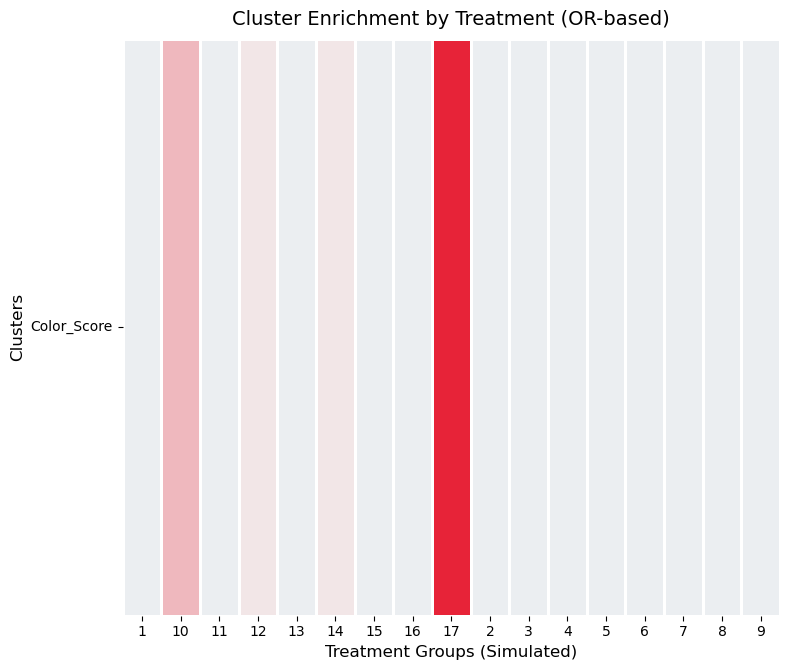

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# ==========================================
# 1. 准备数据 (这里直接放入你提供的文本数据)
# ==========================================
data_text = """Cluster,OR,P,Q
1,0.941747572815534,1.0,1.0
10,1.9038461538461537,1.0,1.0
11,0.9428571428571428,1.0,1.0
12,1.1354309165526675,0.8561538179885858,1.0
13,0.9361702127659575,1.0,1.0
14,1.14,1.0,1.0
15,0.9428571428571428,1.0,1.0
16,0.9423076923076923,1.0,1.0
17,inf,1.0,1.0
2,0.9361702127659575,1.0,1.0
3,0.9375,1.0,1.0
4,0.94,1.0,1.0
5,0.9381443298969072,1.0,1.0
6,0.94,1.0,1.0
7,0.9405940594059405,1.0,1.0
8,0.9411764705882353,1.0,1.0
9,0.94,1.0,1.0"""

# 读取数据
df = pd.read_csv(StringIO(data_text))

# 处理 inf (无穷大)，将其替换为一个较大的数以便画图，比如 10
df['OR'] = df['OR'].replace([np.inf, -np.inf], 10.0)

# ==========================================
# 2. 定义颜色逻辑 (模仿附件风格)
# ==========================================
# 逻辑：
# OR > 1 -> 红色 (富集在组 1)
# OR < 1 -> 蓝色 (富集在组 2)
# 颜色深度由 log2(OR) 的绝对值决定

# 计算 Log2(OR) 用于映射颜色强度
# 如果 OR=1, log2=0 (白色/黑色)
# 如果 OR>1, log2>0 (红)
# 如果 OR<1, log2<0 (蓝)
df['Log2_OR'] = np.log2(df['OR'])

# 设定一个最大饱和度阈值，防止个别极大值导致其他颜色看不清
max_sat = df['Log2_OR'].abs().max()
if max_sat == 0: max_sat = 1 # 避免除以零

# 归一化到 -1 到 1 之间，用于 colormap
df['Color_Score'] = df['Log2_OR'] / max_sat

# ==========================================
# 3. 绘图 (模仿附件的热图矩阵)
# ==========================================
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, len(df) * 0.4)) # 高度随行数自动调整

# 创建一个虚拟的矩阵用于 heatmap
# 行：Cluster, 列：只有一个虚拟列 "Enrichment"
matrix = df[['Cluster', 'Color_Score']].set_index('Cluster').T

# 自定义颜色映射：蓝 (负) -> 白 (0) -> 红 (正)
# 使用 seaborn 的 diverging palette
cmap = sns.diverging_palette(240, 10, s=90, l=50, center="light", as_cmap=True)

# 绘制热图
sns.heatmap(matrix, 
            cmap=cmap, 
            vmin=-1, vmax=1, 
            center=0,
            cbar=False, # 不显示颜色条，模仿附件简洁风格
            linewidths=1, # 格子之间的线宽
            linecolor='white', # 格子之间的线颜色
            ax=ax,
            square=False) # 不需要正方形格子

# 设置标题和标签
ax.set_title("Cluster Enrichment by Treatment (OR-based)", fontsize=14, pad=10)
ax.set_xlabel("Treatment Groups (Simulated)", fontsize=12)
ax.set_ylabel("Clusters", fontsize=12)

# 优化 Y 轴标签 (Cluster ID)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# 添加数值标注 (可选，如果想看具体的 OR 值)
# for i, cluster in enumerate(df['Cluster']):
#     ax.text(0.5, i + 0.5, f"{df.loc[i, 'OR']:.2f}", ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()

# 保存图片
output_img = "Cluster_Enrichment_Heatmap.png"
plt.savefig(output_img, dpi=300, bbox_inches='tight')
print(f"✅ 热图已保存为: {output_img}")

# ==========================================
# 4. 整理并保存 Excel 表格 (带条件格式提示)
# ==========================================
# 添加一列描述，方便阅读
def get_direction(or_val):
    if or_val > 1.0: return "Enriched in Group A (Red)"
    elif or_val < 1.0: return "Enriched in Group B (Blue)"
    else: return "No Difference"

df['Direction'] = df['OR'].apply(get_direction)

# 重新排序 Cluster (按数字大小排序，而不是字符串排序)
# 假设 Cluster 列是数字或可以转为数字
df['Cluster_Num'] = pd.to_numeric(df['Cluster'], errors='coerce')
df_sorted = df.sort_values(by='Cluster_Num').drop(columns=['Cluster_Num'])

output_excel = "Cluster_Enrichment_Results.xlsx"
df_sorted.to_excel(output_excel, index=False)
print(f"✅ 详细数据表已保存为: {output_excel}")

plt.show()

✅ 图片已保存: Cluster_HLM_Enrichment.png


/tmp/ipykernel_2103/1277613985.py:64: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


ModuleNotFoundError: No module named 'openpyxl'

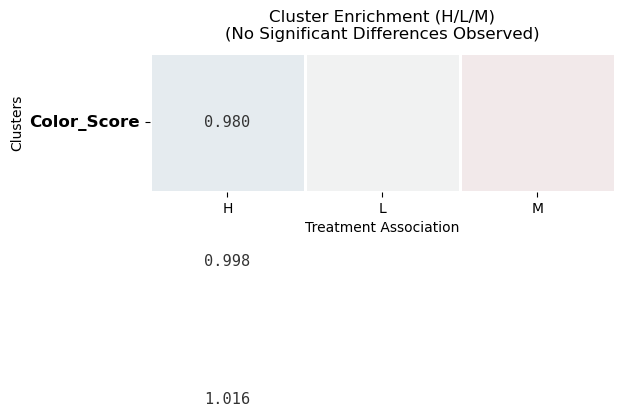

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# 1. 输入数据
data_text = """Cluster,OR,P,Q
H,0.9798515376458112,1.0,1.0
L,0.9983193277310924,1.0,1.0
M,1.0162790697674418,1.0,1.0"""

df = pd.read_csv(StringIO(data_text))

# 2. 数据预处理
# 处理可能的 inf
df['OR'] = df['OR'].replace([np.inf, -np.inf], np.nan)

# 计算 Log2(OR) 用于颜色映射
# OR=1 -> 0; OR>1 -> 正数 (红); OR<1 -> 负数 (蓝)
df['Log2_OR'] = np.log2(df['OR'])

# 确定颜色缩放范围 (为了让微小的差异也能看到一点点颜色，我们手动设定一个较小的范围)
# 如果自动缩放，因为差异太小，颜色会淡到看不见。
# 这里我们设定：OR=0.8 或 1.2 对应最深色。当前的 0.98 和 1.016 会显示为很淡的颜色。
v_min = -0.5  # 对应 OR ≈ 0.7
v_max = 0.5   # 对应 OR ≈ 1.4
df['Color_Score'] = df['Log2_OR'].clip(v_min, v_max) # 限制范围以防极端值

# 3. 绘图 (模仿附件风格)
plt.style.use('default')
fig, ax = plt.subplots(figsize=(6, len(df) * 0.6)) # 调整大小以适应 3 行

# 构建矩阵
matrix = df[['Cluster', 'Color_Score']].set_index('Cluster').T

# 定义颜色：蓝 (负) <-> 白 (0) <-> 红 (正)
cmap = sns.diverging_palette(240, 10, s=90, l=50, center="light", as_cmap=True)

# 绘制热图
sns.heatmap(matrix, 
            cmap=cmap, 
            vmin=v_min, vmax=v_max, 
            center=0,
            cbar=False, 
            linewidths=2,      # 加粗边框，让格子更明显
            linecolor='white', 
            ax=ax,
            square=False)

# 美化
ax.set_title("Cluster Enrichment (H/L/M)\n(No Significant Differences Observed)", fontsize=12, pad=10)
ax.set_xlabel("Treatment Association", fontsize=10)
ax.set_ylabel("Clusters", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12, fontweight='bold')

# 在格子里写上 OR 值 (保留3位小数)
for i, cluster in enumerate(df['Cluster']):
    val = df.loc[i, 'OR']
    # 根据背景深浅决定字体颜色 (简单逻辑：如果 OR 接近 1 用黑色，否则用白色)
    # 这里因为颜色都很淡，统一用黑色或深灰色
    ax.text(0.5, i + 0.5, f"{val:.3f}", ha='center', va='center', color='#333333', fontsize=11, fontfamily='monospace')

plt.tight_layout()
plt.savefig("Cluster_HLM_Enrichment.png", dpi=300, bbox_inches='tight')
print("✅ 图片已保存: Cluster_HLM_Enrichment.png")

# 4. 整理 Excel 表格
df_sorted = df.sort_values(by='Cluster') # 按字母 H, L, M 排序
df_sorted['Interpretation'] = df_sorted['OR'].apply(
    lambda x: "Slightly Group A" if x > 1.0 else ("Slightly Group B" if x < 1.0 else "Balanced")
)

output_excel = "Results_HLM_Cleaned.xlsx"
df_sorted.to_excel(output_excel, index=False)
print(f"✅ 表格已保存: {output_excel}")

print("\n📊 统计摘要:")
print(f"   最大 OR: {df['OR'].max():.4f} (Cluster {df.loc[df['OR'].idxmax(), 'Cluster']})")
print(f"   最小 OR: {df['OR'].min():.4f} (Cluster {df.loc[df['OR'].idxmin(), 'Cluster']})")
print("   结论: 所有 Q 值均为 1.0，未发现统计学显著的富集。")

plt.show()

🚀 开始分析：Fisher Exact Test (Matrix Mode)...
   检测到原始分组值: [1 2 0]
✅ Label 文件加载: 52 样本
   分组分布:
1    30
2    21
0     1
Name: Group_Name, dtype: int64
✅ Cluster 文件加载: 106 记录
✅ 成功匹配样本: 102
   对比组别: 0 vs 1
   检测到的 Cluster 数量: 3

🔍 正在执行 Fisher 精确检验...
⚖️ 进行 FDR (Benjamini-Hochberg) 校正...

📊 显著性结果摘要 (Q < 0.05)
   ⚪ 未发现显著富集的 Cluster (所有 Q >= 0.05)。
   (这将生成一张颜色很淡或全黑/白的热图，符合统计事实)

💾 矩阵文件已保存至:
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_Anderson_Fisher_Counts.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_Anderson_Fisher_OR.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_Anderson_Fisher_PValue.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_Anderson_Fisher_QValue.csv

✨ 下一步：使用生成的 QValue.csv 和 OR.csv 绘制热图。
🖼️ 热图预览已保存: /home/qyyua

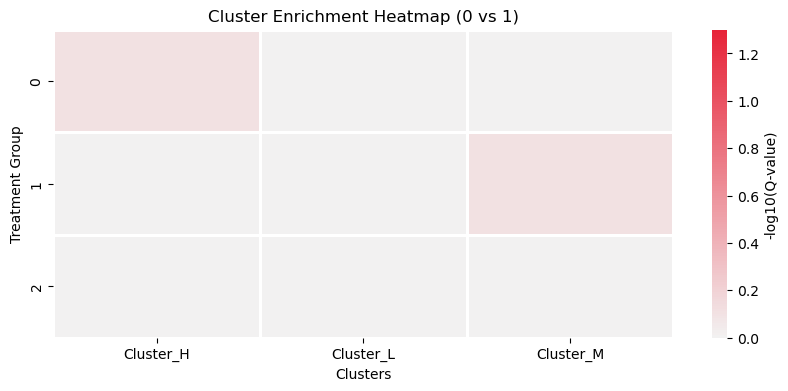

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os
import re

# ==========================================
# 1. 配置路径 (请根据实际情况修改)
# ==========================================
base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
# 输入文件
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/anderson_adt.txt")
file_cluster = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno02.csv")
# 输出前缀
output_prefix = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_Anderson_Fisher")

print("🚀 开始分析：Fisher Exact Test (Matrix Mode)...")

# ==========================================
# 2. 辅助函数：提取 ID 和 前缀
# ==========================================
def extract_id(name):
    if not isinstance(name, str): return None
    name = str(name).strip().strip('"')
    # 尝试提取数字，如果没有数字则返回原字符串（防止某些样本名无数字）
    match = re.search(r'(\d+)', name)
    return match.group(1) if match else name

def get_group_from_label(df, group_col, sample_col):
    """
    自动识别分组逻辑。
    如果是 Anderson 数据，通常映射 1->N, 2->mADT。
    如果是 Gleason 数据，通常需要自定义映射。
    这里做一个通用的自动检测。
    """
    unique_vals = df[group_col].unique()
    print(f"   检测到原始分组值: {unique_vals}")
    
    # 尝试自动映射 (针对 anderson_adt.txt: 1=N, 2=mADT)
    if set(unique_vals).issubset({1, 2, '1', '2'}):
        mapping = {1: 'N', 2: 'mADT', '1': 'N', '2': 'mADT'}
        print("   -> 自动应用模式: 1=N, 2=mADT")
        return df[group_col].map(mapping)
    
    # 如果是字符串且包含特定关键词，也可以扩展这里
    # 否则返回原值作为组名
    return df[group_col].astype(str)

# ==========================================
# 3. 读取并处理 Label 文件
# ==========================================
# 智能读取分隔符
df_label = None
for sep in ['\t', ',', '\s+']:
    try:
        if sep == '\s+':
            temp = pd.read_csv(file_label, sep=sep, engine='python')
        else:
            temp = pd.read_csv(file_label, sep=sep)
        if temp.shape[1] >= 2:
            df_label = temp
            break
    except: continue

if df_label is None: raise Exception("无法读取 Label 文件")

# 标准化列名
df_label.columns = [str(c).strip().lower() for c in df_label.columns]
# 假设第一列是分组信息，第二列是样本名 (根据 anderson_adt.txt 结构)
# 如果列名已知，最好显式指定，这里做自适应
col_group = df_label.columns[0] 
col_sample = df_label.columns[1]

df_label.rename(columns={col_group: 'Group_Raw', col_sample: 'Sample_Name_Raw'}, inplace=True)

# 生成分组名称 (Group_Name)
df_label['Group_Name'] = get_group_from_label(df_label, 'Group_Raw', 'Sample_Name_Raw')
df_label = df_label.dropna(subset=['Group_Name'])

# 提取 Match ID
df_label['Match_ID'] = df_label['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Label 文件加载: {len(df_label)} 样本")
print(f"   分组分布:\n{df_label['Group_Name'].value_counts()}")

# ==========================================
# 4. 读取并处理 Cluster 文件
# ==========================================
# 假设第一列是样本名，第二列是 Cluster/Purity 信息
df_c_raw = pd.read_csv(file_cluster)
c_name = df_c_raw.columns[0]
# 自动寻找 Cluster 列 (通常是第二列，或者包含 'Cluster', 'Purity', 'Level' 的列)
c_target = None
for c in df_c_raw.columns[1:]:
    if any(k in str(c).lower() for k in ['cluster', 'purity', 'level', 'type']):
        c_target = c
        break
if c_target is None: c_target = df_c_raw.columns[1] # 默认第二列

df_cluster = pd.DataFrame({
    'Sample_Name_Raw': df_c_raw[c_name].astype(str).str.strip().str.replace('"', ''),
    'Cluster_ID': df_c_raw[c_target].astype(str).str.strip()
})
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Cluster 文件加载: {len(df_cluster)} 记录")

# ==========================================
# 5. 合并数据
# ==========================================
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')
if len(df_merged) == 0:
    raise Exception("❌ 合并后无数据！请检查 Sample ID 提取逻辑是否一致。")

print(f"✅ 成功匹配样本: {len(df_merged)}")

# 准备分组列表 (排序以保证顺序固定，例如 ['N', 'mADT'])
groups = sorted(df_merged['Group_Name'].unique())
if len(groups) < 2:
    raise Exception("❌ 只检测到一个分组，无法进行对比检验。")
    
print(f"   对比组别: {groups[0]} vs {groups[1]}")

# 将组别映射为 0 和 1 用于矩阵索引
group_map = {g: i for i, g in enumerate(groups)}
df_merged['Group_Label'] = df_merged['Group_Name'].map(group_map)

clusters = sorted(df_merged['Cluster_ID'].unique())
print(f"   检测到的 Cluster 数量: {len(clusters)}")

# ==========================================
# 6. 核心循环：Fisher 精确检验 (矩阵构建)
# ==========================================
# 初始化矩阵
# 行：Group Names (e.g., N, mADT)
# 列：Cluster_1, Cluster_2...
p_matrix = pd.DataFrame(np.nan, index=groups, columns=[f"Cluster_{c}" for c in clusters])
or_matrix = pd.DataFrame(np.nan, index=groups, columns=[f"Cluster_{c}" for c in clusters])
count_matrix = pd.DataFrame(0, index=groups, columns=[f"Cluster_{c}" for c in clusters])

all_p_two_sided = []
cluster_list_ordered = []

print("\n🔍 正在执行 Fisher 精确检验...")

for cl in clusters:
    c_col = f"Cluster_{cl}"
    cluster_list_ordered.append(cl)
    
    # 构建列联表
    # 行：Group_Label (0, 1)
    # 列：Is_In_Cluster (False, True)
    ct = pd.crosstab(df_merged['Group_Label'], df_merged['Cluster_ID'] == cl)
    ct = ct.reindex(index=[0, 1], columns=[False, True], fill_value=0)
    
    a = ct.loc[0, True]   # Group 0 中有该 Cluster 的数量
    b = ct.loc[0, False]  # Group 0 中没有该 Cluster 的数量
    c = ct.loc[1, True]   # Group 1 中有该 Cluster 的数量
    d = ct.loc[1, False]  # Group 1 中没有该 Cluster 的数量
    
    # 记录计数
    count_matrix.loc[groups[0], c_col] = a
    count_matrix.loc[groups[1], c_col] = c
    
    table = [[a, b], [c, d]]
    
    # 边界情况处理
    if a+b == 0 or c+d == 0 or a+c == 0 or b+d == 0:
        oddsratio = np.nan
        p_two = 1.0
        p_greater = 1.0 # Group 0 enriched
        p_less = 1.0    # Group 1 enriched (or Group 0 depleted)
    else:
        oddsratio, p_two = fisher_exact(table, alternative='two-sided')
        _, p_greater = fisher_exact(table, alternative='greater') # H0: OR <= 1 (Test if Group 0 is enriched)
        _, p_less = fisher_exact(table, alternative='less')       # H0: OR >= 1 (Test if Group 0 is depleted / Group 1 enriched)
    
    all_p_two_sided.append(p_two)
    
    # 【关键逻辑】根据 OR 值方向分配单侧 P 值到矩阵
    # 如果 OR > 1: 说明 Group 0 (行索引 0) 富集。
    #   -> Group 0 的 P 值 = p_greater (显著性)
    #   -> Group 1 的 P 值 = 1.0 (不显著)
    # 如果 OR < 1: 说明 Group 1 (行索引 1) 富集 (即 Group 0 匮乏)。
    #   -> Group 0 的 P 值 = 1.0
    #   -> Group 1 的 P 值 = p_less (显著性)
    
    if pd.notna(oddsratio) and oddsratio > 1:
        p_matrix.loc[groups[0], c_col] = p_greater
        p_matrix.loc[groups[1], c_col] = 1.0
    elif pd.notna(oddsratio) and oddsratio < 1:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = p_less
    else:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = 1.0
        
    # OR 矩阵两个组都填一样的值，方便查看
    or_matrix.loc[groups[0], c_col] = oddsratio
    or_matrix.loc[groups[1], c_col] = oddsratio

# ==========================================
# 7. FDR 校正 (基于双侧 P 值)
# ==========================================
print("⚖️ 进行 FDR (Benjamini-Hochberg) 校正...")
if len(all_p_two_sided) > 0:
    reject, q_vals, _, _ = multipletests(all_p_two_sided, method='fdr_bh')
    
    # 构建 Q 值矩阵 (逻辑同 P 值矩阵)
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)
    
    for i, cl in enumerate(cluster_list_ordered):
        c_col = f"Cluster_{cl}"
        q = q_vals[i]
        or_val = or_matrix.loc[groups[0], c_col]
        
        if pd.notna(or_val) and or_val > 1:
            q_matrix.loc[groups[0], c_col] = q
            q_matrix.loc[groups[1], c_col] = 1.0
        elif pd.notna(or_val) and or_val < 1:
            q_matrix.loc[groups[0], c_col] = 1.0
            q_matrix.loc[groups[1], c_col] = q
            
else:
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)

# ==========================================
# 8. 输出结果与绘图准备
# ==========================================
print("\n" + "="*60)
print("📊 显著性结果摘要 (Q < 0.05)")
print("="*60)
sig_count = 0
for col in q_matrix.columns:
    q0 = q_matrix.loc[groups[0], col]
    q1 = q_matrix.loc[groups[1], col]
    if q0 < 0.05:
        print(f"   🔴 {col} 显著富集于 [{groups[0]}] (Q={q0:.4f}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1
    if q1 < 0.05:
        print(f"   🔵 {col} 显著富集于 [{groups[1]}] (Q={q1:.4f}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1

if sig_count == 0:
    print("   ⚪ 未发现显著富集的 Cluster (所有 Q >= 0.05)。")
    print("   (这将生成一张颜色很淡或全黑/白的热图，符合统计事实)")

# 保存 CSV 文件 (这就是你要的“附件表格”数据源)
count_matrix.to_csv(f"{output_prefix}_Counts.csv")
or_matrix.to_csv(f"{output_prefix}_OR.csv")
p_matrix.to_csv(f"{output_prefix}_PValue.csv")
q_matrix.to_csv(f"{output_prefix}_QValue.csv")

print(f"\n💾 矩阵文件已保存至:\n   - {output_prefix}_Counts.csv\n   - {output_prefix}_OR.csv\n   - {output_prefix}_PValue.csv\n   - {output_prefix}_QValue.csv")
print("\n✨ 下一步：使用生成的 QValue.csv 和 OR.csv 绘制热图。")

# ==========================================
# 9. (可选) 直接生成热图预览
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, max(4, len(groups)*0.5)))
# 使用 -log10(Q) 作为颜色深度，但限制最大值以防 0
q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 10)
# 掩膜：如果 Q > 0.05, 显示为白色或浅色 (可选，这里我们让颜色自然过渡)

sns.heatmap(q_plot, 
            cmap=sns.diverging_palette(240, 10, s=90, l=50, center="light", as_cmap=True),
            vmin=0, vmax=-np.log10(0.05), # 阈值设在 0.05
            center=0,
            cbar_kws={'label': '-log10(Q-value)'},
            linewidths=1, linecolor='white')

plt.title(f"Cluster Enrichment Heatmap ({groups[0]} vs {groups[1]})")
plt.ylabel("Treatment Group")
plt.xlabel("Clusters")
plt.savefig(f"{output_prefix}_Heatmap.png", dpi=300, bbox_inches='tight')
print(f"🖼️ 热图预览已保存: {output_prefix}_Heatmap.png")
plt.show()

🚀 运行组合 1 (Matrix Mode): label.csv vs dat_CN_percent_class.csv (行对齐模式)
📥 步骤 1: 加载标准样本名列表 (从 mydata_pheno02.csv)...
✅ 标准样本名数量: 106
📥 步骤 2: 读取 Label 文件...
✅ Label 文件加载完成
   分组分布:
Group_Name
2    28
1    13
Name: count, dtype: int64
📥 步骤 3: 读取 CNV 分类数据 (dat_CN_percent_class.csv)...
   CNV 文件行数: 106
   参考样本数: 106
   ✅ 行数完全匹配，直接对齐。
✅ CNV 数据构建完成: 106 记录, 5 个唯一分类
✅ 成功匹配样本数: 80
   对比组别: 1 vs 2
   CNV 分类总数: 5 (['SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5'])

🔍 正在执行 Fisher 精确检验...
⚖️ 进行 FDR (Benjamini-Hochberg) 校正...

📊 显著性结果摘要 (FDR < 0.05)
   ⚪ 未发现显著富集的 CNV 分类。

💾 矩阵文件已保存:
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_CNClass_Matrix_Counts.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_CNClass_Matrix_OR.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_CNClass_Matrix_PValue.csv
   - /home/

/tmp/ipykernel_254686/3754680667.py:263: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)


🖼️ 热图已保存: /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_CNClass_Matrix_Heatmap.png


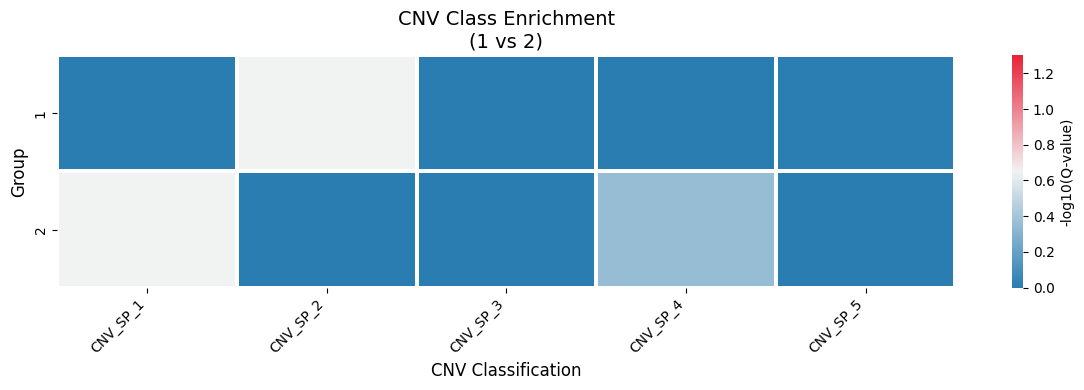

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置路径
# ==========================================
base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster_raw = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/dat_CN_percent_class.csv")
file_ref_samples = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno02.csv")
output_prefix = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_CRPC_CNClass_Matrix")

print("🚀 运行组合 1 (Matrix Mode): label.csv vs dat_CN_percent_class.csv (行对齐模式)")

# ==========================================
# 2. 辅助函数
# ==========================================
def extract_id(name):
    """从样本名提取数字 ID"""
    if not isinstance(name, str): return None
    name = str(name).strip().strip('"')
    match = re.search(r'(\d+)', name)
    return match.group(1) if match else name

# ==========================================
# 3. 读取标准样本名 (Reference)
# ==========================================
print("📥 步骤 1: 加载标准样本名列表 (从 mydata_pheno02.csv)...")
try:
    df_ref = pd.read_csv(file_ref_samples)
    # 取第一列作为标准样本名
    standard_samples = df_ref.iloc[:, 0].astype(str).str.strip().str.replace('"', '').tolist()
    print(f"✅ 标准样本名数量: {len(standard_samples)}")
    if len(standard_samples) == 0:
        raise Exception("参考文件中无有效样本名。")
except Exception as e:
    raise Exception(f"❌ 读取参考文件失败: {e}")

# ==========================================
# 4. 读取并处理 Label 文件
# ==========================================
print("📥 步骤 2: 读取 Label 文件...")
df_label = pd.read_csv(file_label)

if df_label.shape[1] < 2:
    raise Exception("❌ Label 文件至少需要两列 (Sample, Group)。")

df_label.columns = [str(c).strip() for c in df_label.columns]
df_label = df_label.iloc[:, :2]
df_label.columns = ['Sample_Name_Raw', 'Group_Name']

df_label['Sample_Name_Raw'] = df_label['Sample_Name_Raw'].astype(str).str.strip().str.replace('"', '')
df_label = df_label.dropna(subset=['Sample_Name_Raw', 'Group_Name'])
df_label['Match_ID'] = df_label['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Label 文件加载完成")
print(f"   分组分布:\n{df_label['Group_Name'].value_counts()}")

unique_groups = df_label['Group_Name'].unique()
if len(unique_groups) < 2:
    raise Exception(f"❌ 错误：Label 文件中只有 {len(unique_groups)} 组，无法对比。")
elif len(unique_groups) > 2:
    print(f"⚠️ 警告：发现 {len(unique_groups)} 个组别。将自动选取数量最多的两组。")
    top_2 = df_label['Group_Name'].value_counts().nlargest(2).index.tolist()
    df_label = df_label[df_label['Group_Name'].isin(top_2)]
    unique_groups = df_label['Group_Name'].unique()

# ==========================================
# 5. 读取并处理 CNV Class (行对齐模式)
# ==========================================
print("📥 步骤 3: 读取 CNV 分类数据 (dat_CN_percent_class.csv)...")
df_c_raw = pd.read_csv(file_cluster_raw)

# 取最后一列作为 Cluster ID (CNV Class)
cluster_vals = df_c_raw.iloc[:, -1].astype(str).str.strip()

n_cluster = len(cluster_vals)
n_ref = len(standard_samples)

print(f"   CNV 文件行数: {n_cluster}")
print(f"   参考样本数: {n_ref}")

if n_cluster != n_ref:
    print(f"⚠️ 严重警告：行数不匹配 ({n_cluster} vs {n_ref})!")
    if n_cluster > n_ref:
        print(f"   -> 策略：截断 CNV 数据以匹配参考样本前 {n_ref} 行。")
        cluster_vals = cluster_vals.iloc[:n_ref]
        current_samples = standard_samples
    else:
        print(f"   -> 策略：参考样本过多，仅使用前 {n_cluster} 个样本进行匹配。")
        current_samples = standard_samples[:n_cluster]
else:
    current_samples = standard_samples
    print("   ✅ 行数完全匹配，直接对齐。")

df_cluster = pd.DataFrame({
    'Sample_Name_Raw': current_samples,
    'Cluster_ID': cluster_vals.values
})

# 去除空值
df_cluster = df_cluster.dropna(subset=['Sample_Name_Raw', 'Cluster_ID'])
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(extract_id)

print(f"✅ CNV 数据构建完成: {len(df_cluster)} 记录, {len(df_cluster['Cluster_ID'].unique())} 个唯一分类")

# ==========================================
# 6. 合并数据
# ==========================================
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')

if len(df_merged) == 0:
    raise Exception("❌ 合并后无数据！请检查 label.csv 中的样本名是否包含可与参考样本匹配的数字 ID。")

print(f"✅ 成功匹配样本数: {len(df_merged)}")

# 准备矩阵维度
groups = sorted(list(df_merged['Group_Name'].unique()))
group_to_idx = {g: i for i, g in enumerate(groups)}
df_merged['Group_Label'] = df_merged['Group_Name'].map(group_to_idx)

# 对 CNV 分类进行生物学排序 (尝试 Loss < Neutral < Gain)
cnv_order_map = {
    'loss': 0, 'homozygous loss': 0, 'hemizygous loss': 0,
    'neutral': 1, 'diploid': 1, 'normal': 1,
    'gain': 2, 'amplification': 2, 'amp': 2, 'high gain': 2
}

def sort_cnv_key(x):
    x_lower = str(x).lower()
    if x_lower in cnv_order_map:
        return (0, cnv_order_map[x_lower], str(x))
    try:
        return (1, float(x), str(x))
    except:
        return (2, 999, str(x))

clusters = sorted(df_merged['Cluster_ID'].unique(), key=sort_cnv_key)

print(f"   对比组别: {groups[0]} vs {groups[1]}")
print(f"   CNV 分类总数: {len(clusters)} ({clusters})")

# ==========================================
# 7. Fisher 精确检验 (构建矩阵)
# ==========================================
p_matrix = pd.DataFrame(1.0, index=groups, columns=[f"CNV_{c}" for c in clusters])
or_matrix = pd.DataFrame(np.nan, index=groups, columns=[f"CNV_{c}" for c in clusters])
count_matrix = pd.DataFrame(0, index=groups, columns=[f"CNV_{c}" for c in clusters])

all_p_two_sided = []
cluster_order = []

print("\n🔍 正在执行 Fisher 精确检验...")

for cl in clusters:
    c_col = f"CNV_{cl}"
    cluster_order.append(cl)
    
    # 构建列联表
    ct = pd.crosstab(df_merged['Group_Label'], df_merged['Cluster_ID'] == cl)
    ct = ct.reindex(index=[0, 1], columns=[False, True], fill_value=0)
    
    a = ct.loc[0, True]   # Group 0 has this CNV
    b = ct.loc[0, False]
    c = ct.loc[1, True]   # Group 1 has this CNV
    d = ct.loc[1, False]
    
    count_matrix.loc[groups[0], c_col] = a
    count_matrix.loc[groups[1], c_col] = c
    
    table = [[a, b], [c, d]]
    
    if a+b == 0 or c+d == 0 or a+c == 0 or b+d == 0:
        oddsratio = np.nan
        p_two = 1.0
        p_greater = 1.0
        p_less = 1.0
    else:
        oddsratio, p_two = fisher_exact(table, alternative='two-sided')
        _, p_greater = fisher_exact(table, alternative='greater') 
        _, p_less = fisher_exact(table, alternative='less')       
        
    all_p_two_sided.append(p_two)
    
    # 分配单侧 P 值
    if pd.notna(oddsratio) and oddsratio > 1:
        # Group 0 富集
        p_matrix.loc[groups[0], c_col] = p_greater
        p_matrix.loc[groups[1], c_col] = 1.0
    elif pd.notna(oddsratio) and oddsratio < 1:
        # Group 1 富集
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = p_less
    else:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = 1.0
        
    or_matrix.loc[groups[0], c_col] = oddsratio
    or_matrix.loc[groups[1], c_col] = oddsratio

# ==========================================
# 8. FDR 校正
# ==========================================
print("⚖️ 进行 FDR (Benjamini-Hochberg) 校正...")
if len(all_p_two_sided) > 0:
    reject, q_vals, _, _ = multipletests(all_p_two_sided, method='fdr_bh')
    
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)
    
    for i, cl in enumerate(cluster_order):
        c_col = f"CNV_{cl}"
        q = q_vals[i]
        or_val = or_matrix.loc[groups[0], c_col]
        
        if pd.notna(or_val) and or_val > 1:
            q_matrix.loc[groups[0], c_col] = q
            q_matrix.loc[groups[1], c_col] = 1.0
        elif pd.notna(or_val) and or_val < 1:
            q_matrix.loc[groups[0], c_col] = 1.0
            q_matrix.loc[groups[1], c_col] = q
else:
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)

# ==========================================
# 9. 输出结果摘要
# ==========================================
print("\n" + "="*70)
print("📊 显著性结果摘要 (FDR < 0.05)")
print("="*70)
sig_count = 0
for col in q_matrix.columns:
    q0 = q_matrix.loc[groups[0], col]
    q1 = q_matrix.loc[groups[1], col]
    if q0 < 0.05:
        print(f"   🔴 {col} 显著富集于 [{groups[0]}] (Q={q0:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1
    if q1 < 0.05:
        print(f"   🔵 {col} 显著富集于 [{groups[1]}] (Q={q1:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1

if sig_count == 0:
    print("   ⚪ 未发现显著富集的 CNV 分类。")

# 保存 CSV 矩阵
count_matrix.to_csv(f"{output_prefix}_Counts.csv")
or_matrix.to_csv(f"{output_prefix}_OR.csv")
p_matrix.to_csv(f"{output_prefix}_PValue.csv")
q_matrix.to_csv(f"{output_prefix}_QValue.csv")

print(f"\n💾 矩阵文件已保存:\n   - {output_prefix}_Counts.csv\n   - {output_prefix}_OR.csv\n   - {output_prefix}_PValue.csv\n   - {output_prefix}_QValue.csv")

# ==========================================
# 10. 绘制热图预览
# ==========================================
plt.figure(figsize=(12, max(4, len(groups)*0.8)))
# 转换 Q 值为 -log10
q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)
v_max = -np.log10(0.05)

sns.heatmap(q_plot, 
            cmap=sns.diverging_palette(240, 10, s=90, l=50, center="light", as_cmap=True),
            vmin=0, vmax=v_max,
            linewidths=1.5, linecolor='white',
            cbar_kws={'label': '-log10(Q-value)'})

plt.title(f"CNV Class Enrichment\n({groups[0]} vs {groups[1]})", fontsize=14)
plt.ylabel("Group", fontsize=12)
plt.xlabel("CNV Classification", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plot_file = f"{output_prefix}_Heatmap.png"
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"🖼️ 热图已保存: {plot_file}")
plt.show()

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置路径
# ==========================================
base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv") # 请确认这个文件是否包含 0,1,2
file_cluster = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno02.csv")
output_prefix = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_Merged_Fisher")

print("🚀 开始分析：合并组别 (0 -> 1) + Fisher 精确检验...")

# ==========================================
# 2. 辅助函数
# ==========================================
def extract_id(name):
    if not isinstance(name, str): return None
    name = str(name).strip().strip('"')
    match = re.search(r'(\d+)', name)
    return match.group(1) if match else name

# ==========================================
# 3. 读取并处理 Label 文件 (核心修改点)
# ==========================================
df_label = None
for sep in ['\t', ',', '\s+']:
    try:
        if sep == '\s+':
            temp = pd.read_csv(file_label, sep=sep, engine='python')
        else:
            temp = pd.read_csv(file_label, sep=sep)
        if temp.shape[1] >= 2:
            df_label = temp
            break
    except: continue

if df_label is None: raise Exception("无法读取 Label 文件")

df_label.columns = [str(c).strip().lower() for c in df_label.columns]
col_group = df_label.columns[0] 
col_sample = df_label.columns[1]

df_label.rename(columns={col_group: 'Group_Raw', col_sample: 'Sample_Name_Raw'}, inplace=True)

# 【关键步骤】数据清洗与合并
# 1. 转为数字 (如果可能)
df_label['Group_Num'] = pd.to_numeric(df_label['Group_Raw'], errors='ignore')

# 2. 定义合并规则：将 0 归并到 1
# 逻辑：如果值是 0，则变为 1；否则保持不变。
# 注意：如果你的数据里 0,1,2 都有，这步之后 0 没了，只剩下 1 和 2。
def merge_groups(val):
    if pd.isna(val): return val
    try:
        num_val = float(val)
        if num_val == 0:
            return 1  # 将 0 映射为 1
        else:
            return int(num_val) # 保持其他值不变 (1->1, 2->2)
    except:
        return val # 非数字保持原样

df_label['Group_Merged'] = df_label['Group_Raw'].apply(merge_groups)

# 3. 转换为字符串组名，方便后续处理 (例如: 1 -> "Group_A", 2 -> "Group_B")
# 这里我们直接用数字作为组名，或者你可以自定义映射
# 假设合并后剩下 1 和 2
group_map_str = {1: 'Group_0_1_Merged', 2: 'Group_2'} 
# 如果还有其他的值，自动添加
unique_merged = df_label['Group_Merged'].unique()
for u in unique_merged:
    if u not in group_map_str:
        group_map_str[u] = f"Group_{u}"

df_label['Group_Name'] = df_label['Group_Merged'].map(group_map_str)

# 过滤空值
df_label = df_label.dropna(subset=['Group_Name'])

# 提取 ID
df_label['Match_ID'] = df_label['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Label 文件加载与合并完成")
print(f"   原始分组分布:\n{df_label['Group_Raw'].value_counts().sort_index()}")
print(f"   合并后分组分布:\n{df_label['Group_Name'].value_counts()}")

# 检查是否正好剩 2 组
unique_groups = df_label['Group_Name'].unique()
if len(unique_groups) != 2:
    print(f"⚠️ 警告：合并后组别数量为 {len(unique_groups)}，不是 2 组。将尝试取前两组或报错。")
    if len(unique_groups) < 2:
        raise Exception("❌ 合并后只剩 1 组，无法进行对比检验。请检查数据。")
    # 如果多于 2 组，只取前两个最大的组（可选策略，这里暂保留所有但提示用户）
    # 为了代码稳健，我们只保留数量最多的两组
    top_2 = df_label['Group_Name'].value_counts().nlargest(2).index.tolist()
    df_label = df_label[df_label['Group_Name'].isin(top_2)]
    unique_groups = df_label['Group_Name'].unique()
    print(f"   已自动筛选数量最多的两组进行对比: {unique_groups}")

# ==========================================
# 4. 读取并处理 Cluster 文件
# ==========================================
df_c_raw = pd.read_csv(file_cluster)
c_name = df_c_raw.columns[0]
c_target = None
for c in df_c_raw.columns[1:]:
    if any(k in str(c).lower() for k in ['cluster', 'purity', 'level', 'type']):
        c_target = c
        break
if c_target is None: c_target = df_c_raw.columns[1]

df_cluster = pd.DataFrame({
    'Sample_Name_Raw': df_c_raw[c_name].astype(str).str.strip().str.replace('"', ''),
    'Cluster_ID': df_c_raw[c_target].astype(str).str.strip()
})
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Cluster 文件加载: {len(df_cluster)} 记录")

# ==========================================
# 5. 合并数据
# ==========================================
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')
if len(df_merged) == 0:
    raise Exception("❌ 合并后无数据！")

print(f"✅ 成功匹配样本: {len(df_merged)}")

# 准备分组列表 (排序)
groups = sorted(list(unique_groups))
group_map_idx = {g: i for i, g in enumerate(groups)}
df_merged['Group_Label'] = df_merged['Group_Name'].map(group_map_idx)

clusters = sorted(df_merged['Cluster_ID'].unique())
print(f"   对比组别: {groups[0]} vs {groups[1]}")
print(f"   Cluster 数量: {len(clusters)}")

# ==========================================
# 6. Fisher 精确检验 (矩阵构建)
# ==========================================
p_matrix = pd.DataFrame(np.nan, index=groups, columns=[f"Cluster_{c}" for c in clusters])
or_matrix = pd.DataFrame(np.nan, index=groups, columns=[f"Cluster_{c}" for c in clusters])
count_matrix = pd.DataFrame(0, index=groups, columns=[f"Cluster_{c}" for c in clusters])

all_p_two_sided = []
cluster_list_ordered = []

print("\n🔍 正在执行 Fisher 精确检验...")

for cl in clusters:
    c_col = f"Cluster_{cl}"
    cluster_list_ordered.append(cl)
    
    ct = pd.crosstab(df_merged['Group_Label'], df_merged['Cluster_ID'] == cl)
    ct = ct.reindex(index=[0, 1], columns=[False, True], fill_value=0)
    
    a = ct.loc[0, True]   
    b = ct.loc[0, False]  
    c = ct.loc[1, True]   
    d = ct.loc[1, False]  
    
    count_matrix.loc[groups[0], c_col] = a
    count_matrix.loc[groups[1], c_col] = c
    
    table = [[a, b], [c, d]]
    
    if a+b == 0 or c+d == 0 or a+c == 0 or b+d == 0:
        oddsratio = np.nan
        p_two = 1.0
        p_greater = 1.0 
        p_less = 1.0    
    else:
        oddsratio, p_two = fisher_exact(table, alternative='two-sided')
        _, p_greater = fisher_exact(table, alternative='greater') 
        _, p_less = fisher_exact(table, alternative='less')       
    
    all_p_two_sided.append(p_two)
    
    # 分配单侧 P 值
    if pd.notna(oddsratio) and oddsratio > 1:
        p_matrix.loc[groups[0], c_col] = p_greater
        p_matrix.loc[groups[1], c_col] = 1.0
    elif pd.notna(oddsratio) and oddsratio < 1:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = p_less
    else:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = 1.0
        
    or_matrix.loc[groups[0], c_col] = oddsratio
    or_matrix.loc[groups[1], c_col] = oddsratio

# ==========================================
# 7. FDR 校正
# ==========================================
print("⚖️ 进行 FDR 校正...")
if len(all_p_two_sided) > 0:
    reject, q_vals, _, _ = multipletests(all_p_two_sided, method='fdr_bh')
    
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)
    
    for i, cl in enumerate(cluster_list_ordered):
        c_col = f"Cluster_{cl}"
        q = q_vals[i]
        or_val = or_matrix.loc[groups[0], c_col]
        
        if pd.notna(or_val) and or_val > 1:
            q_matrix.loc[groups[0], c_col] = q
            q_matrix.loc[groups[1], c_col] = 1.0
        elif pd.notna(or_val) and or_val < 1:
            q_matrix.loc[groups[0], c_col] = 1.0
            q_matrix.loc[groups[1], c_col] = q
            
else:
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)

# ==========================================
# 8. 输出结果
# ==========================================
print("\n" + "="*60)
print("📊 显著性结果摘要 (Q < 0.05)")
print("="*60)
sig_count = 0
for col in q_matrix.columns:
    q0 = q_matrix.loc[groups[0], col]
    q1 = q_matrix.loc[groups[1], col]
    if q0 < 0.05:
        print(f"   🔴 {col} 显著富集于 [{groups[0]}] (Q={q0:.4f})")
        sig_count += 1
    if q1 < 0.05:
        print(f"   🔵 {col} 显著富集于 [{groups[1]}] (Q={q1:.4f})")
        sig_count += 1

if sig_count == 0:
    print("   ⚪ 未发现显著富集的 Cluster。")

# 保存
count_matrix.to_csv(f"{output_prefix}_Counts.csv")
or_matrix.to_csv(f"{output_prefix}_OR.csv")
p_matrix.to_csv(f"{output_prefix}_PValue.csv")
q_matrix.to_csv(f"{output_prefix}_QValue.csv")

print(f"\n💾 结果已保存至: {output_prefix}_*.csv")

# ==========================================
# 9. 绘图 (2 行热图)
# ==========================================
plt.figure(figsize=(12, max(3, len(groups)*0.8)))
# 使用 -log10(Q) 绘图
q_plot = q_matrix.applymap(lambda x: -np.log10(x + 1e-300) if x > 0 else 0) # 避免 log(0)

# 自定义颜色：显著为红/蓝，不显著为白
# 这里用简单的 heatmap，你也可以用 mask 把 Q>0.05 的遮掉
sns.heatmap(q_plot, 
            cmap=sns.diverging_palette(240, 10, s=90, l=50, center="light", as_cmap=True),
            vmin=0, vmax=-np.log10(0.05), 
            linewidths=1, linecolor='white',
            cbar_kws={'label': '-log10(Q-value)'})

plt.title(f"Cluster Enrichment (Merged Groups: {groups[0]} vs {groups[1]})")
plt.ylabel("Treatment Group")
plt.xlabel("Clusters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{output_prefix}_Heatmap.png", dpi=300, bbox_inches='tight')
print(f"🖼️ 热图已保存: {output_prefix}_Heatmap.png")
plt.show()

🚀 开始分析：合并组别 (0 -> 1) + Fisher 精确检验...
✅ Label 文件加载与合并完成
   原始分组分布:
Group_Raw
ADT-10    1
ADT-11    1
ADT-12    1
ADT-14    1
ADT-15    1
ADT-16    1
ADT-17    1
ADT-18    1
ADT-20    1
ADT-21    1
ADT-22    1
ADT-23    1
ADT-24    1
ADT-25    1
ADT-26    1
ADT-28    1
ADT-29    1
ADT-3     1
ADT-30    1
ADT-31    1
ADT-33    1
ADT-34    1
ADT-35    1
ADT-36    1
ADT-37    1
ADT-39    1
ADT-4     1
ADT-40    1
ADT-42    1
ADT-45    1
ADT-46    1
ADT-47    1
ADT-48    1
ADT-49    1
ADT-5     1
ADT-50    1
ADT-51    1
ADT-52    1
ADT-6     1
ADT-8     1
ADT-9     1
Name: count, dtype: int64
   合并后分组分布:
Group_Name
Group_ADT-3     1
Group_ADT-4     1
Group_ADT-5     1
Group_ADT-6     1
Group_ADT-8     1
Group_ADT-9     1
Group_ADT-10    1
Group_ADT-11    1
Group_ADT-12    1
Group_ADT-14    1
Group_ADT-15    1
Group_ADT-16    1
Group_ADT-17    1
Group_ADT-18    1
Group_ADT-20    1
Group_ADT-21    1
Group_ADT-22    1
Group_ADT-23    1
Group_ADT-24    1
Group_ADT-25    1
Group_ADT-26    1
Grou

/tmp/ipykernel_254686/2535078230.py:54: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_label['Group_Num'] = pd.to_numeric(df_label['Group_Raw'], errors='ignore')


Exception: ❌ 合并后无数据！

🚀 运行组合 8 (Matrix Mode): anderson_adt.txt vs mydata_pheno_anno.csv
✅ Label 文件加载完成
   原始分组分布:
Group_Raw
ADT-10    1
ADT-11    1
ADT-12    1
ADT-14    1
ADT-15    1
ADT-16    1
ADT-17    1
ADT-18    1
ADT-20    1
ADT-21    1
ADT-22    1
ADT-23    1
ADT-24    1
ADT-25    1
ADT-26    1
ADT-28    1
ADT-29    1
ADT-3     1
ADT-30    1
ADT-31    1
ADT-33    1
ADT-34    1
ADT-35    1
ADT-36    1
ADT-37    1
ADT-39    1
ADT-4     1
ADT-40    1
ADT-42    1
ADT-45    1
ADT-46    1
ADT-47    1
ADT-48    1
ADT-49    1
ADT-5     1
ADT-50    1
ADT-51    1
ADT-52    1
ADT-6     1
ADT-8     1
ADT-9     1
Name: count, dtype: int64
   合并后分组分布:
Group_Name
ADT-3     1
ADT-4     1
ADT-5     1
ADT-6     1
ADT-8     1
ADT-9     1
ADT-10    1
ADT-11    1
ADT-12    1
ADT-14    1
ADT-15    1
ADT-16    1
ADT-17    1
ADT-18    1
ADT-20    1
ADT-21    1
ADT-22    1
ADT-23    1
ADT-24    1
ADT-25    1
ADT-26    1
ADT-28    1
ADT-29    1
ADT-30    1
ADT-31    1
ADT-33    1
ADT-34    1
ADT-35    1
ADT-36    1
ADT-37   

/tmp/ipykernel_254686/2536393494.py:260: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)


🖼️ 热图已保存: /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_PhenoAnno_Matrix_Heatmap.png


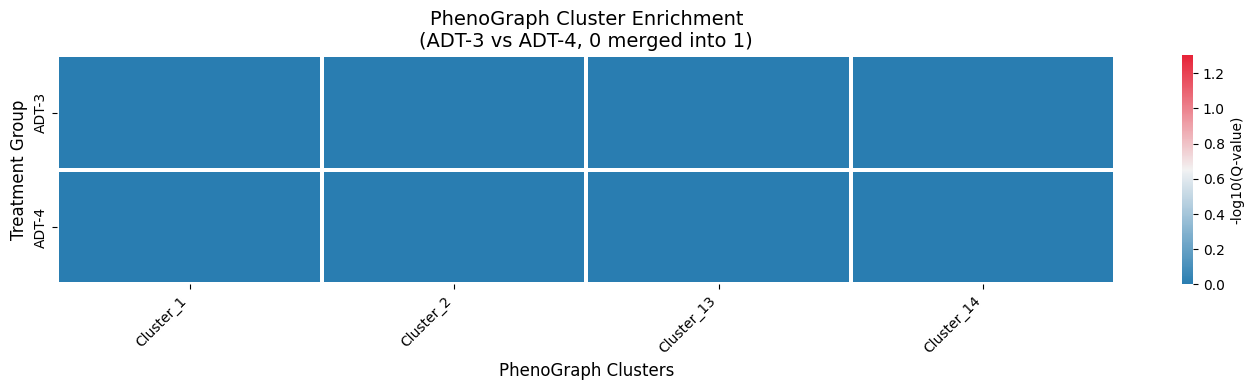

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置路径
# ==========================================
base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno_anno.csv")
output_prefix = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_CRPC_PhenoAnno_Matrix")

print("🚀 运行组合 8 (Matrix Mode): anderson_adt.txt vs mydata_pheno_anno.csv")

# ==========================================
# 2. 辅助函数
# ==========================================
def extract_id(name):
    """从样本名提取数字 ID"""
    if not isinstance(name, str): return None
    name = str(name).strip().strip('"')
    match = re.search(r'(\d+)', name)
    return match.group(1) if match else name

def merge_and_rename_groups(val):
    """
    核心逻辑：处理分组标签
    1. 如果是数字 0 -> 变为 1
    2. 如果是 1 -> 保持 1
    3. 如果是 2 -> 保持 2
    4. 最后映射为可读名称 (1->'N', 2->'mADT')
    """
    if pd.isna(val): return val
    
    # 尝试转为数字
    try:
        num = float(val)
        if num == 0:
            target_num = 1  # 合并 0 到 1
        else:
            target_num = int(num)
        
        # 映射为组名 (根据 anderson_adt.txt 的习惯: 1=N, 2=mADT)
        if target_num == 1:
            return 'N' # 这里包含了原始的 0 和 1
        elif target_num == 2:
            return 'mADT'
        else:
            return f'Group_{target_num}'
    except:
        return str(val)

# ==========================================
# 3. 读取并处理 Label 文件
# ==========================================
# 智能判断分隔符
content = open(file_label).read()
sep = '\t' if content.count('\t') > content.count(',') else ','

df_label = pd.read_csv(file_label, sep=sep)
df_label.columns = [str(c).strip().lower() for c in df_label.columns]

# 重命名列为通用名
df_label.rename(columns={df_label.columns[0]: 'Group_Raw', df_label.columns[1]: 'Sample_Name_Raw'}, inplace=True)

# 【关键步骤】应用合并与重命名逻辑
df_label['Group_Name'] = df_label['Group_Raw'].apply(merge_and_rename_groups)

# 过滤掉无法映射的行
df_label = df_label.dropna(subset=['Group_Name'])

# 提取 Match ID
df_label['Match_ID'] = df_label['Sample_Name_Raw'].astype(str).apply(extract_id)

print(f"✅ Label 文件加载完成")
print(f"   原始分组分布:\n{df_label['Group_Raw'].value_counts().sort_index()}")
print(f"   合并后分组分布:\n{df_label['Group_Name'].value_counts()}")

# 验证是否只剩 2 组
unique_groups = df_label['Group_Name'].unique()
if len(unique_groups) < 2:
    raise Exception(f"❌ 错误：合并后只剩 {len(unique_groups)} 组 ({unique_groups})，无法进行对比。")
elif len(unique_groups) > 2:
    print(f"⚠️ 警告：合并后仍有 {len(unique_groups)} 组。将自动选取数量最多的两组进行对比。")
    top_2 = df_label['Group_Name'].value_counts().nlargest(2).index.tolist()
    df_label = df_label[df_label['Group_Name'].isin(top_2)]
    unique_groups = df_label['Group_Name'].unique()
    print(f"   已筛选两组: {unique_groups}")

# ==========================================
# 4. 读取并处理 Cluster (PhenoGraph) 文件
# ==========================================
df_c_raw = pd.read_csv(file_cluster)
c_name = df_c_raw.columns[0]

# 智能查找 PhenoGraph 列
c_pheno = None
if 'PhenoGraph' in df_c_raw.columns:
    c_pheno = 'PhenoGraph'
else:
    # 查找包含 'Pheno' 的列
    pheno_cols = [c for c in df_c_raw.columns if 'Pheno' in str(c)]
    if pheno_cols:
        c_pheno = pheno_cols[0]
    else:
        # 如果没找到，默认取第二列
        c_pheno = df_c_raw.columns[1]

print(f"   使用列 '{c_pheno}' 作为 Cluster ID")

df_cluster = pd.DataFrame({
    'Sample_Name_Raw': df_c_raw[c_name].astype(str).str.strip().str.replace('"', ''),
    'Cluster_ID': df_c_raw[c_pheno].astype(str).str.strip()
})
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Cluster 文件加载: {len(df_cluster)} 记录, {len(df_cluster['Cluster_ID'].unique())} 个唯一 Cluster")

# ==========================================
# 5. 合并数据
# ==========================================
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')

if len(df_merged) == 0:
    raise Exception("❌ 合并后无数据！请检查 Sample ID 提取逻辑。")

print(f"✅ 成功匹配样本数: {len(df_merged)}")

# 准备矩阵维度
groups = sorted(list(df_merged['Group_Name'].unique()))
group_to_idx = {g: i for i, g in enumerate(groups)}
df_merged['Group_Label'] = df_merged['Group_Name'].map(group_to_idx)

clusters = sorted(df_merged['Cluster_ID'].unique(), key=lambda x: (len(x), x)) # 简单排序
print(f"   对比组别: {groups[0]} vs {groups[1]}")
print(f"   Cluster 总数: {len(clusters)}")

# ==========================================
# 6. Fisher 精确检验 (构建矩阵)
# ==========================================
# 初始化矩阵
p_matrix = pd.DataFrame(1.0, index=groups, columns=[f"Cluster_{c}" for c in clusters])
or_matrix = pd.DataFrame(np.nan, index=groups, columns=[f"Cluster_{c}" for c in clusters])
count_matrix = pd.DataFrame(0, index=groups, columns=[f"Cluster_{c}" for c in clusters])

all_p_two_sided = []
cluster_order = []

print("\n🔍 正在执行 Fisher 精确检验...")

for cl in clusters:
    c_col = f"Cluster_{cl}"
    cluster_order.append(cl)
    
    # 构建列联表
    ct = pd.crosstab(df_merged['Group_Label'], df_merged['Cluster_ID'] == cl)
    ct = ct.reindex(index=[0, 1], columns=[False, True], fill_value=0)
    
    a = ct.loc[0, True]   # Group 0 (e.g., N) has Cluster
    b = ct.loc[0, False]
    c = ct.loc[1, True]   # Group 1 (e.g., mADT) has Cluster
    d = ct.loc[1, False]
    
    count_matrix.loc[groups[0], c_col] = a
    count_matrix.loc[groups[1], c_col] = c
    
    table = [[a, b], [c, d]]
    
    # 边界检查
    if a+b == 0 or c+d == 0 or a+c == 0 or b+d == 0:
        oddsratio = np.nan
        p_two = 1.0
        p_greater = 1.0
        p_less = 1.0
    else:
        oddsratio, p_two = fisher_exact(table, alternative='two-sided')
        _, p_greater = fisher_exact(table, alternative='greater') # Test if Group 0 is enriched
        _, p_less = fisher_exact(table, alternative='less')       # Test if Group 0 is depleted (Group 1 enriched)
    
    all_p_two_sided.append(p_two)
    
    # 【核心逻辑】分配单侧 P 值
    # 如果 OR > 1: Group 0 富集 -> Group 0 填 p_greater, Group 1 填 1.0
    # 如果 OR < 1: Group 1 富集 -> Group 0 填 1.0, Group 1 填 p_less
    if pd.notna(oddsratio) and oddsratio > 1:
        p_matrix.loc[groups[0], c_col] = p_greater
        p_matrix.loc[groups[1], c_col] = 1.0
    elif pd.notna(oddsratio) and oddsratio < 1:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = p_less
    else:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = 1.0
        
    or_matrix.loc[groups[0], c_col] = oddsratio
    or_matrix.loc[groups[1], c_col] = oddsratio

# ==========================================
# 7. FDR 校正
# ==========================================
print("⚖️ 进行 FDR (Benjamini-Hochberg) 校正...")
if len(all_p_two_sided) > 0:
    reject, q_vals, _, _ = multipletests(all_p_two_sided, method='fdr_bh')
    
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)
    
    for i, cl in enumerate(cluster_order):
        c_col = f"Cluster_{cl}"
        q = q_vals[i]
        or_val = or_matrix.loc[groups[0], c_col]
        
        if pd.notna(or_val) and or_val > 1:
            q_matrix.loc[groups[0], c_col] = q
            q_matrix.loc[groups[1], c_col] = 1.0
        elif pd.notna(or_val) and or_val < 1:
            q_matrix.loc[groups[0], c_col] = 1.0
            q_matrix.loc[groups[1], c_col] = q
else:
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)

# ==========================================
# 8. 输出结果摘要
# ==========================================
print("\n" + "="*70)
print("📊 显著性结果摘要 (FDR < 0.05)")
print("="*70)
sig_count = 0
for col in q_matrix.columns:
    q0 = q_matrix.loc[groups[0], col]
    q1 = q_matrix.loc[groups[1], col]
    if q0 < 0.05:
        print(f"   🔴 {col} 显著富集于 [{groups[0]}] (Q={q0:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1
    if q1 < 0.05:
        print(f"   🔵 {col} 显著富集于 [{groups[1]}] (Q={q1:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1

if sig_count == 0:
    print("   ⚪ 未发现显著富集的 Cluster。")

# 保存 CSV 矩阵
count_matrix.to_csv(f"{output_prefix}_Counts.csv")
or_matrix.to_csv(f"{output_prefix}_OR.csv")
p_matrix.to_csv(f"{output_prefix}_PValue.csv")
q_matrix.to_csv(f"{output_prefix}_QValue.csv")

print(f"\n💾 矩阵文件已保存:\n   - {output_prefix}_Counts.csv\n   - {output_prefix}_OR.csv\n   - {output_prefix}_PValue.csv\n   - {output_prefix}_QValue.csv")

# ==========================================
# 9. 绘制热图预览
# ==========================================
plt.figure(figsize=(14, max(4, len(groups)*0.8)))
# 转换 Q 值为 -log10，方便可视化 (0 -> 0, 0.05 -> 1.3, 0.01 -> 2)
# 避免 log(0) 或 log(1)=0 导致的颜色问题，我们只关注显著的部分
q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)

# 设置掩膜：如果不显著 (Q > 0.05)，可以选择不显示颜色或显示浅色
# 这里我们让颜色连续，但设定 vmax 为 -log10(0.05) 以突出显著项
v_max = -np.log10(0.05)

sns.heatmap(q_plot, 
            cmap=sns.diverging_palette(240, 10, s=90, l=50, center="light", as_cmap=True),
            vmin=0, vmax=v_max,
            linewidths=1.5, linecolor='white',
            cbar_kws={'label': '-log10(Q-value)'})

plt.title(f"PhenoGraph Cluster Enrichment\n({groups[0]} vs {groups[1]}, 0 merged into 1)", fontsize=14)
plt.ylabel("Treatment Group", fontsize=12)
plt.xlabel("PhenoGraph Clusters", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plot_file = f"{output_prefix}_Heatmap.png"
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"🖼️ 热图已保存: {plot_file}")
plt.show()

🚀 运行组合 7 (Matrix Mode + Merge): anderson_adt.txt vs dat_CN_percent_class.csv (行对齐)
📥 读取参考样本列表以进行行对齐...
   参考样本总数: 106
✅ Label 文件加载完成
   原始分组分布:
Group_Raw
ADT-10    1
ADT-11    1
ADT-12    1
ADT-14    1
ADT-15    1
ADT-16    1
ADT-17    1
ADT-18    1
ADT-20    1
ADT-21    1
ADT-22    1
ADT-23    1
ADT-24    1
ADT-25    1
ADT-26    1
ADT-28    1
ADT-29    1
ADT-3     1
ADT-30    1
ADT-31    1
ADT-33    1
ADT-34    1
ADT-35    1
ADT-36    1
ADT-37    1
ADT-39    1
ADT-4     1
ADT-40    1
ADT-42    1
ADT-45    1
ADT-46    1
ADT-47    1
ADT-48    1
ADT-49    1
ADT-5     1
ADT-50    1
ADT-51    1
ADT-52    1
ADT-6     1
ADT-8     1
ADT-9     1
Name: count, dtype: int64
   合并后分组分布:
Group_Name
ADT-3     1
ADT-4     1
ADT-5     1
ADT-6     1
ADT-8     1
ADT-9     1
ADT-10    1
ADT-11    1
ADT-12    1
ADT-14    1
ADT-15    1
ADT-16    1
ADT-17    1
ADT-18    1
ADT-20    1
ADT-21    1
ADT-22    1
ADT-23    1
ADT-24    1
ADT-25    1
ADT-26    1
ADT-28    1
ADT-29    1
ADT-30    1
ADT-31    1
ADT-3

/tmp/ipykernel_254686/2150139432.py:259: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)


🖼️ 热图已保存: /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_CNClass_Matrix_Heatmap.png


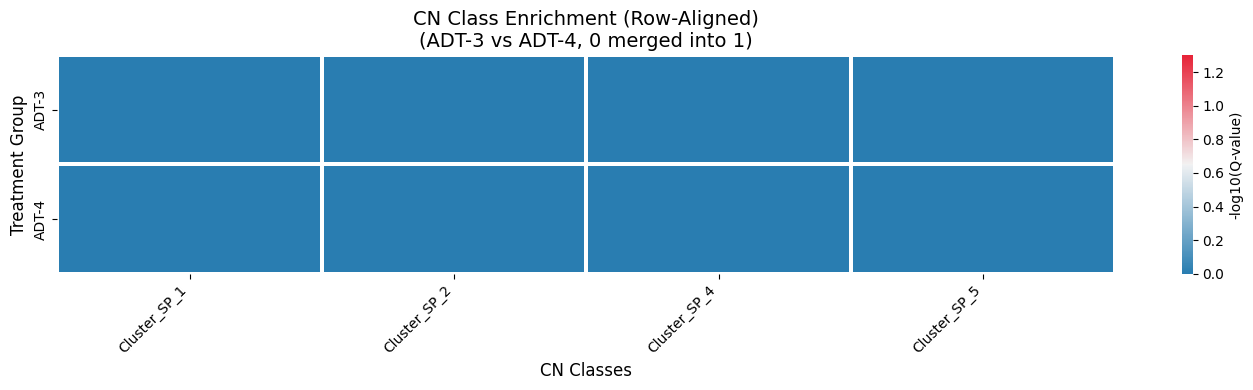

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置路径
# ==========================================
base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster_raw = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/dat_CN_percent_class.csv")
file_ref_samples = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno02.csv")
output_prefix = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_CRPC_CNClass_Matrix")

print("🚀 运行组合 7 (Matrix Mode + Merge): anderson_adt.txt vs dat_CN_percent_class.csv (行对齐)")

# ==========================================
# 2. 辅助函数
# ==========================================
def extract_id(name):
    """从样本名提取数字 ID"""
    if not isinstance(name, str): return None
    name = str(name).strip().strip('"')
    match = re.search(r'(\d+)', name)
    return match.group(1) if match else name

def merge_and_rename_groups(val):
    """
    核心逻辑：处理分组标签
    1. 如果是数字 0 -> 变为 1
    2. 如果是 1 -> 保持 1
    3. 如果是 2 -> 保持 2
    4. 映射为可读名称 (1->'N', 2->'mADT')
    """
    if pd.isna(val): return val
    try:
        num = float(val)
        if num == 0:
            target_num = 1  # 合并 0 到 1
        else:
            target_num = int(num)
        
        # 映射规则
        if target_num == 1:
            return 'N'      # 包含原始 0 和 1
        elif target_num == 2:
            return 'mADT'
        else:
            return f'Group_{target_num}'
    except:
        return str(val)

# ==========================================
# 3. 读取参考样本 (用于行对齐)
# ==========================================
print("📥 读取参考样本列表以进行行对齐...")
df_ref = pd.read_csv(file_ref_samples)
# 假设第一列是样本名
standard_samples = df_ref.iloc[:, 0].astype(str).str.strip().str.replace('"', '').tolist()
print(f"   参考样本总数: {len(standard_samples)}")

# ==========================================
# 4. 读取并处理 Label 文件 (Anderson)
# ==========================================
content = open(file_label).read()
sep = '\t' if content.count('\t') > content.count(',') else ','

df_label = pd.read_csv(file_label, sep=sep)
df_label.columns = [str(c).strip().lower() for c in df_label.columns]
df_label.rename(columns={df_label.columns[0]: 'Group_Raw', df_label.columns[1]: 'Sample_Name_Raw'}, inplace=True)

# 【关键步骤】应用合并与重命名逻辑
df_label['Group_Name'] = df_label['Group_Raw'].apply(merge_and_rename_groups)
df_label = df_label.dropna(subset=['Group_Name'])
df_label['Match_ID'] = df_label['Sample_Name_Raw'].astype(str).apply(extract_id)

print(f"✅ Label 文件加载完成")
print(f"   原始分组分布:\n{df_label['Group_Raw'].value_counts().sort_index()}")
print(f"   合并后分组分布:\n{df_label['Group_Name'].value_counts()}")

# 验证组数
unique_groups = df_label['Group_Name'].unique()
if len(unique_groups) < 2:
    raise Exception(f"❌ 错误：合并后只剩 {len(unique_groups)} 组，无法对比。")
elif len(unique_groups) > 2:
    print(f"⚠️ 警告：合并后仍有 {len(unique_groups)} 组。将自动选取数量最多的两组。")
    top_2 = df_label['Group_Name'].value_counts().nlargest(2).index.tolist()
    df_label = df_label[df_label['Group_Name'].isin(top_2)]
    unique_groups = df_label['Group_Name'].unique()

# ==========================================
# 5. 读取并处理 Cluster 文件 (行对齐逻辑)
# ==========================================
print("📥 读取 CN Class 数据 (行对齐模式)...")
df_c_raw = pd.read_csv(file_cluster_raw)

# 获取最后一列作为 Cluster ID
cluster_vals = df_c_raw.iloc[:, -1].astype(str).str.strip()

# 【核心逻辑】行对齐
min_len = min(len(cluster_vals), len(standard_samples))
if min_len == 0:
    raise Exception("❌ 参考样本或 Cluster 数据为空，无法对齐。")

print(f"   对齐长度: {min_len} (Cluster 原始:{len(cluster_vals)}, 参考:{len(standard_samples)})")

df_cluster = pd.DataFrame({
    'Sample_Name_Raw': standard_samples[:min_len],
    'Cluster_ID': cluster_vals.iloc[:min_len].values
})

# 去除可能的空值
df_cluster = df_cluster.dropna(subset=['Cluster_ID', 'Sample_Name_Raw'])
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Cluster 数据构建完成: {len(df_cluster)} 个样本, {len(df_cluster['Cluster_ID'].unique())} 个唯一类别")

# ==========================================
# 6. 合并数据
# ==========================================
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')

if len(df_merged) == 0:
    raise Exception("❌ 合并后无数据！请检查 Match_ID 提取逻辑是否一致。")

print(f"✅ 成功匹配样本数: {len(df_merged)}")

# 准备矩阵维度
groups = sorted(list(df_merged['Group_Name'].unique()))
group_to_idx = {g: i for i, g in enumerate(groups)}
df_merged['Group_Label'] = df_merged['Group_Name'].map(group_to_idx)

# 对 Cluster ID 进行排序 (尝试按数字排序，如果不行则按字符串)
def sort_key(x):
    try:
        return (0, float(x))
    except:
        return (1, str(x))

clusters = sorted(df_merged['Cluster_ID'].unique(), key=sort_key)
print(f"   对比组别: {groups[0]} vs {groups[1]}")
print(f"   Cluster 总数: {len(clusters)}")

# ==========================================
# 7. Fisher 精确检验 (构建矩阵)
# ==========================================
p_matrix = pd.DataFrame(1.0, index=groups, columns=[f"Cluster_{c}" for c in clusters])
or_matrix = pd.DataFrame(np.nan, index=groups, columns=[f"Cluster_{c}" for c in clusters])
count_matrix = pd.DataFrame(0, index=groups, columns=[f"Cluster_{c}" for c in clusters])

all_p_two_sided = []
cluster_order = []

print("\n🔍 正在执行 Fisher 精确检验...")

for cl in clusters:
    c_col = f"Cluster_{cl}"
    cluster_order.append(cl)
    
    # 构建列联表
    ct = pd.crosstab(df_merged['Group_Label'], df_merged['Cluster_ID'] == cl)
    ct = ct.reindex(index=[0, 1], columns=[False, True], fill_value=0)
    
    a = ct.loc[0, True]   # Group 0 (N) has Cluster
    b = ct.loc[0, False]
    c = ct.loc[1, True]   # Group 1 (mADT) has Cluster
    d = ct.loc[1, False]
    
    count_matrix.loc[groups[0], c_col] = a
    count_matrix.loc[groups[1], c_col] = c
    
    table = [[a, b], [c, d]]
    
    if a+b == 0 or c+d == 0 or a+c == 0 or b+d == 0:
        oddsratio = np.nan
        p_two = 1.0
        p_greater = 1.0
        p_less = 1.0
    else:
        oddsratio, p_two = fisher_exact(table, alternative='two-sided')
        _, p_greater = fisher_exact(table, alternative='greater')
        _, p_less = fisher_exact(table, alternative='less')
    
    all_p_two_sided.append(p_two)
    
    # 分配单侧 P 值
    if pd.notna(oddsratio) and oddsratio > 1:
        p_matrix.loc[groups[0], c_col] = p_greater
        p_matrix.loc[groups[1], c_col] = 1.0
    elif pd.notna(oddsratio) and oddsratio < 1:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = p_less
    else:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = 1.0
        
    or_matrix.loc[groups[0], c_col] = oddsratio
    or_matrix.loc[groups[1], c_col] = oddsratio

# ==========================================
# 8. FDR 校正
# ==========================================
print("⚖️ 进行 FDR 校正...")
if len(all_p_two_sided) > 0:
    reject, q_vals, _, _ = multipletests(all_p_two_sided, method='fdr_bh')
    
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)
    
    for i, cl in enumerate(cluster_order):
        c_col = f"Cluster_{cl}"
        q = q_vals[i]
        or_val = or_matrix.loc[groups[0], c_col]
        
        if pd.notna(or_val) and or_val > 1:
            q_matrix.loc[groups[0], c_col] = q
            q_matrix.loc[groups[1], c_col] = 1.0
        elif pd.notna(or_val) and or_val < 1:
            q_matrix.loc[groups[0], c_col] = 1.0
            q_matrix.loc[groups[1], c_col] = q
else:
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)

# ==========================================
# 9. 输出结果摘要
# ==========================================
print("\n" + "="*70)
print("📊 显著性结果摘要 (FDR < 0.05)")
print("="*70)
sig_count = 0
for col in q_matrix.columns:
    q0 = q_matrix.loc[groups[0], col]
    q1 = q_matrix.loc[groups[1], col]
    if q0 < 0.05:
        print(f"   🔴 {col} 显著富集于 [{groups[0]}] (Q={q0:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1
    if q1 < 0.05:
        print(f"   🔵 {col} 显著富集于 [{groups[1]}] (Q={q1:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1

if sig_count == 0:
    print("   ⚪ 未发现显著富集的 Cluster。")

# 保存 CSV 矩阵
count_matrix.to_csv(f"{output_prefix}_Counts.csv")
or_matrix.to_csv(f"{output_prefix}_OR.csv")
p_matrix.to_csv(f"{output_prefix}_PValue.csv")
q_matrix.to_csv(f"{output_prefix}_QValue.csv")

print(f"\n💾 矩阵文件已保存:\n   - {output_prefix}_Counts.csv\n   - {output_prefix}_OR.csv\n   - {output_prefix}_PValue.csv\n   - {output_prefix}_QValue.csv")

# ==========================================
# 10. 绘制热图预览
# ==========================================
plt.figure(figsize=(14, max(4, len(groups)*0.8)))
q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)
v_max = -np.log10(0.05)

sns.heatmap(q_plot, 
            cmap=sns.diverging_palette(240, 10, s=90, l=50, center="light", as_cmap=True),
            vmin=0, vmax=v_max,
            linewidths=1.5, linecolor='white',
            cbar_kws={'label': '-log10(Q-value)'})

plt.title(f"CN Class Enrichment (Row-Aligned)\n({groups[0]} vs {groups[1]}, 0 merged into 1)", fontsize=14)
plt.ylabel("Treatment Group", fontsize=12)
plt.xlabel("CN Classes", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plot_file = f"{output_prefix}_Heatmap.png"
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"🖼️ 热图已保存: {plot_file}")
plt.show()

🚀 运行组合 7 (Matrix Mode + Merge): anderson_adt.txt vs dat_CN_percent_class.csv (行对齐)
📥 读取参考样本列表以进行行对齐...
   参考样本总数: 106
✅ Label 文件加载完成
   原始分组分布:
Group_Raw
ADT-10    1
ADT-11    1
ADT-12    1
ADT-14    1
ADT-15    1
ADT-16    1
ADT-17    1
ADT-18    1
ADT-20    1
ADT-21    1
ADT-22    1
ADT-23    1
ADT-24    1
ADT-25    1
ADT-26    1
ADT-28    1
ADT-29    1
ADT-3     1
ADT-30    1
ADT-31    1
ADT-33    1
ADT-34    1
ADT-35    1
ADT-36    1
ADT-37    1
ADT-39    1
ADT-4     1
ADT-40    1
ADT-42    1
ADT-45    1
ADT-46    1
ADT-47    1
ADT-48    1
ADT-49    1
ADT-5     1
ADT-50    1
ADT-51    1
ADT-52    1
ADT-6     1
ADT-8     1
ADT-9     1
Name: count, dtype: int64
   合并后分组分布:
Group_Name
ADT-3     1
ADT-4     1
ADT-5     1
ADT-6     1
ADT-8     1
ADT-9     1
ADT-10    1
ADT-11    1
ADT-12    1
ADT-14    1
ADT-15    1
ADT-16    1
ADT-17    1
ADT-18    1
ADT-20    1
ADT-21    1
ADT-22    1
ADT-23    1
ADT-24    1
ADT-25    1
ADT-26    1
ADT-28    1
ADT-29    1
ADT-30    1
ADT-31    1
ADT-3

/tmp/ipykernel_254686/2941492483.py:259: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)


🖼️ 热图已保存: /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_CNClass_Matrix_Heatmap.png


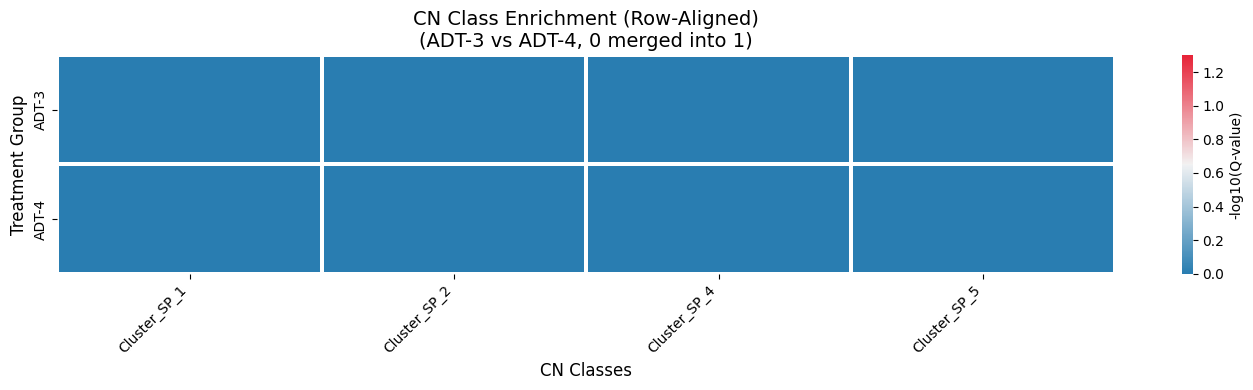

In [14]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置路径
# ==========================================
base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster_raw = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/dat_CN_percent_class.csv")
file_ref_samples = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno02.csv")
output_prefix = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_CRPC_CNClass_Matrix")

print("🚀 运行组合 7 (Matrix Mode + Merge): anderson_adt.txt vs dat_CN_percent_class.csv (行对齐)")

# ==========================================
# 2. 辅助函数
# ==========================================
def extract_id(name):
    """从样本名提取数字 ID"""
    if not isinstance(name, str): return None
    name = str(name).strip().strip('"')
    match = re.search(r'(\d+)', name)
    return match.group(1) if match else name

def merge_and_rename_groups(val):
    """
    核心逻辑：处理分组标签
    1. 如果是数字 0 -> 变为 1
    2. 如果是 1 -> 保持 1
    3. 如果是 2 -> 保持 2
    4. 映射为可读名称 (1->'N', 2->'mADT')
    """
    if pd.isna(val): return val
    try:
        num = float(val)
        if num == 0:
            target_num = 1  # 【关键】合并 0 到 1
        else:
            target_num = int(num)
        
        # 映射规则
        if target_num == 1:
            return 'N'      # 包含原始 0 和 1
        elif target_num == 2:
            return 'mADT'
        else:
            return f'Group_{target_num}'
    except:
        return str(val)

# ==========================================
# 3. 读取参考样本 (用于行对齐)
# ==========================================
print("📥 读取参考样本列表以进行行对齐...")
df_ref = pd.read_csv(file_ref_samples)
# 假设第一列是样本名
standard_samples = df_ref.iloc[:, 0].astype(str).str.strip().str.replace('"', '').tolist()
print(f"   参考样本总数: {len(standard_samples)}")

# ==========================================
# 4. 读取并处理 Label 文件 (Anderson)
# ==========================================
content = open(file_label).read()
sep = '\t' if content.count('\t') > content.count(',') else ','

df_label = pd.read_csv(file_label, sep=sep)
df_label.columns = [str(c).strip().lower() for c in df_label.columns]
df_label.rename(columns={df_label.columns[0]: 'Group_Raw', df_label.columns[1]: 'Sample_Name_Raw'}, inplace=True)

# 【关键步骤】应用合并与重命名逻辑
df_label['Group_Name'] = df_label['Group_Raw'].apply(merge_and_rename_groups)
df_label = df_label.dropna(subset=['Group_Name'])
df_label['Match_ID'] = df_label['Sample_Name_Raw'].astype(str).apply(extract_id)

print(f"✅ Label 文件加载完成")
print(f"   原始分组分布:\n{df_label['Group_Raw'].value_counts().sort_index()}")
print(f"   合并后分组分布:\n{df_label['Group_Name'].value_counts()}")

# 验证组数
unique_groups = df_label['Group_Name'].unique()
if len(unique_groups) < 2:
    raise Exception(f"❌ 错误：合并后只剩 {len(unique_groups)} 组，无法对比。")
elif len(unique_groups) > 2:
    print(f"⚠️ 警告：合并后仍有 {len(unique_groups)} 组。将自动选取数量最多的两组。")
    top_2 = df_label['Group_Name'].value_counts().nlargest(2).index.tolist()
    df_label = df_label[df_label['Group_Name'].isin(top_2)]
    unique_groups = df_label['Group_Name'].unique()

# ==========================================
# 5. 读取并处理 Cluster 文件 (行对齐逻辑)
# ==========================================
print("📥 读取 CN Class 数据 (行对齐模式)...")
df_c_raw = pd.read_csv(file_cluster_raw)

# 获取最后一列作为 Cluster ID
cluster_vals = df_c_raw.iloc[:, -1].astype(str).str.strip()

# 【核心逻辑】行对齐
min_len = min(len(cluster_vals), len(standard_samples))
if min_len == 0:
    raise Exception("❌ 参考样本或 Cluster 数据为空，无法对齐。")

print(f"   对齐长度: {min_len} (Cluster 原始:{len(cluster_vals)}, 参考:{len(standard_samples)})")

df_cluster = pd.DataFrame({
    'Sample_Name_Raw': standard_samples[:min_len],
    'Cluster_ID': cluster_vals.iloc[:min_len].values
})

# 去除可能的空值
df_cluster = df_cluster.dropna(subset=['Cluster_ID', 'Sample_Name_Raw'])
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Cluster 数据构建完成: {len(df_cluster)} 个样本, {len(df_cluster['Cluster_ID'].unique())} 个唯一类别")

# ==========================================
# 6. 合并数据
# ==========================================
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')

if len(df_merged) == 0:
    raise Exception("❌ 合并后无数据！请检查 Match_ID 提取逻辑是否一致。")

print(f"✅ 成功匹配样本数: {len(df_merged)}")

# 准备矩阵维度
groups = sorted(list(df_merged['Group_Name'].unique()))
group_to_idx = {g: i for i, g in enumerate(groups)}
df_merged['Group_Label'] = df_merged['Group_Name'].map(group_to_idx)

# 对 Cluster ID 进行排序 (尝试按数字排序，如果不行则按字符串)
def sort_key(x):
    try:
        return (0, float(x))
    except:
        return (1, str(x))

clusters = sorted(df_merged['Cluster_ID'].unique(), key=sort_key)
print(f"   对比组别: {groups[0]} vs {groups[1]}")
print(f"   Cluster 总数: {len(clusters)}")

# ==========================================
# 7. Fisher 精确检验 (构建矩阵)
# ==========================================
p_matrix = pd.DataFrame(1.0, index=groups, columns=[f"Cluster_{c}" for c in clusters])
or_matrix = pd.DataFrame(np.nan, index=groups, columns=[f"Cluster_{c}" for c in clusters])
count_matrix = pd.DataFrame(0, index=groups, columns=[f"Cluster_{c}" for c in clusters])

all_p_two_sided = []
cluster_order = []

print("\n🔍 正在执行 Fisher 精确检验...")

for cl in clusters:
    c_col = f"Cluster_{cl}"
    cluster_order.append(cl)
    
    # 构建列联表
    ct = pd.crosstab(df_merged['Group_Label'], df_merged['Cluster_ID'] == cl)
    ct = ct.reindex(index=[0, 1], columns=[False, True], fill_value=0)
    
    a = ct.loc[0, True]   # Group 0 (N) has Cluster
    b = ct.loc[0, False]
    c = ct.loc[1, True]   # Group 1 (mADT) has Cluster
    d = ct.loc[1, False]
    
    count_matrix.loc[groups[0], c_col] = a
    count_matrix.loc[groups[1], c_col] = c
    
    table = [[a, b], [c, d]]
    
    if a+b == 0 or c+d == 0 or a+c == 0 or b+d == 0:
        oddsratio = np.nan
        p_two = 1.0
        p_greater = 1.0
        p_less = 1.0
    else:
        oddsratio, p_two = fisher_exact(table, alternative='two-sided')
        _, p_greater = fisher_exact(table, alternative='greater')
        _, p_less = fisher_exact(table, alternative='less')
    
    all_p_two_sided.append(p_two)
    
    # 分配单侧 P 值
    if pd.notna(oddsratio) and oddsratio > 1:
        p_matrix.loc[groups[0], c_col] = p_greater
        p_matrix.loc[groups[1], c_col] = 1.0
    elif pd.notna(oddsratio) and oddsratio < 1:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = p_less
    else:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = 1.0
        
    or_matrix.loc[groups[0], c_col] = oddsratio
    or_matrix.loc[groups[1], c_col] = oddsratio

# ==========================================
# 8. FDR 校正
# ==========================================
print("⚖️ 进行 FDR 校正...")
if len(all_p_two_sided) > 0:
    reject, q_vals, _, _ = multipletests(all_p_two_sided, method='fdr_bh')
    
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)
    
    for i, cl in enumerate(cluster_order):
        c_col = f"Cluster_{cl}"
        q = q_vals[i]
        or_val = or_matrix.loc[groups[0], c_col]
        
        if pd.notna(or_val) and or_val > 1:
            q_matrix.loc[groups[0], c_col] = q
            q_matrix.loc[groups[1], c_col] = 1.0
        elif pd.notna(or_val) and or_val < 1:
            q_matrix.loc[groups[0], c_col] = 1.0
            q_matrix.loc[groups[1], c_col] = q
else:
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)

# ==========================================
# 9. 输出结果摘要
# ==========================================
print("\n" + "="*70)
print("📊 显著性结果摘要 (FDR < 0.05)")
print("="*70)
sig_count = 0
for col in q_matrix.columns:
    q0 = q_matrix.loc[groups[0], col]
    q1 = q_matrix.loc[groups[1], col]
    if q0 < 0.05:
        print(f"   🔴 {col} 显著富集于 [{groups[0]}] (Q={q0:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1
    if q1 < 0.05:
        print(f"   🔵 {col} 显著富集于 [{groups[1]}] (Q={q1:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1

if sig_count == 0:
    print("   ⚪ 未发现显著富集的 Cluster。")

# 保存 CSV 矩阵
count_matrix.to_csv(f"{output_prefix}_Counts.csv")
or_matrix.to_csv(f"{output_prefix}_OR.csv")
p_matrix.to_csv(f"{output_prefix}_PValue.csv")
q_matrix.to_csv(f"{output_prefix}_QValue.csv")

print(f"\n💾 矩阵文件已保存:\n   - {output_prefix}_Counts.csv\n   - {output_prefix}_OR.csv\n   - {output_prefix}_PValue.csv\n   - {output_prefix}_QValue.csv")

# ==========================================
# 10. 绘制热图预览
# ==========================================
plt.figure(figsize=(14, max(4, len(groups)*0.8)))
q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)
v_max = -np.log10(0.05)

sns.heatmap(q_plot, 
            cmap=sns.diverging_palette(240, 10, s=90, l=50, center="light", as_cmap=True),
            vmin=0, vmax=v_max,
            linewidths=1.5, linecolor='white',
            cbar_kws={'label': '-log10(Q-value)'})

plt.title(f"CN Class Enrichment (Row-Aligned)\n({groups[0]} vs {groups[1]}, 0 merged into 1)", fontsize=14)
plt.ylabel("Treatment Group", fontsize=12)
plt.xlabel("CN Classes", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plot_file = f"{output_prefix}_Heatmap.png"
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"🖼️ 热图已保存: {plot_file}")
plt.show()

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置路径
# ==========================================
base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno_anno.csv")
output_prefix = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_CRPC_PhenoAnno_Matrix")

print("🚀 运行组合 5 (Matrix Mode): gleason.txt vs mydata_pheno_anno.csv")

# ==========================================
# 2. 辅助函数
# ==========================================
def extract_id(name):
    """从样本名提取数字 ID"""
    if not isinstance(name, str): return None
    name = str(name).strip().strip('"')
    match = re.search(r'(\d+)', name)
    return match.group(1) if match else name

def map_gleason_score(val):
    """
    核心逻辑：Gleason 评分分组
    6, 7 -> 'Low'
    8, 9   -> 'High'
    其他   -> NaN (将被过滤)
    """
    if pd.isna(val):
        return np.nan
    
    try:
        # 尝试转为整数 (处理 "6", "7.0", 6 等情况)
        score = int(float(val))
        
        if score in [6, 7]:
            return 'Low'
        elif score in [8, 9, 10]: # 包含10以防万一
            return 'High'
        else:
            return np.nan # 未知评分
    except (ValueError, TypeError):
        return np.nan

# ==========================================
# 3. 读取并处理 Label 文件 (Gleason)
# ==========================================
content = open(file_label).read()
sep = '\t' if content.count('\t') > content.count(',') else ','

df_label = pd.read_csv(file_label, sep=sep)
df_label.columns = [str(c).strip().lower() for c in df_label.columns]

# 重命名列为通用名 (假设第一列是样本名，第二列是分数)
df_label.rename(columns={df_label.columns[0]: 'Sample_Name_Raw', df_label.columns[1]: 'Score'}, inplace=True)

# 【关键步骤】应用 Gleason 分组逻辑
df_label['Group_Name'] = df_label['Score'].apply(map_gleason_score)
df_label = df_label.dropna(subset=['Group_Name'])

df_label['Match_ID'] = df_label['Sample_Name_Raw'].astype(str).apply(extract_id)

print(f"✅ Label 文件加载完成")
print(f"   原始评分分布:\n{df_label['Score'].value_counts().sort_index()}")
print(f"   分组后分布:\n{df_label['Group_Name'].value_counts()}")

# 验证组数
unique_groups = df_label['Group_Name'].unique()
if len(unique_groups) < 2:
    raise Exception(f"❌ 错误：分组后只剩 {len(unique_groups)} 组 ({unique_groups})，无法对比。")
elif len(unique_groups) > 2:
    print(f"⚠️ 警告：分组后仍有 {len(unique_groups)} 组。将自动选取数量最多的两组。")
    top_2 = df_label['Group_Name'].value_counts().nlargest(2).index.tolist()
    df_label = df_label[df_label['Group_Name'].isin(top_2)]
    unique_groups = df_label['Group_Name'].unique()

# ==========================================
# 4. 读取并处理 Cluster (PhenoGraph) 文件
# ==========================================
df_c_raw = pd.read_csv(file_cluster)
c_name = df_c_raw.columns[0]

# 智能查找 PhenoGraph 列
c_pheno = None
if 'PhenoGraph' in df_c_raw.columns:
    c_pheno = 'PhenoGraph'
else:
    pheno_cols = [c for c in df_c_raw.columns if 'Pheno' in str(c)]
    if pheno_cols:
        c_pheno = pheno_cols[0]
    else:
        c_pheno = df_c_raw.columns[1] # 默认取第二列

print(f"   使用列 '{c_pheno}' 作为 Cluster ID")

df_cluster = pd.DataFrame({
    'Sample_Name_Raw': df_c_raw[c_name].astype(str).str.strip().str.replace('"', ''),
    'Cluster_ID': df_c_raw[c_pheno].astype(str).str.strip()
})
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Cluster 文件加载: {len(df_cluster)} 记录, {len(df_cluster['Cluster_ID'].unique())} 个唯一 Cluster")

# ==========================================
# 5. 合并数据
# ==========================================
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')

if len(df_merged) == 0:
    raise Exception("❌ 合并后无数据！请检查 Sample ID 提取逻辑。")

print(f"✅ 成功匹配样本数: {len(df_merged)}")

# 准备矩阵维度
groups = sorted(list(df_merged['Group_Name'].unique())) # 应该是 ['High', 'Low']
group_to_idx = {g: i for i, g in enumerate(groups)}
df_merged['Group_Label'] = df_merged['Group_Name'].map(group_to_idx)

clusters = sorted(df_merged['Cluster_ID'].unique(), key=lambda x: (len(x), x))
print(f"   对比组别: {groups[0]} vs {groups[1]}")
print(f"   Cluster 总数: {len(clusters)}")

# ==========================================
# 6. Fisher 精确检验 (构建矩阵)
# ==========================================
p_matrix = pd.DataFrame(1.0, index=groups, columns=[f"Cluster_{c}" for c in clusters])
or_matrix = pd.DataFrame(np.nan, index=groups, columns=[f"Cluster_{c}" for c in clusters])
count_matrix = pd.DataFrame(0, index=groups, columns=[f"Cluster_{c}" for c in clusters])

all_p_two_sided = []
cluster_order = []

print("\n🔍 正在执行 Fisher 精确检验...")

for cl in clusters:
    c_col = f"Cluster_{cl}"
    cluster_order.append(cl)
    
    # 构建列联表
    ct = pd.crosstab(df_merged['Group_Label'], df_merged['Cluster_ID'] == cl)
    ct = ct.reindex(index=[0, 1], columns=[False, True], fill_value=0)
    
    a = ct.loc[0, True]   # Group 0 (e.g., High) has Cluster
    b = ct.loc[0, False]
    c = ct.loc[1, True]   # Group 1 (e.g., Low) has Cluster
    d = ct.loc[1, False]
    
    count_matrix.loc[groups[0], c_col] = a
    count_matrix.loc[groups[1], c_col] = c
    
    table = [[a, b], [c, d]]
    
    if a+b == 0 or c+d == 0 or a+c == 0 or b+d == 0:
        oddsratio = np.nan
        p_two = 1.0
        p_greater = 1.0
        p_less = 1.0
    else:
        oddsratio, p_two = fisher_exact(table, alternative='two-sided')
        _, p_greater = fisher_exact(table, alternative='greater') # Test if Group 0 is enriched
        _, p_less = fisher_exact(table, alternative='less')       # Test if Group 0 is depleted
        
    all_p_two_sided.append(p_two)
    
    # 分配单侧 P 值
    if pd.notna(oddsratio) and oddsratio > 1:
        # Group 0 富集
        p_matrix.loc[groups[0], c_col] = p_greater
        p_matrix.loc[groups[1], c_col] = 1.0
    elif pd.notna(oddsratio) and oddsratio < 1:
        # Group 1 富集 (Group 0  depletion)
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = p_less
    else:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = 1.0
        
    or_matrix.loc[groups[0], c_col] = oddsratio
    or_matrix.loc[groups[1], c_col] = oddsratio

# ==========================================
# 7. FDR 校正
# ==========================================
print("⚖️ 进行 FDR (Benjamini-Hochberg) 校正...")
if len(all_p_two_sided) > 0:
    reject, q_vals, _, _ = multipletests(all_p_two_sided, method='fdr_bh')
    
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)
    
    for i, cl in enumerate(cluster_order):
        c_col = f"Cluster_{cl}"
        q = q_vals[i]
        or_val = or_matrix.loc[groups[0], c_col]
        
        if pd.notna(or_val) and or_val > 1:
            q_matrix.loc[groups[0], c_col] = q
            q_matrix.loc[groups[1], c_col] = 1.0
        elif pd.notna(or_val) and or_val < 1:
            q_matrix.loc[groups[0], c_col] = 1.0
            q_matrix.loc[groups[1], c_col] = q
else:
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)

# ==========================================
# 8. 输出结果摘要
# ==========================================
print("\n" + "="*70)
print("📊 显著性结果摘要 (FDR < 0.05)")
print("="*70)
sig_count = 0
for col in q_matrix.columns:
    q0 = q_matrix.loc[groups[0], col]
    q1 = q_matrix.loc[groups[1], col]
    if q0 < 0.05:
        print(f"   🔴 {col} 显著富集于 [{groups[0]}] (Q={q0:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1
    if q1 < 0.05:
        print(f"   🔵 {col} 显著富集于 [{groups[1]}] (Q={q1:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1

if sig_count == 0:
    print("   ⚪ 未发现显著富集的 Cluster。")

# 保存 CSV 矩阵
count_matrix.to_csv(f"{output_prefix}_Counts.csv")
or_matrix.to_csv(f"{output_prefix}_OR.csv")
p_matrix.to_csv(f"{output_prefix}_PValue.csv")
q_matrix.to_csv(f"{output_prefix}_QValue.csv")

print(f"\n💾 矩阵文件已保存:\n   - {output_prefix}_Counts.csv\n   - {output_prefix}_OR.csv\n   - {output_prefix}_PValue.csv\n   - {output_prefix}_QValue.csv")

# ==========================================
# 9. 绘制热图预览
# ==========================================
plt.figure(figsize=(14, max(4, len(groups)*0.8)))
# 转换 Q 值为 -log10
q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)
v_max = -np.log10(0.05)

sns.heatmap(q_plot, 
            cmap=sns.diverging_palette(240, 10, s=90, l=50, center="light", as_cmap=True),
            vmin=0, vmax=v_max,
            linewidths=1.5, linecolor='white',
            cbar_kws={'label': '-log10(Q-value)'})

plt.title(f"PhenoGraph Cluster Enrichment\n({groups[0]} vs {groups[1]}, Gleason Score)", fontsize=14)
plt.ylabel("Gleason Group", fontsize=12)
plt.xlabel("PhenoGraph Clusters", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plot_file = f"{output_prefix}_Heatmap.png"
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"🖼️ 热图已保存: {plot_file}")
plt.show()

🚀 运行组合 5 (Matrix Mode): gleason.txt vs mydata_pheno_anno.csv
✅ Label 文件加载完成
   原始评分分布:
Series([], Name: count, dtype: int64)
   分组后分布:
Series([], Name: count, dtype: int64)


Exception: ❌ 错误：分组后只剩 0 组 ([])，无法对比。

🚀 运行组合 3 (Matrix Mode): label.csv vs mydata_pheno02.csv (Tumor Purity)
📥 读取 Label 文件...
✅ Label 文件加载完成
   分组分布:
Group_Name
2    28
1    13
Name: count, dtype: int64
📥 读取 Purity 数据...
   使用列 'TumorPurityLevel' 作为 Purity Level (Cluster ID)
✅ Purity 数据加载: 106 记录, 3 个唯一等级
✅ 成功匹配样本数: 80
   对比组别: 1 vs 2
   Purity 等级总数: 3 (['H', 'L', 'M'])

🔍 正在执行 Fisher 精确检验...
⚖️ 进行 FDR (Benjamini-Hochberg) 校正...

📊 显著性结果摘要 (FDR < 0.05)
   ⚪ 未发现显著富集的 Purity Level。

💾 矩阵文件已保存:
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_Purity_Matrix_Counts.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_Purity_Matrix_OR.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_Purity_Matrix_PValue.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_Pu

/tmp/ipykernel_254686/221468695.py:254: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)


🖼️ 热图已保存: /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_Purity_Matrix_Heatmap.png


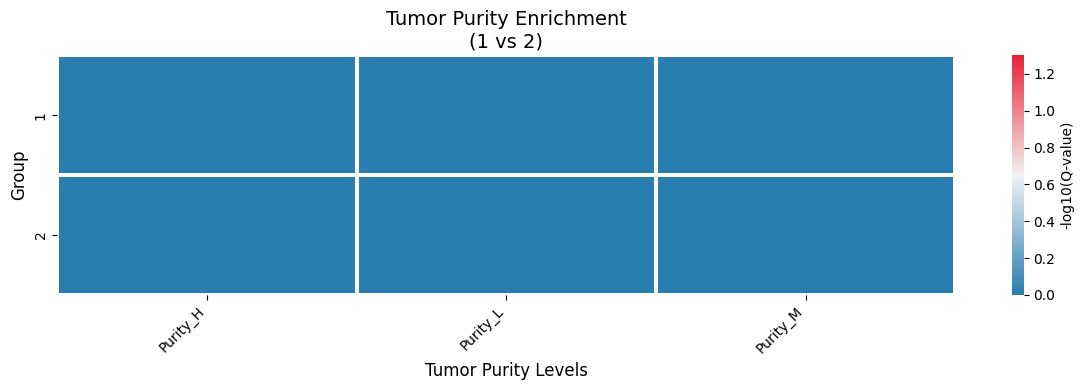

In [16]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置路径
# ==========================================
base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno02.csv")
output_prefix = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_CRPC_Purity_Matrix")

print("🚀 运行组合 3 (Matrix Mode): label.csv vs mydata_pheno02.csv (Tumor Purity)")

# ==========================================
# 2. 辅助函数
# ==========================================
def extract_id(name):
    """从样本名提取数字 ID"""
    if not isinstance(name, str): return None
    name = str(name).strip().strip('"')
    match = re.search(r'(\d+)', name)
    return match.group(1) if match else name

# ==========================================
# 3. 读取并处理 Label 文件
# ==========================================
print("📥 读取 Label 文件...")
df_label = pd.read_csv(file_label)

# 强制重命名前两列
if df_label.shape[1] < 2:
    raise Exception("❌ Label 文件至少需要两列 (Sample, Group)。")

df_label.columns = [str(c).strip() for c in df_label.columns]
# 取前两列并重命名
df_label = df_label.iloc[:, :2]
df_label.columns = ['Sample_Name_Raw', 'Group_Name']

df_label['Sample_Name_Raw'] = df_label['Sample_Name_Raw'].astype(str).str.strip().str.replace('"', '')
df_label = df_label.dropna(subset=['Sample_Name_Raw', 'Group_Name'])
df_label['Match_ID'] = df_label['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Label 文件加载完成")
print(f"   分组分布:\n{df_label['Group_Name'].value_counts()}")

unique_groups = df_label['Group_Name'].unique()
if len(unique_groups) < 2:
    raise Exception(f"❌ 错误：Label 文件中只有 {len(unique_groups)} 组，无法进行对比分析。")
elif len(unique_groups) > 2:
    print(f"⚠️ 警告：发现 {len(unique_groups)} 个组别。将自动选取数量最多的两组进行对比。")
    top_2 = df_label['Group_Name'].value_counts().nlargest(2).index.tolist()
    df_label = df_label[df_label['Group_Name'].isin(top_2)]
    unique_groups = df_label['Group_Name'].unique()
    print(f"   已筛选为: {top_2}")

# ==========================================
# 4. 读取并处理 Cluster (Purity) 文件
# ==========================================
print("📥 读取 Purity 数据...")
df_c_raw = pd.read_csv(file_cluster)
df_c_raw.columns = [str(c).strip() for c in df_c_raw.columns]

col_name = df_c_raw.columns[0]

# 智能查找 Purity 列
col_purity = None
if 'TumorPurityLevel' in df_c_raw.columns:
    col_purity = 'TumorPurityLevel'
else:
    # 查找包含 'Purity' 的列 (不区分大小写)
    purity_cols = [c for c in df_c_raw.columns if 'purity' in str(c).lower()]
    if purity_cols:
        col_purity = purity_cols[0]
    else:
        # 如果没找到，尝试取第二列作为默认
        if len(df_c_raw.columns) > 1:
            col_purity = df_c_raw.columns[1]
            print(f"⚠️ 未找到包含 'Purity' 的列，默认使用第二列: '{col_purity}'")
        else:
            raise Exception("❌ 未找到 Purity 列，且文件只有一列。")

print(f"   使用列 '{col_purity}' 作为 Purity Level (Cluster ID)")

df_cluster = pd.DataFrame({
    'Sample_Name_Raw': df_c_raw[col_name].astype(str).str.strip().str.replace('"', ''),
    'Cluster_ID': df_c_raw[col_purity].astype(str).str.strip()
})

# 去除空值
df_cluster = df_cluster.dropna(subset=['Sample_Name_Raw', 'Cluster_ID'])
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Purity 数据加载: {len(df_cluster)} 记录, {len(df_cluster['Cluster_ID'].unique())} 个唯一等级")

# ==========================================
# 5. 合并数据
# ==========================================
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')

if len(df_merged) == 0:
    raise Exception("❌ 合并后无数据！请检查 Sample ID 提取逻辑是否一致。")

print(f"✅ 成功匹配样本数: {len(df_merged)}")

# 准备矩阵维度
groups = sorted(list(df_merged['Group_Name'].unique()))
group_to_idx = {g: i for i, g in enumerate(groups)}
df_merged['Group_Label'] = df_merged['Group_Name'].map(group_to_idx)

# 对 Purity Level 进行排序 (尝试按数字/顺序排序)
def sort_key(x):
    try:
        # 尝试转为浮点数排序 (适用于 "0.5", "High" 可能失败，但通常 Purity 是分类字符串如 "Low", "Med", "High" 或数字)
        # 如果是 "Low", "Medium", "High" 这种，可能需要自定义映射，这里先尝试通用排序
        return (0, float(x))
    except:
        return (1, str(x))

# 特殊处理常见的有序分类
purity_order_map = {'Low': 0, 'Medium': 1, 'Med': 1, 'High': 2, 'Very High': 3}
def smart_sort_key(x):
    if x in purity_order_map:
        return (0, purity_order_map[x])
    try:
        return (1, float(x))
    except:
        return (2, str(x))

clusters = sorted(df_merged['Cluster_ID'].unique(), key=smart_sort_key)

print(f"   对比组别: {groups[0]} vs {groups[1]}")
print(f"   Purity 等级总数: {len(clusters)} ({clusters})")

# ==========================================
# 6. Fisher 精确检验 (构建矩阵)
# ==========================================
p_matrix = pd.DataFrame(1.0, index=groups, columns=[f"Purity_{c}" for c in clusters])
or_matrix = pd.DataFrame(np.nan, index=groups, columns=[f"Purity_{c}" for c in clusters])
count_matrix = pd.DataFrame(0, index=groups, columns=[f"Purity_{c}" for c in clusters])

all_p_two_sided = []
cluster_order = []

print("\n🔍 正在执行 Fisher 精确检验...")

for cl in clusters:
    c_col = f"Purity_{cl}"
    cluster_order.append(cl)
    
    # 构建列联表
    ct = pd.crosstab(df_merged['Group_Label'], df_merged['Cluster_ID'] == cl)
    ct = ct.reindex(index=[0, 1], columns=[False, True], fill_value=0)
    
    a = ct.loc[0, True]   # Group 0 has this Purity
    b = ct.loc[0, False]
    c = ct.loc[1, True]   # Group 1 has this Purity
    d = ct.loc[1, False]
    
    count_matrix.loc[groups[0], c_col] = a
    count_matrix.loc[groups[1], c_col] = c
    
    table = [[a, b], [c, d]]
    
    if a+b == 0 or c+d == 0 or a+c == 0 or b+d == 0:
        oddsratio = np.nan
        p_two = 1.0
        p_greater = 1.0
        p_less = 1.0
    else:
        oddsratio, p_two = fisher_exact(table, alternative='two-sided')
        _, p_greater = fisher_exact(table, alternative='greater') # Test if Group 0 is enriched
        _, p_less = fisher_exact(table, alternative='less')       # Test if Group 0 is depleted
        
    all_p_two_sided.append(p_two)
    
    # 分配单侧 P 值
    if pd.notna(oddsratio) and oddsratio > 1:
        # Group 0 富集
        p_matrix.loc[groups[0], c_col] = p_greater
        p_matrix.loc[groups[1], c_col] = 1.0
    elif pd.notna(oddsratio) and oddsratio < 1:
        # Group 1 富集
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = p_less
    else:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = 1.0
        
    or_matrix.loc[groups[0], c_col] = oddsratio
    or_matrix.loc[groups[1], c_col] = oddsratio

# ==========================================
# 7. FDR 校正
# ==========================================
print("⚖️ 进行 FDR (Benjamini-Hochberg) 校正...")
if len(all_p_two_sided) > 0:
    reject, q_vals, _, _ = multipletests(all_p_two_sided, method='fdr_bh')
    
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)
    
    for i, cl in enumerate(cluster_order):
        c_col = f"Purity_{cl}"
        q = q_vals[i]
        or_val = or_matrix.loc[groups[0], c_col]
        
        if pd.notna(or_val) and or_val > 1:
            q_matrix.loc[groups[0], c_col] = q
            q_matrix.loc[groups[1], c_col] = 1.0
        elif pd.notna(or_val) and or_val < 1:
            q_matrix.loc[groups[0], c_col] = 1.0
            q_matrix.loc[groups[1], c_col] = q
else:
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)

# ==========================================
# 8. 输出结果摘要
# ==========================================
print("\n" + "="*70)
print("📊 显著性结果摘要 (FDR < 0.05)")
print("="*70)
sig_count = 0
for col in q_matrix.columns:
    q0 = q_matrix.loc[groups[0], col]
    q1 = q_matrix.loc[groups[1], col]
    if q0 < 0.05:
        print(f"   🔴 {col} 显著富集于 [{groups[0]}] (Q={q0:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1
    if q1 < 0.05:
        print(f"   🔵 {col} 显著富集于 [{groups[1]}] (Q={q1:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1

if sig_count == 0:
    print("   ⚪ 未发现显著富集的 Purity Level。")

# 保存 CSV 矩阵
count_matrix.to_csv(f"{output_prefix}_Counts.csv")
or_matrix.to_csv(f"{output_prefix}_OR.csv")
p_matrix.to_csv(f"{output_prefix}_PValue.csv")
q_matrix.to_csv(f"{output_prefix}_QValue.csv")

print(f"\n💾 矩阵文件已保存:\n   - {output_prefix}_Counts.csv\n   - {output_prefix}_OR.csv\n   - {output_prefix}_PValue.csv\n   - {output_prefix}_QValue.csv")

# ==========================================
# 9. 绘制热图预览
# ==========================================
plt.figure(figsize=(12, max(4, len(groups)*0.8)))
# 转换 Q 值为 -log10
q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)
v_max = -np.log10(0.05)

sns.heatmap(q_plot, 
            cmap=sns.diverging_palette(240, 10, s=90, l=50, center="light", as_cmap=True),
            vmin=0, vmax=v_max,
            linewidths=1.5, linecolor='white',
            cbar_kws={'label': '-log10(Q-value)'})

plt.title(f"Tumor Purity Enrichment\n({groups[0]} vs {groups[1]})", fontsize=14)
plt.ylabel("Group", fontsize=12)
plt.xlabel("Tumor Purity Levels", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plot_file = f"{output_prefix}_Heatmap.png"
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"🖼️ 热图已保存: {plot_file}")
plt.show()

🚀 运行组合 2 (Matrix Mode): label.csv vs mydata_pheno_anno.csv
📥 读取 Label 文件...
✅ Label 文件加载完成
   分组分布:
Group_Name
2    28
1    13
Name: count, dtype: int64
📥 读取 PhenoAnno 数据...
   使用列 'PhenoGraph' 作为 Cluster ID
✅ PhenoAnno 数据加载: 106 记录, 17 个唯一 Cluster
✅ 成功匹配样本数: 80
   对比组别: 1 vs 2
   Cluster 总数: 15

🔍 正在执行 Fisher 精确检验...
⚖️ 进行 FDR (Benjamini-Hochberg) 校正...

📊 显著性结果摘要 (FDR < 0.05)
   ⚪ 未发现显著富集的 Cluster。

💾 矩阵文件已保存:
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_PhenoAnno_Matrix_Counts.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_PhenoAnno_Matrix_OR.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_PhenoAnno_Matrix_PValue.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_PhenoAnno_Matrix_QValue.csv


/tmp/ipykernel_254686/1465459518.py:242: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)


🖼️ 热图已保存: /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_PhenoAnno_Matrix_Heatmap.png


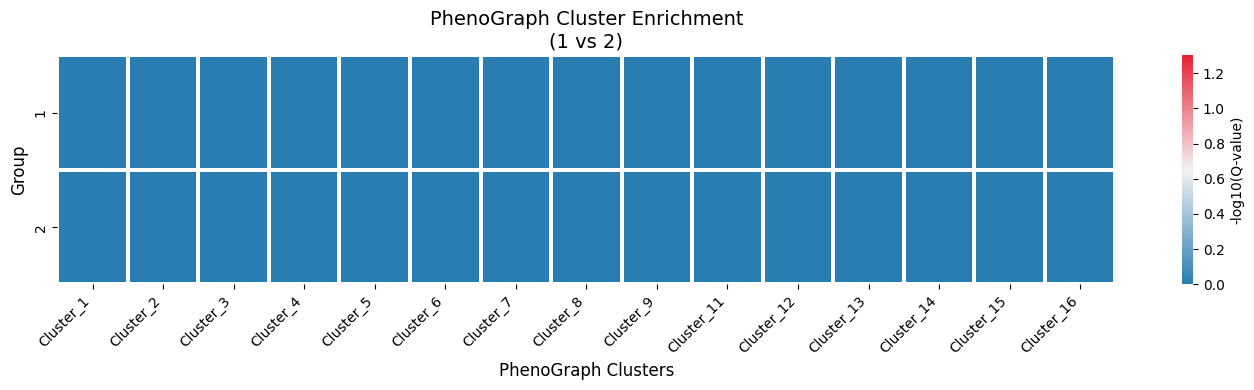

In [17]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置路径
# ==========================================
base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno_anno.csv")
output_prefix = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_CRPC_PhenoAnno_Matrix")

print("🚀 运行组合 2 (Matrix Mode): label.csv vs mydata_pheno_anno.csv")

# ==========================================
# 2. 辅助函数
# ==========================================
def extract_id(name):
    """从样本名提取数字 ID"""
    if not isinstance(name, str): return None
    name = str(name).strip().strip('"')
    match = re.search(r'(\d+)', name)
    return match.group(1) if match else name

# ==========================================
# 3. 读取并处理 Label 文件
# ==========================================
print("📥 读取 Label 文件...")
df_label = pd.read_csv(file_label)

# 强制重命名前两列
if df_label.shape[1] < 2:
    raise Exception("❌ Label 文件至少需要两列 (Sample, Group)。")

df_label.columns = [str(c).strip() for c in df_label.columns]
# 取前两列并重命名
df_label = df_label.iloc[:, :2]
df_label.columns = ['Sample_Name_Raw', 'Group_Name']

df_label['Sample_Name_Raw'] = df_label['Sample_Name_Raw'].astype(str).str.strip().str.replace('"', '')
df_label = df_label.dropna(subset=['Sample_Name_Raw', 'Group_Name'])
df_label['Match_ID'] = df_label['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Label 文件加载完成")
print(f"   分组分布:\n{df_label['Group_Name'].value_counts()}")

unique_groups = df_label['Group_Name'].unique()
if len(unique_groups) < 2:
    raise Exception(f"❌ 错误：Label 文件中只有 {len(unique_groups)} 组，无法进行对比分析。")
elif len(unique_groups) > 2:
    print(f"⚠️ 警告：发现 {len(unique_groups)} 个组别。将自动选取数量最多的两组进行对比。")
    top_2 = df_label['Group_Name'].value_counts().nlargest(2).index.tolist()
    df_label = df_label[df_label['Group_Name'].isin(top_2)]
    unique_groups = df_label['Group_Name'].unique()
    print(f"   已筛选为: {top_2}")

# ==========================================
# 4. 读取并处理 Cluster (PhenoGraph) 文件
# ==========================================
print("📥 读取 PhenoAnno 数据...")
df_c_raw = pd.read_csv(file_cluster)
df_c_raw.columns = [str(c).strip() for c in df_c_raw.columns]

col_name = df_c_raw.columns[0]

# 智能查找 PhenoGraph 列
col_pheno = None
if 'PhenoGraph' in df_c_raw.columns:
    col_pheno = 'PhenoGraph'
else:
    # 查找包含 'Pheno' 的列 (不区分大小写)
    pheno_cols = [c for c in df_c_raw.columns if 'pheno' in str(c).lower()]
    if pheno_cols:
        col_pheno = pheno_cols[0]
    else:
        # 如果没找到，尝试取第二列作为默认
        if len(df_c_raw.columns) > 1:
            col_pheno = df_c_raw.columns[1]
            print(f"⚠️ 未找到包含 'Pheno' 的列，默认使用第二列: '{col_pheno}'")
        else:
            raise Exception("❌ 未找到 Pheno 列，且文件只有一列。")

print(f"   使用列 '{col_pheno}' 作为 Cluster ID")

df_cluster = pd.DataFrame({
    'Sample_Name_Raw': df_c_raw[col_name].astype(str).str.strip().str.replace('"', ''),
    'Cluster_ID': df_c_raw[col_pheno].astype(str).str.strip()
})

# 去除空值
df_cluster = df_cluster.dropna(subset=['Sample_Name_Raw', 'Cluster_ID'])
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(extract_id)

print(f"✅ PhenoAnno 数据加载: {len(df_cluster)} 记录, {len(df_cluster['Cluster_ID'].unique())} 个唯一 Cluster")

# ==========================================
# 5. 合并数据
# ==========================================
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')

if len(df_merged) == 0:
    raise Exception("❌ 合并后无数据！请检查 Sample ID 提取逻辑是否一致。")

print(f"✅ 成功匹配样本数: {len(df_merged)}")

# 准备矩阵维度
groups = sorted(list(df_merged['Group_Name'].unique()))
group_to_idx = {g: i for i, g in enumerate(groups)}
df_merged['Group_Label'] = df_merged['Group_Name'].map(group_to_idx)

# 对 Cluster ID 进行排序 (尝试按数字排序，如果不行则按字符串)
def sort_key(x):
    try:
        return (0, float(x))
    except:
        return (1, str(x))

clusters = sorted(df_merged['Cluster_ID'].unique(), key=sort_key)

print(f"   对比组别: {groups[0]} vs {groups[1]}")
print(f"   Cluster 总数: {len(clusters)}")

# ==========================================
# 6. Fisher 精确检验 (构建矩阵)
# ==========================================
p_matrix = pd.DataFrame(1.0, index=groups, columns=[f"Cluster_{c}" for c in clusters])
or_matrix = pd.DataFrame(np.nan, index=groups, columns=[f"Cluster_{c}" for c in clusters])
count_matrix = pd.DataFrame(0, index=groups, columns=[f"Cluster_{c}" for c in clusters])

all_p_two_sided = []
cluster_order = []

print("\n🔍 正在执行 Fisher 精确检验...")

for cl in clusters:
    c_col = f"Cluster_{cl}"
    cluster_order.append(cl)
    
    # 构建列联表
    ct = pd.crosstab(df_merged['Group_Label'], df_merged['Cluster_ID'] == cl)
    ct = ct.reindex(index=[0, 1], columns=[False, True], fill_value=0)
    
    a = ct.loc[0, True]   # Group 0 has Cluster
    b = ct.loc[0, False]
    c = ct.loc[1, True]   # Group 1 has Cluster
    d = ct.loc[1, False]
    
    count_matrix.loc[groups[0], c_col] = a
    count_matrix.loc[groups[1], c_col] = c
    
    table = [[a, b], [c, d]]
    
    if a+b == 0 or c+d == 0 or a+c == 0 or b+d == 0:
        oddsratio = np.nan
        p_two = 1.0
        p_greater = 1.0
        p_less = 1.0
    else:
        oddsratio, p_two = fisher_exact(table, alternative='two-sided')
        _, p_greater = fisher_exact(table, alternative='greater') # Test if Group 0 is enriched
        _, p_less = fisher_exact(table, alternative='less')       # Test if Group 0 is depleted
        
    all_p_two_sided.append(p_two)
    
    # 分配单侧 P 值
    if pd.notna(oddsratio) and oddsratio > 1:
        # Group 0 富集
        p_matrix.loc[groups[0], c_col] = p_greater
        p_matrix.loc[groups[1], c_col] = 1.0
    elif pd.notna(oddsratio) and oddsratio < 1:
        # Group 1 富集
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = p_less
    else:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = 1.0
        
    or_matrix.loc[groups[0], c_col] = oddsratio
    or_matrix.loc[groups[1], c_col] = oddsratio

# ==========================================
# 7. FDR 校正
# ==========================================
print("⚖️ 进行 FDR (Benjamini-Hochberg) 校正...")
if len(all_p_two_sided) > 0:
    reject, q_vals, _, _ = multipletests(all_p_two_sided, method='fdr_bh')
    
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)
    
    for i, cl in enumerate(cluster_order):
        c_col = f"Cluster_{cl}"
        q = q_vals[i]
        or_val = or_matrix.loc[groups[0], c_col]
        
        if pd.notna(or_val) and or_val > 1:
            q_matrix.loc[groups[0], c_col] = q
            q_matrix.loc[groups[1], c_col] = 1.0
        elif pd.notna(or_val) and or_val < 1:
            q_matrix.loc[groups[0], c_col] = 1.0
            q_matrix.loc[groups[1], c_col] = q
else:
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)

# ==========================================
# 8. 输出结果摘要
# ==========================================
print("\n" + "="*70)
print("📊 显著性结果摘要 (FDR < 0.05)")
print("="*70)
sig_count = 0
for col in q_matrix.columns:
    q0 = q_matrix.loc[groups[0], col]
    q1 = q_matrix.loc[groups[1], col]
    if q0 < 0.05:
        print(f"   🔴 {col} 显著富集于 [{groups[0]}] (Q={q0:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1
    if q1 < 0.05:
        print(f"   🔵 {col} 显著富集于 [{groups[1]}] (Q={q1:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1

if sig_count == 0:
    print("   ⚪ 未发现显著富集的 Cluster。")

# 保存 CSV 矩阵
count_matrix.to_csv(f"{output_prefix}_Counts.csv")
or_matrix.to_csv(f"{output_prefix}_OR.csv")
p_matrix.to_csv(f"{output_prefix}_PValue.csv")
q_matrix.to_csv(f"{output_prefix}_QValue.csv")

print(f"\n💾 矩阵文件已保存:\n   - {output_prefix}_Counts.csv\n   - {output_prefix}_OR.csv\n   - {output_prefix}_PValue.csv\n   - {output_prefix}_QValue.csv")

# ==========================================
# 9. 绘制热图预览
# ==========================================
plt.figure(figsize=(14, max(4, len(groups)*0.8)))
# 转换 Q 值为 -log10
q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)
v_max = -np.log10(0.05)

sns.heatmap(q_plot, 
            cmap=sns.diverging_palette(240, 10, s=90, l=50, center="light", as_cmap=True),
            vmin=0, vmax=v_max,
            linewidths=1.5, linecolor='white',
            cbar_kws={'label': '-log10(Q-value)'})

plt.title(f"PhenoGraph Cluster Enrichment\n({groups[0]} vs {groups[1]})", fontsize=14)
plt.ylabel("Group", fontsize=12)
plt.xlabel("PhenoGraph Clusters", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plot_file = f"{output_prefix}_Heatmap.png"
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"🖼️ 热图已保存: {plot_file}")
plt.show()

🚀 运行组合 3 (Matrix Mode): label.csv vs mydata_pheno02.csv (Tumor Purity)
📥 读取 Label 文件...
✅ Label 文件加载完成
   分组分布:
Group_Name
2    28
1    13
Name: count, dtype: int64
📥 读取 Purity 数据...
   使用列 'TumorPurityLevel' 作为 Purity Level (Cluster ID)
✅ Purity 数据加载: 106 记录, 3 个唯一等级
✅ 成功匹配样本数: 80
   对比组别: 1 vs 2
   Purity 等级总数: 3 (['H', 'L', 'M'])

🔍 正在执行 Fisher 精确检验...
⚖️ 进行 FDR (Benjamini-Hochberg) 校正...

📊 显著性结果摘要 (FDR < 0.05)
   ⚪ 未发现显著富集的 Purity Level。

💾 矩阵文件已保存:
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_Purity_Matrix_Counts.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_Purity_Matrix_OR.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_Purity_Matrix_PValue.csv
   - /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_Pu

/tmp/ipykernel_254686/221468695.py:254: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)


🖼️ 热图已保存: /home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC/Part 3 discovery cohort TP SP TPL/Results_CRPC_Purity_Matrix_Heatmap.png


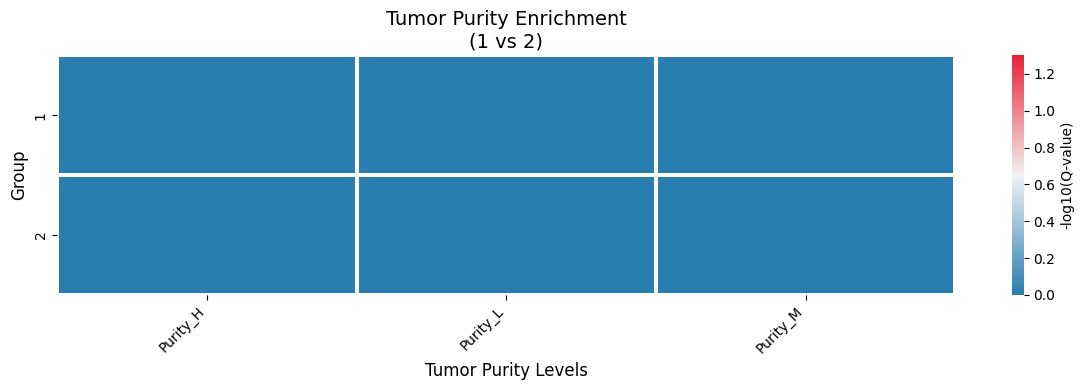

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置路径
# ==========================================
base_path = "/home/qyyuan/project/Lifei-Spatial/analysis/ChenleiLab_CODEX_HCC"
file_label = os.path.join(base_path, "Part 5 other figures in Fig1-4 Fig S1-6/CRPC.csv")
file_cluster = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/mydata_pheno02.csv")
output_prefix = os.path.join(base_path, "Part 3 discovery cohort TP SP TPL/Results_CRPC_Purity_Matrix")

print("🚀 运行组合 3 (Matrix Mode): label.csv vs mydata_pheno02.csv (Tumor Purity)")

# ==========================================
# 2. 辅助函数
# ==========================================
def extract_id(name):
    """从样本名提取数字 ID"""
    if not isinstance(name, str): return None
    name = str(name).strip().strip('"')
    match = re.search(r'(\d+)', name)
    return match.group(1) if match else name

# ==========================================
# 3. 读取并处理 Label 文件
# ==========================================
print("📥 读取 Label 文件...")
df_label = pd.read_csv(file_label)

# 强制重命名前两列
if df_label.shape[1] < 2:
    raise Exception("❌ Label 文件至少需要两列 (Sample, Group)。")

df_label.columns = [str(c).strip() for c in df_label.columns]
# 取前两列并重命名
df_label = df_label.iloc[:, :2]
df_label.columns = ['Sample_Name_Raw', 'Group_Name']

df_label['Sample_Name_Raw'] = df_label['Sample_Name_Raw'].astype(str).str.strip().str.replace('"', '')
df_label = df_label.dropna(subset=['Sample_Name_Raw', 'Group_Name'])
df_label['Match_ID'] = df_label['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Label 文件加载完成")
print(f"   分组分布:\n{df_label['Group_Name'].value_counts()}")

unique_groups = df_label['Group_Name'].unique()
if len(unique_groups) < 2:
    raise Exception(f"❌ 错误：Label 文件中只有 {len(unique_groups)} 组，无法进行对比分析。")
elif len(unique_groups) > 2:
    print(f"⚠️ 警告：发现 {len(unique_groups)} 个组别。将自动选取数量最多的两组进行对比。")
    top_2 = df_label['Group_Name'].value_counts().nlargest(2).index.tolist()
    df_label = df_label[df_label['Group_Name'].isin(top_2)]
    unique_groups = df_label['Group_Name'].unique()
    print(f"   已筛选为: {top_2}")

# ==========================================
# 4. 读取并处理 Cluster (Purity) 文件
# ==========================================
print("📥 读取 Purity 数据...")
df_c_raw = pd.read_csv(file_cluster)
df_c_raw.columns = [str(c).strip() for c in df_c_raw.columns]

col_name = df_c_raw.columns[0]

# 智能查找 Purity 列
col_purity = None
if 'TumorPurityLevel' in df_c_raw.columns:
    col_purity = 'TumorPurityLevel'
else:
    # 查找包含 'Purity' 的列 (不区分大小写)
    purity_cols = [c for c in df_c_raw.columns if 'purity' in str(c).lower()]
    if purity_cols:
        col_purity = purity_cols[0]
    else:
        # 如果没找到，尝试取第二列作为默认
        if len(df_c_raw.columns) > 1:
            col_purity = df_c_raw.columns[1]
            print(f"⚠️ 未找到包含 'Purity' 的列，默认使用第二列: '{col_purity}'")
        else:
            raise Exception("❌ 未找到 Purity 列，且文件只有一列。")

print(f"   使用列 '{col_purity}' 作为 Purity Level (Cluster ID)")

df_cluster = pd.DataFrame({
    'Sample_Name_Raw': df_c_raw[col_name].astype(str).str.strip().str.replace('"', ''),
    'Cluster_ID': df_c_raw[col_purity].astype(str).str.strip()
})

# 去除空值
df_cluster = df_cluster.dropna(subset=['Sample_Name_Raw', 'Cluster_ID'])
df_cluster['Match_ID'] = df_cluster['Sample_Name_Raw'].apply(extract_id)

print(f"✅ Purity 数据加载: {len(df_cluster)} 记录, {len(df_cluster['Cluster_ID'].unique())} 个唯一等级")

# ==========================================
# 5. 合并数据
# ==========================================
df_merged = pd.merge(df_cluster, df_label, on='Match_ID', how='inner')

if len(df_merged) == 0:
    raise Exception("❌ 合并后无数据！请检查 Sample ID 提取逻辑是否一致。")

print(f"✅ 成功匹配样本数: {len(df_merged)}")

# 准备矩阵维度
groups = sorted(list(df_merged['Group_Name'].unique()))
group_to_idx = {g: i for i, g in enumerate(groups)}
df_merged['Group_Label'] = df_merged['Group_Name'].map(group_to_idx)

# 对 Purity Level 进行排序 (尝试按数字/顺序排序)
def sort_key(x):
    try:
        # 尝试转为浮点数排序 (适用于 "0.5", "High" 可能失败，但通常 Purity 是分类字符串如 "Low", "Med", "High" 或数字)
        # 如果是 "Low", "Medium", "High" 这种，可能需要自定义映射，这里先尝试通用排序
        return (0, float(x))
    except:
        return (1, str(x))

# 特殊处理常见的有序分类
purity_order_map = {'Low': 0, 'Medium': 1, 'Med': 1, 'High': 2, 'Very High': 3}
def smart_sort_key(x):
    if x in purity_order_map:
        return (0, purity_order_map[x])
    try:
        return (1, float(x))
    except:
        return (2, str(x))

clusters = sorted(df_merged['Cluster_ID'].unique(), key=smart_sort_key)

print(f"   对比组别: {groups[0]} vs {groups[1]}")
print(f"   Purity 等级总数: {len(clusters)} ({clusters})")

# ==========================================
# 6. Fisher 精确检验 (构建矩阵)
# ==========================================
p_matrix = pd.DataFrame(1.0, index=groups, columns=[f"Purity_{c}" for c in clusters])
or_matrix = pd.DataFrame(np.nan, index=groups, columns=[f"Purity_{c}" for c in clusters])
count_matrix = pd.DataFrame(0, index=groups, columns=[f"Purity_{c}" for c in clusters])

all_p_two_sided = []
cluster_order = []

print("\n🔍 正在执行 Fisher 精确检验...")

for cl in clusters:
    c_col = f"Purity_{cl}"
    cluster_order.append(cl)
    
    # 构建列联表
    ct = pd.crosstab(df_merged['Group_Label'], df_merged['Cluster_ID'] == cl)
    ct = ct.reindex(index=[0, 1], columns=[False, True], fill_value=0)
    
    a = ct.loc[0, True]   # Group 0 has this Purity
    b = ct.loc[0, False]
    c = ct.loc[1, True]   # Group 1 has this Purity
    d = ct.loc[1, False]
    
    count_matrix.loc[groups[0], c_col] = a
    count_matrix.loc[groups[1], c_col] = c
    
    table = [[a, b], [c, d]]
    
    if a+b == 0 or c+d == 0 or a+c == 0 or b+d == 0:
        oddsratio = np.nan
        p_two = 1.0
        p_greater = 1.0
        p_less = 1.0
    else:
        oddsratio, p_two = fisher_exact(table, alternative='two-sided')
        _, p_greater = fisher_exact(table, alternative='greater') # Test if Group 0 is enriched
        _, p_less = fisher_exact(table, alternative='less')       # Test if Group 0 is depleted
        
    all_p_two_sided.append(p_two)
    
    # 分配单侧 P 值
    if pd.notna(oddsratio) and oddsratio > 1:
        # Group 0 富集
        p_matrix.loc[groups[0], c_col] = p_greater
        p_matrix.loc[groups[1], c_col] = 1.0
    elif pd.notna(oddsratio) and oddsratio < 1:
        # Group 1 富集
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = p_less
    else:
        p_matrix.loc[groups[0], c_col] = 1.0
        p_matrix.loc[groups[1], c_col] = 1.0
        
    or_matrix.loc[groups[0], c_col] = oddsratio
    or_matrix.loc[groups[1], c_col] = oddsratio

# ==========================================
# 7. FDR 校正
# ==========================================
print("⚖️ 进行 FDR (Benjamini-Hochberg) 校正...")
if len(all_p_two_sided) > 0:
    reject, q_vals, _, _ = multipletests(all_p_two_sided, method='fdr_bh')
    
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)
    
    for i, cl in enumerate(cluster_order):
        c_col = f"Purity_{cl}"
        q = q_vals[i]
        or_val = or_matrix.loc[groups[0], c_col]
        
        if pd.notna(or_val) and or_val > 1:
            q_matrix.loc[groups[0], c_col] = q
            q_matrix.loc[groups[1], c_col] = 1.0
        elif pd.notna(or_val) and or_val < 1:
            q_matrix.loc[groups[0], c_col] = 1.0
            q_matrix.loc[groups[1], c_col] = q
else:
    q_matrix = pd.DataFrame(1.0, index=groups, columns=p_matrix.columns)

# ==========================================
# 8. 输出结果摘要
# ==========================================
print("\n" + "="*70)
print("📊 显著性结果摘要 (FDR < 0.05)")
print("="*70)
sig_count = 0
for col in q_matrix.columns:
    q0 = q_matrix.loc[groups[0], col]
    q1 = q_matrix.loc[groups[1], col]
    if q0 < 0.05:
        print(f"   🔴 {col} 显著富集于 [{groups[0]}] (Q={q0:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1
    if q1 < 0.05:
        print(f"   🔵 {col} 显著富集于 [{groups[1]}] (Q={q1:.4e}, OR={or_matrix.loc[groups[0], col]:.2f})")
        sig_count += 1

if sig_count == 0:
    print("   ⚪ 未发现显著富集的 Purity Level。")

# 保存 CSV 矩阵
count_matrix.to_csv(f"{output_prefix}_Counts.csv")
or_matrix.to_csv(f"{output_prefix}_OR.csv")
p_matrix.to_csv(f"{output_prefix}_PValue.csv")
q_matrix.to_csv(f"{output_prefix}_QValue.csv")

print(f"\n💾 矩阵文件已保存:\n   - {output_prefix}_Counts.csv\n   - {output_prefix}_OR.csv\n   - {output_prefix}_PValue.csv\n   - {output_prefix}_QValue.csv")

# ==========================================
# 9. 绘制热图预览
# ==========================================
plt.figure(figsize=(12, max(4, len(groups)*0.8)))
# 转换 Q 值为 -log10
q_plot = q_matrix.applymap(lambda x: -np.log10(x) if x > 0 else 0)
v_max = -np.log10(0.05)

sns.heatmap(q_plot, 
            cmap=sns.diverging_palette(240, 10, s=90, l=50, center="light", as_cmap=True),
            vmin=0, vmax=v_max,
            linewidths=1.5, linecolor='white',
            cbar_kws={'label': '-log10(Q-value)'})

plt.title(f"Tumor Purity Enrichment\n({groups[0]} vs {groups[1]})", fontsize=14)
plt.ylabel("Group", fontsize=12)
plt.xlabel("Tumor Purity Levels", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plot_file = f"{output_prefix}_Heatmap.png"
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"🖼️ 热图已保存: {plot_file}")
plt.show()